# Texas Rangers 2025 시즌 재구성
## Markov Chain 기반 Monte Carlo 시뮬레이션 + ML 잔차 보정

마르코프 체인 기반 공격 시뮬레이션과 이닝별 투구 모델을 결합해  
2025 실제 일정을 재현하며 시즌 총 승수를 재구성한다.

**전체 흐름**

```
데이터 로드
  → 타자 확률 추출 (PA 기반 이벤트 확률)
  → 동적 라인업 풀 구성 (포지션 · 출전 비율 반영)
  → 공격 시뮬레이션 (Markov chain, 이닝 단위)
  → 수비 시뮬레이션 (선발 · 셋업 · 마무리 이닝별 ERA)
  → ML 잔차 보정 (Ridge/Lasso/RF/XGBoost 앙상블, 클러치 · 불펜 효율 반영)
  → 시나리오 선택 → 실제 일정 162경기 시뮬레이션
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import platform
from collections import Counter

warnings.filterwarnings('ignore')

if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)
print('환경 설정 완료')

환경 설정 완료


## 1. 데이터 로드

시뮬레이션에 필요한 모든 데이터를 불러온다.

| 데이터 | 용도 |
|---|---|
| `batting_stats_2025_all.csv` | 타자별 이벤트 확률 계산 |
| `rangers_roster_2025.csv` | 포지션 매핑 |
| `rangers_hitting_batted.csv` | 타구 방향 (GB%/FB%) |
| `rangers_running.csv` | 주자 스프린트 스피드 |
| `rangers_pitcher_gamelogs.csv` | 선발/불펜 ERA 분리 계산 |
| `texas_2025_game_log.csv` | 실제 162경기 일정 · 결과 |
| `tex_2025_save_situation_splits.csv` | 투수별 세이브 상황 실적 (마무리 풀 구성 · ERA 산출용) |
| `tex_2025_pitching_inning_splits.csv` | 이닝별 실측 ERA (선발·셋업·마무리 분리) |
| `mlb_teams_2025_pitching.csv` | 상대팀 투구 지표 (ERA·K/9·BB/9·HR/9) |
| `statcast_tex_singles_2025.csv` | 단타 시 주자 진루 확률 계산용 Statcast |
| `statcast_tex_doubles_2025.csv` | 2루타 시 주자 진루 확률 계산용 Statcast |
| `statcast_tex_all_events_2025.csv` | TEX 전체 타격 이벤트 (이벤트 확률 추출) |
| `sprint_speed_2025.csv` | 선수별 스프린트 스피드 (주루 속도 티어 분류) |
| `mlb_team_seasons.csv` | ML 잔차 모델 학습 데이터 |
| `fangraphs-guts-data.csv` | 구장별 파크팩터 |

In [2]:
# ── 타격 (GDP, SF, HBP 포함) ─────────────────────────────────
bat_all = pd.read_csv('../Data/batting_stats_2025_all.csv')
bat_tex = bat_all[bat_all['Tm'] == 'Texas'].copy()

# roster pos merge
import unicodedata
def _strip_acc(s):
    return ''.join(c for c in unicodedata.normalize('NFD', str(s))
                   if unicodedata.category(c) != 'Mn')

_roster = (pd.read_csv('../Data/rangers_roster_2025.csv')
             .query("type == 'batter'")[['name', 'pos']]
             .rename(columns={'name': 'Name', 'pos': 'Pos'}))
_roster['_key'] = _roster['Name'].apply(_strip_acc)
bat_tex['_key']  = bat_tex['Name'].apply(_strip_acc)
bat_tex = bat_tex.merge(_roster[['_key', 'Pos']], on='_key', how='left').drop(columns=['_key'])
bat_tex['Pos'] = bat_tex['Pos'].fillna('UT')

# ── 타구 방향 데이터 (GB%/FB% 분류용) ───────────────────────────────────────
_batted = pd.read_csv('../Data/rangers_hitting_batted.csv')
_batted['_key'] = _batted['Player'].apply(_strip_acc)
bat_tex['_key']  = bat_tex['Name'].apply(_strip_acc)
bat_tex = bat_tex.merge(
    _batted[['_key', 'GB %']], on='_key', how='left'
).drop(columns=['_key'])
bat_tex['GB %'] = bat_tex['GB %'].fillna(44.0)

# ── 주루 스피드 ──────────────────────────────────────────
running = pd.read_csv('../Data/rangers_running.csv')

# ── 투수 게임로그 (ERA, HR9 산출) ──────────────────────────────
pit_logs = pd.read_csv('../Data/rangers_pitcher_gamelogs.csv')

# ── 팀 게임로그 (W/L, RS, RA, 홈/원정, 1점차) ─────────────────────────
game_log = pd.read_csv('../Data/texas_2025_game_log.csv')
game_log['win']     = game_log['W/L'].str.startswith('W')
game_log['is_home'] = game_log['Home_Away'] == 'Home'
game_log['run_diff']= game_log['R'] - game_log['RA']
game_log['onerun']  = game_log['run_diff'].abs() == 1
game_log['extra']   = game_log['Inn'].fillna(9).astype(float) > 9

# ── 세이브 상황 ────────────────────────────────────────────
sv_df   = pd.read_csv('../Data/tex_2025_save_situation_splits.csv')
team_sv = sv_df[sv_df['Name'] == 'Team Total'].iloc[0]

# ── 역대 MLB 팀 스탯 (ML 잔차 모델용) ───────────────────────────────
mlb_hist = pd.read_csv('../Data/mlb_team_seasons.csv')

# ── 투수 누적 스탯 계산 ──────────────────────────────────────────
def _ip_float(v):
    s = str(v); p = s.split('.')
    return int(p[0]) + int(p[1])/3 if len(p) == 2 else int(s)

ip_total   = pit_logs['IP'].apply(_ip_float).sum()
# ip_total = 1443
era_actual = (pit_logs['ER'].sum()+3) * 9 / ip_total
hr9_actual = pit_logs['HR'].sum() * 9 / ip_total
k9_actual  = pit_logs['SO'].sum() * 9 / ip_total
bb9_actual = pit_logs['BB'].sum() * 9 / ip_total
whip_actual= (pit_logs['H'].sum() + pit_logs['BB'].sum()) / ip_total

# 선발/불펜 ERA 분리
_sp = pit_logs[pit_logs['GS'] == 1]
_rp = pit_logs[pit_logs['GS'] == 0]
def _calc_era(sub):
    ip = sub['IP'].apply(_ip_float).sum()
    return sub['ER'].sum() * 9 / ip if ip > 0 else 4.50
starter_era_actual = _calc_era(_sp)
bullpen_era_actual  = _calc_era(_rp)
starter_ip_avg     = _sp['IP'].apply(_ip_float).mean()  # 경기당 선발 평균 IP (실제 이닝)
_sp_ip_dist        = _sp['IP'].apply(_ip_float).values  # 경기당 선발 이닝 실제 분포

# 이닝별 ERA (셋업/마무리)
_closer_names = set(
    sv_df[(sv_df['Name'] != 'Team Total') &
          ((sv_df['GF'] >= 5) | (sv_df['SV'].fillna(0).astype(int) >= 3))]['Name']
)
_rp_all = pit_logs[pit_logs['GS'] == 0].copy()
_rp_all['_ip'] = _rp_all['IP'].apply(_ip_float)
setup_era_actual  = (_rp_all[~_rp_all['name'].isin(_closer_names)]['ER'].sum() * 9
                     / _rp_all[~_rp_all['name'].isin(_closer_names)]['_ip'].sum())
# 9회 마무리 ERA: 세이브 상황 실적 (블론세이브 포함)
_sv_cl = sv_df[(sv_df['Name'] != 'Team Total') &
               ((sv_df['GF'] >= 5) | (sv_df['SV'].fillna(0).astype(int) >= 3))].copy()
_sv_cl['_ip'] = _sv_cl['IP'].apply(_ip_float)
closer_era_actual = _sv_cl['ER'].sum() * 9 / _sv_cl['_ip'].sum()
# ── 불펜 풀 사전 계산 (역할별 가중 샘플링) ──────────────────────────────────
_rp_stats_pool = (
    _rp_all.groupby('name')
    .apply(lambda g: pd.Series({
        'G':  len(g),
        'IP': g['_ip'].sum(),
        'ER': g['ER'].sum(),
        'H':  g['H'].sum(),
        'BB': g['BB'].sum(),
        'K':  g['SO'].sum(),
    }), include_groups=False)
)
_rp_stats_pool['role'] = ['closer' if n in _closer_names else 'setup'
                          for n in _rp_stats_pool.index]
_rp_stats_pool['ERA']  = _rp_stats_pool['ER'] * 9  / _rp_stats_pool['IP'].clip(lower=0.1)
_rp_stats_pool['WHIP'] = (_rp_stats_pool['H'] + _rp_stats_pool['BB']) / _rp_stats_pool['IP'].clip(lower=0.1)
_rp_stats_pool['K9']   = _rp_stats_pool['K']  * 9  / _rp_stats_pool['IP'].clip(lower=0.1)
_rp_stats_pool['BB9']  = _rp_stats_pool['BB'] * 9  / _rp_stats_pool['IP'].clip(lower=0.1)

# 9회 마무리: SV 비례 가중치 (세이브 없으면 GF 보조 사용)
_sv_weight_map = {
    row['Name']: max(1, int(row['SV'] or 0) + int(row['GF'] or 0) // 2)
    for _, row in sv_df[sv_df['Name'] != 'Team Total'].iterrows()
}

def _make_bp_pool(role, use_sv=False):
    sub = _rp_stats_pool[_rp_stats_pool['role'] == role]
    if sub.empty: sub = _rp_stats_pool
    ns = list(sub.index)
    if use_sv:
        w = np.array([float(_sv_weight_map.get(n, 1)) for n in ns], dtype=float)
    else:
        w = np.array(sub['G'].values, dtype=float)
    w /= w.sum()
    return ns, w

# 시즌 중 방출된 투수: game_idx > 기준 경기 이후 셋업/미들 풀에서 제외
RELEASED_MIDSEASON = {'Luke Jackson': 103}

_SETUP_POOL  = _make_bp_pool('setup',  use_sv=False) # 7-8회: G 비례
_MIDDLE_POOL = _make_bp_pool('setup',  use_sv=False) # 중간 계투

# 기간별 마무리 풀 (SV 비례 가중)
def _make_period_closer(names):
    ns = [n for n in names if n in _rp_stats_pool.index]
    w  = np.array([float(_sv_weight_map.get(n, 1)) for n in ns], dtype=float)
    w /= w.sum()
    return ns, w

# P1(1~35): Jackson 전담  /  P2(36~162): 집단 마무리 위원회 (SV 가중치)
_CLOSER_POOL_P1 = _make_period_closer(['Luke Jackson'])                             # 1~35경기
_CLOSER_POOL_P2 = _make_period_closer(['Shawn Armstrong', 'Robert Garcia',
                                        'Phil Maton', 'Chris Martin'])              # 36~162경기
# ※ Luke Jackson은 36~103경기엔 RELEASED_MIDSEASON 로직으로 자동 제외

# 기간별 전체 불펜 풀: 셋업 + 해당 기간 비마무리 클로저 (비SV 상황 및 7~8회용)
def _make_full_bp_pool(active_closer_names, include_active_closers=False):
    if include_active_closers:
        eligible = _rp_stats_pool  # 집단 마무리: 위원회 4인도 불펜 겸임
    else:
        eligible = _rp_stats_pool[
            (_rp_stats_pool['role'] == 'setup') |
            (~_rp_stats_pool.index.isin(active_closer_names))
        ]
    if eligible.empty:
        eligible = _rp_stats_pool
    ns = list(eligible.index)
    w  = np.array(eligible['G'].values, dtype=float)
    w /= w.sum()
    return ns, w

_FULL_BP_POOL_P1 = _make_full_bp_pool(set(_CLOSER_POOL_P1[0]))                              # P1: Jackson 전담 보호
_FULL_BP_POOL_P2 = _make_full_bp_pool(set(_CLOSER_POOL_P2[0]), include_active_closers=True) # P2: 위원회 불펜 겸임

# 파크팩터 로드 (FanGraphs 컴포넌트 PF)
_FG_TEAM_MAP = {
    'Angels':'LAA','Orioles':'BAL','Red Sox':'BOS','White Sox':'CHW',
    'Guardians':'CLE','Tigers':'DET','Royals':'KCR','Twins':'MIN',
    'Yankees':'NYY','Athletics':'ATH','Mariners':'SEA','Rays':'TBR',
    'Rangers':'TEX','Blue Jays':'TOR','Diamondbacks':'ARI','Braves':'ATL',
    'Cubs':'CHC','Reds':'CIN','Rockies':'COL','Marlins':'MIA',
    'Astros':'HOU','Dodgers':'LAD','Brewers':'MIL','Nationals':'WSN',
    'Mets':'NYM','Phillies':'PHI','Pirates':'PIT','Cardinals':'STL',
    'Padres':'SDP','Giants':'SFG',
}
_pf_df = pd.read_csv('../Data/fangraphs-guts-data.csv')
_pf_df = _pf_df[_pf_df['Season'] == 2025].copy()
_pf_df['abbr'] = _pf_df['Team'].map(_FG_TEAM_MAP)
park_factor_map = {
    row['abbr']: {
        'single': row['1B']  / 100.0,
        'double': row['2B']  / 100.0,
        'triple': row['3B']  / 100.0,
        'hr':     row['HR']  / 100.0,
        'bb':     row['BB']  / 100.0,
        'overall': row['Basic (5yr)'] / 100.0,
    }
    for _, row in _pf_df.iterrows() if pd.notna(row['abbr'])
}
# 경기별 홈/원정 정보
schedule_home = game_log['Home_Away'].eq('Home').tolist()

print('데이터 로드 완료')
print(f'  Rangers 타자: {len(bat_tex)}명  (포지션 매핑: {bat_tex["Pos"].ne("UT").sum()}명)')
print(f'  주루 스피드 보유: {len(running)}명')
print(f'  투수 게임로그: {len(pit_logs)}행')
print(f'  팀 게임로그: {len(game_log)}경기')
print(f'  MLB 역대 팀 시즌: {len(mlb_hist)}행')
print(f'\nTEX 2025 투수 실적')
print(f'  ERA={era_actual:.2f}  HR9={hr9_actual:.2f}  K9={k9_actual:.2f}  BB9={bb9_actual:.2f}  WHIP={whip_actual:.3f}')
print(f'  선발 ERA={starter_era_actual:.2f}  셋업 ERA={setup_era_actual:.2f}  마무리 ERA(세이브)={closer_era_actual:.2f}')
print(f'  선발 평균 IP={starter_ip_avg:.2f}  불펜 ERA={bullpen_era_actual:.2f}')


데이터 로드 완료
  Rangers 타자: 23명  (포지션 매핑: 22명)
  주루 스피드 보유: 21명
  투수 게임로그: 679행
  팀 게임로그: 162경기
  MLB 역대 팀 시즌: 330행

TEX 2025 투수 실적
  ERA=3.49  HR9=1.07  K9=8.43  BB9=2.90  WHIP=1.175
  선발 ERA=3.41  셋업 ERA=3.89  마무리 ERA(세이브)=4.16
  선발 평균 IP=5.32  불펜 ERA=3.57


In [3]:
# ── 투수 개선 데이터 로드 ────────────────────────────────────────────────────
# [개선 A] 이닝별 실측 ERA (tex_2025_pitching_inning_splits.csv)
_inn_splits = pd.read_csv('../Data/tex_2025_pitching_inning_splits.csv')
inning_era_map = {
    i + 1: float(row['ERA'])
    for i, (_, row) in enumerate(_inn_splits.iterrows())
    if i < 9 and pd.notna(row['ERA'])
}

# [개선 B] 선발 로테이션 개별 ERA (rangers_pitcher_gamelogs.csv)
_starter_stats = (
    _sp.groupby('name')
    .apply(lambda g: pd.Series({
        'ERA':    g['ER'].sum() * 9 / g['IP'].apply(_ip_float).sum(),
        'avg_ip': g['IP'].apply(_ip_float).mean(),
        'GS':     len(g),
        'K9':     g['SO'].sum() * 9 / g['IP'].apply(_ip_float).sum(),
        'BB9':    g['BB'].sum() * 9 / g['IP'].apply(_ip_float).sum(),
        'WHIP':   (g['H'].sum() + g['BB'].sum()) / g['IP'].apply(_ip_float).sum(),
    }), include_groups=False)
    .query('GS >= 5')
    .sort_values('GS', ascending=False)
)
rotation_era_list = _starter_stats['ERA'].tolist()
rotation_ip_list  = _starter_stats['avg_ip'].tolist()  # 선발별 평균 소화 이닝
if not rotation_era_list:
    rotation_era_list = [starter_era_actual]
    rotation_ip_list  = [starter_ip_avg]

print('투수 개선 데이터 로드 완료')
print(f'  이닝별 ERA: { {k: round(v, 2) for k, v in inning_era_map.items()} }')
print(f'  선발 로테이션 ({len(rotation_era_list)}인):')
for name, row in _starter_stats.iterrows():
    print(f'    {name:22s}  ERA={row["ERA"]:.2f}  avg_IP={row["avg_ip"]:.2f}  GS={int(row["GS"])}')

# [개선 C] 상대팀 투구 특성: K/9, BB/9, HR/9 이벤트별 보정
_pit_df  = pd.read_csv('../Data/mlb_teams_2025_pitching.csv')
_LG_K9   = float(_pit_df['K/9'].mean())
_LG_BB9  = float(_pit_df['BB/9'].mean())
_LG_HR9  = float(_pit_df['HR/9'].mean())
_FG_TO_BR = {'KCR':'KC','CHW':'CWS','TBR':'TB','SFG':'SF','SDP':'SD','ATH':'OAK'}
opp_pit_factors_map = {
    _FG_TO_BR.get(r['Team'], r['Team']): {
        'k_factor':  float(r['K/9'])  / _LG_K9,
        'bb_factor': float(r['BB/9']) / _LG_BB9,
        'hr_factor': float(r['HR/9']) / _LG_HR9,
    }
    for _, r in _pit_df.iterrows()
}
print(f'  상대팀 투구 특성: {len(opp_pit_factors_map)}팀 | K9 avg={_LG_K9:.2f}  BB9 avg={_LG_BB9:.2f}  HR9 avg={_LG_HR9:.2f}')


투수 개선 데이터 로드 완료
  이닝별 ERA: {1: 3.33, 2: 2.67, 3: 3.67, 4: 3.5, 5: 3.22, 6: 3.89, 7: 3.44, 8: 3.06, 9: 4.24}
  선발 로테이션 (8인):
    Jacob deGrom            ERA=2.97  avg_IP=5.76  GS=30
    Patrick Corbin          ERA=4.32  avg_IP=5.14  GS=30
    Jack Leiter             ERA=3.86  avg_IP=5.23  GS=29
    Nathan Eovaldi          ERA=1.73  avg_IP=5.91  GS=22
    Tyler Mahle             ERA=2.18  avg_IP=5.42  GS=16
    Kumar Rocker            ERA=5.74  avg_IP=4.60  GS=14
    Merrill Kelly           ERA=4.23  avg_IP=5.53  GS=10
    Jacob Latz              ERA=2.72  avg_IP=4.96  GS=8
  상대팀 투구 특성: 30팀 | K9 avg=8.49  BB9 avg=3.21  HR9 avg=1.18


In [4]:
# (제거: 디버깅 잔재 ip_total)

In [5]:
# (제거: 디버깅 잔재 pit_logs value_counts)

## 1-2. 단타 진루 확률 계산

단타 시 1루 주자가 2루 또는 3루까지 진루하는 확률을 Statcast 데이터에서 추출한다.  
데이터 가용성에 따라 3단계 fallback으로 처리한다.

| 단계 | 방법 |
|---|---|
| 1 | pybaseball `post_on_*` 컬럼으로 직접 계산 |
| 2 | 다음 타석 루상 상태로 역추론 |
| 3 | Retrosheet 리그 평균 하드코딩 |

In [6]:
import pybaseball as pb
from pathlib import Path
import os

pb.cache.enable()

CACHE_PATH        = Path('../Data/statcast_tex_singles_2025.csv')
DOUBLE_CACHE_PATH = Path('../Data/statcast_tex_doubles_2025.csv')
FULL_CACHE_PATH   = Path('../Data/statcast_tex_all_events_2025.csv')

# 캐시가 있으면 바로 로드, 없을 때만 pybaseball 다운로드
if CACHE_PATH.exists() and DOUBLE_CACHE_PATH.exists():
    tex_singles = pd.read_csv(CACHE_PATH)
    tex_doubles = pd.read_csv(DOUBLE_CACHE_PATH)
    HAS_POST_COLS = True
    print(f'캐시 로드 완료 — 단타: {len(tex_singles):,}행 | 2루타: {len(tex_doubles):,}행')

else:
    # 소량 샘플로 post_on_* 컬럼 존재 여부 확인
    print('[다운로드] 소량 샘플 (2025-04-01 ~ 04-03) — 컬럼 확인...')
    sample = pb.statcast('2025-04-01', '2025-04-03')

    HAS_POST_NATIVE = 'post_on_1b' in sample.columns
    print(f'-> post_on_* 컬럼: {"존재" if HAS_POST_NATIVE else "없음"}')

    if HAS_POST_NATIVE:
        COLS_FULL = ['game_date', 'game_type', 'batter', 'home_team', 'away_team', 'inning_topbot',
                     'on_1b', 'on_2b', 'on_3b',
                     'post_on_1b', 'post_on_2b', 'post_on_3b', 'events']

        print('전체 기간 다운로드 중 (정규시즌 단타·2루타, post_on_* 포함)...')
        dfs = []
        for start, end in [('2025-03-20', '2025-05-31'),
                           ('2025-06-01', '2025-08-31'),
                           ('2025-09-01', '2025-10-05')]:
            chunk = pb.statcast(start, end)
            is_tex = (
                ((chunk['home_team'] == 'TEX') & (chunk['inning_topbot'] == 'Bot')) |
                ((chunk['away_team'] == 'TEX') & (chunk['inning_topbot'] == 'Top'))
            )
            avail = [c for c in COLS_FULL if c in chunk.columns]
            chunk = chunk[
                chunk['events'].isin(['single', 'double']) &
                is_tex &
                (chunk['game_type'] == 'R')
            ][avail].copy()
            dfs.append(chunk)
            print(f'  {start[:7]}: {len(chunk):,}행')

        all_hits    = pd.concat(dfs, ignore_index=True)
        tex_singles = all_hits[all_hits['events'] == 'single'].copy()
        tex_doubles = all_hits[all_hits['events'] == 'double'].copy()
        tex_singles.to_csv(CACHE_PATH,        index=False)
        tex_doubles.to_csv(DOUBLE_CACHE_PATH, index=False)
        print(f'저장 완료 — 단타: {len(tex_singles):,}행 | 2루타: {len(tex_doubles):,}행')
        HAS_POST_COLS = True

    else:
        tex_singles   = pd.DataFrame()
        tex_doubles   = pd.DataFrame()
        HAS_POST_COLS = False


캐시 로드 완료 — 단타: 840행 | 2루타: 245행


In [7]:
# # ======================================================================
# # 해결방안 2 — 다음 타석 on_* 로 post_state 추론 (단타 + 2루타)
# # ======================================================================
# if not HAS_POST_COLS:

#     ALL_COLS = ['game_pk', 'game_date', 'game_type', 'batter', 'inning', 'inning_topbot',
#                 'at_bat_number', 'events', 'home_team', 'away_team',
#                 'on_1b', 'on_2b', 'on_3b']

#     if FULL_CACHE_PATH.exists():
#         tex_all = pd.read_csv(FULL_CACHE_PATH)
#         print(f'[해결방안 2] 전체 이벤트 캐시 로드: {len(tex_all):,}타석')
#     else:
#         print('[해결방안 2] TEX 정규시즌 전체 타격 이벤트 다운로드 중...')
#         dfs = []
#         for start, end in [('2025-03-20', '2025-05-31'),
#                            ('2025-06-01', '2025-08-31'),
#                            ('2025-09-01', '2025-10-05')]:
#             chunk = pb.statcast(start, end)
#             is_tex = (
#                 ((chunk['home_team'] == 'TEX') & (chunk['inning_topbot'] == 'Bot')) |
#                 ((chunk['away_team'] == 'TEX') & (chunk['inning_topbot'] == 'Top'))
#             )
#             avail = [c for c in ALL_COLS if c in chunk.columns]
#             chunk = chunk[
#                 is_tex &
#                 chunk['events'].notna() &
#                 (chunk['game_type'] == 'R')
#             ][avail].copy()
#             dfs.append(chunk)
#             print(f'  {start[:7]}: {len(chunk):,}타석')
#         tex_all = pd.concat(dfs, ignore_index=True)
#         tex_all.to_csv(FULL_CACHE_PATH, index=False)
#         print(f'저장: {FULL_CACHE_PATH}  ({len(tex_all):,}타석)')

#     # 이벤트 분포 확인 (공식 팀 스탯과 비교용)
#     ev_counts = tex_all['events'].value_counts()
#     for ev in ['single', 'double', 'triple', 'home_run']:
#         print(f'  {ev:<12}: {ev_counts.get(ev, 0):,}')

#     def derive_post_state(df):
#         sort_cols = (['game_pk', 'at_bat_number'] if 'at_bat_number' in df.columns
#                      else ['game_pk', 'inning', 'inning_topbot'])
#         df = df.sort_values(sort_cols).reset_index(drop=True)
#         for base in ['1b', '2b', '3b']:
#             df[f'post_on_{base}'] = df[f'on_{base}'].shift(-1)
#         df['_ng'] = df['game_pk'].shift(-1)
#         df['_ni'] = df['inning'].shift(-1)
#         df['_nt'] = df['inning_topbot'].shift(-1)
#         invalid = (
#             (df['game_pk'] != df['_ng']) |
#             (df['inning'] != df['_ni']) |
#             (df['inning_topbot'] != df['_nt'])
#         )
#         df.loc[invalid, ['post_on_1b', 'post_on_2b', 'post_on_3b']] = np.nan
#         return df.drop(columns=['_ng', '_ni', '_nt'])

#     tex_all_post = derive_post_state(tex_all)
#     tex_singles  = tex_all_post[tex_all_post['events'] == 'single'].copy()
#     tex_doubles  = tex_all_post[tex_all_post['events'] == 'double'].copy()
#     tex_singles.to_csv(CACHE_PATH,        index=False)
#     tex_doubles.to_csv(DOUBLE_CACHE_PATH, index=False)

#     for label, df in [('단타', tex_singles), ('2루타', tex_doubles)]:
#         total = len(df)
#         valid = (~df[['post_on_1b','post_on_2b','post_on_3b']].isnull().all(axis=1)).sum()
#         print(f'{label}: {total:,}개  |  이닝 내 유효: {valid:,}개  |  경계 제외: {total-valid:,}개')
#     print('-> post_on_* 추론 완료')
#     HAS_POST_COLS = True

In [8]:
# (제거: Cell 9와 동일한 중복 블록)

In [9]:
# ══════════════════════════════════════════════════════════════════════
# player_id → 스프린트 스피드 매핑 구축
#
#   우선순위:
#     1) pybaseball.statcast_sprint_speed(2025) — MLB 전체 선수 커버
#     2) rangers_running.csv + player_id 컬럼   — TEX 선수만 (fallback)
#     3) 리그 평균 27.0 ft/s                     — 최종 fallback
#
#   결과: SPEED_MAP = {player_id(float): sprint_speed(float)}
# ══════════════════════════════════════════════════════════════════════
SPD_CACHE        = Path('../Data/sprint_speed_2025.csv')
LEAGUE_AVG_SPEED = 27.0

if SPD_CACHE.exists():
    spd_df = pd.read_csv(SPD_CACHE)
    print(f'스프린트 스피드 캐시 로드: {len(spd_df):,}명')
else:
    try:
        print('pybaseball statcast_sprint_speed(2025) 다운로드...')
        spd_df = pb.statcast_sprint_speed(2025)
        spd_df.to_csv(SPD_CACHE, index=False)
        print(f'저장: {SPD_CACHE}  ({len(spd_df):,}명)')
    except Exception as e:
        print(f'⚠  다운로드 실패: {e}')
        spd_df = pd.DataFrame()

# ── pybaseball 결과에서 player_id / speed 컬럼 탐색 ──────────────────
SPEED_MAP = {}

if not spd_df.empty:
    print(f'\nstatcast_sprint_speed 컬럼: {spd_df.columns.tolist()}')
    id_col  = next((c for c in spd_df.columns
                    if c.lower() in ('player_id', 'mlbamid', 'id', 'mlbid')), None)
    spd_col = next((c for c in spd_df.columns
                    if 'speed' in c.lower()), None)

    if id_col and spd_col:
        SPEED_MAP = {float(pid): float(spd)
                     for pid, spd in zip(spd_df[id_col], spd_df[spd_col])
                     if pd.notna(pid) and pd.notna(spd)}
        print(f'→ pybaseball 매핑 완료: {len(SPEED_MAP):,}명  (컬럼: {id_col!r}, {spd_col!r})')
    else:
        print(f'⚠  player_id / speed 컬럼을 찾지 못함 → fallback으로 진행')

# ── Fallback 1: rangers_running.csv + player_id ───────────────────────
if not SPEED_MAP:
    if 'player_id' in running.columns:
        SPEED_MAP = {float(pid): float(spd)
                     for pid, spd in zip(running['player_id'], running['Sprint Speed (ft/s)'])
                     if pd.notna(pid) and pd.notna(spd)}
        print(f'→ running.csv fallback: {len(SPEED_MAP):,}명 (TEX 선수만)')
    else:
        print('⚠  running.csv에도 player_id 없음 → 리그 평균 사용')

# ── 최종 요약 ─────────────────────────────────────────────────────────
if SPEED_MAP:
    speeds = list(SPEED_MAP.values())
    print(f'\nSPEED_MAP: {len(SPEED_MAP):,}명')
    print(f'  범위: {min(speeds):.1f} ~ {max(speeds):.1f} ft/s')
    print(f'  평균: {sum(speeds)/len(speeds):.2f} ft/s  (리그 기준치: {LEAGUE_AVG_SPEED})')
else:
    print(f'\n⚠  SPEED_MAP 비어있음 → 모든 주자 {LEAGUE_AVG_SPEED} ft/s 적용')

스프린트 스피드 캐시 로드: 579명

statcast_sprint_speed 컬럼: ['last_name, first_name', 'player_id', 'team_id', 'team', 'position', 'age', 'competitive_runs', 'bolts', 'hp_to_1b', 'sprint_speed']
→ pybaseball 매핑 완료: 579명  (컬럼: 'player_id', 'sprint_speed')

SPEED_MAP: 579명
  범위: 23.1 ~ 30.3 ft/s
  평균: 27.34 ft/s  (리그 기준치: 27.0)


In [10]:
# ======================================================================
# 최종 진루 확률 계산 — 단타 + 2루타
# 해결방안 3: 1·2 모두 실패 시 Retrosheet / The Book 리그 평균 사용
# ======================================================================
label_map = {'slow': '느림 (<26.5)', 'mid': '보통 (26.5~27.5)',
             'fast': '빠름 (27.5~28.5)', 'very_fast': '매우빠름 (28.5+)'}
old_vals  = {'slow': 0.10, 'mid': 0.20, 'fast': 0.30, 'very_fast': 0.40}

RETRO = {
    'r2':     0.635,
    'r1':     {'slow': 0.09, 'mid': 0.18, 'fast': 0.29, 'very_fast': 0.42},
    'r2_dbl': 0.870,
    'r1_dbl': {'slow': 0.15, 'mid': 0.25, 'fast': 0.38, 'very_fast': 0.52},
}

# 단타 r3: 항상 홈인 (결정론적)
#   비홈인 케이스는 잔루/홈 아웃 두 가지인데 서로 모델이 달라 확률화 불가
#   실제 홈인율도 ~92% 이상으로 매우 높아 결정론적 처리가 적합
R3_SCORE_RATE = 1.0

if HAS_POST_COLS and len(tex_singles) > 0:
    def _scored(row, key):
        post = {row['post_on_1b'], row['post_on_2b'], row['post_on_3b']}
        return pd.notna(row[key]) and row[key] not in post

    # ── 단타 진루 확률 (r2, r1만 확률화) ─────────────────────────────
    r2_df = tex_singles[tex_singles['on_2b'].notna()].copy()
    r2_df['scored'] = r2_df.apply(lambda r: _scored(r, 'on_2b'), axis=1)
    R2_SCORE_RATE = float(r2_df['scored'].mean()) if len(r2_df) >= 10 else RETRO['r2']

    r1_df = tex_singles[tex_singles['on_1b'].notna()].copy()
    r1_df['to_3rd'] = r1_df.apply(
        lambda r: pd.notna(r['post_on_3b']) and r['post_on_3b'] == r['on_1b'], axis=1)
    r1_df['speed'] = r1_df['on_1b'].astype(float).map(SPEED_MAP).fillna(LEAGUE_AVG_SPEED)
    r1_df['tier']  = pd.cut(r1_df['speed'], bins=[0, 26.5, 27.5, 28.5, 99],
                            labels=['slow', 'mid', 'fast', 'very_fast'])
    tier_stats = r1_df.groupby('tier', observed=True)['to_3rd'].agg(['mean', 'count'])
    R1_SPEED_PROBS = {
        k: (float(tier_stats.loc[k, 'mean'])
            if k in tier_stats.index and tier_stats.loc[k, 'count'] >= 10
            else RETRO['r1'][k])
        for k in ['slow', 'mid', 'fast', 'very_fast']
    }

    # ── 2루타 진루 확률 ────────────────────────────────────────────────
    r2_dbl = tex_doubles[tex_doubles['on_2b'].notna()].copy()
    r2_dbl['scored'] = r2_dbl.apply(lambda r: _scored(r, 'on_2b'), axis=1)
    R2_SCORE_RATE_DBL = float(r2_dbl['scored'].mean()) if len(r2_dbl) >= 10 else RETRO['r2_dbl']

    r1_dbl = tex_doubles[tex_doubles['on_1b'].notna()].copy()
    r1_dbl['scored'] = r1_dbl.apply(lambda r: _scored(r, 'on_1b'), axis=1)
    r1_dbl['speed']  = r1_dbl['on_1b'].astype(float).map(SPEED_MAP).fillna(LEAGUE_AVG_SPEED)
    r1_dbl['tier']   = pd.cut(r1_dbl['speed'], bins=[0, 26.5, 27.5, 28.5, 99],
                               labels=['slow', 'mid', 'fast', 'very_fast'])
    tier_dbl = r1_dbl.groupby('tier', observed=True)['scored'].agg(['mean', 'count'])
    R1_SCORE_PROBS_DBL = {
        k: (float(tier_dbl.loc[k, 'mean'])
            if k in tier_dbl.index and tier_dbl.loc[k, 'count'] >= 10
            else RETRO['r1_dbl'][k])
        for k in ['slow', 'mid', 'fast', 'very_fast']
    }
    src = '2025 TEX 실측'

else:
    R2_SCORE_RATE      = RETRO['r2']
    R1_SPEED_PROBS     = RETRO['r1'].copy()
    R2_SCORE_RATE_DBL  = RETRO['r2_dbl']
    R1_SCORE_PROBS_DBL = RETRO['r1_dbl'].copy()
    r2_df = r1_df = r2_dbl = r1_dbl = pd.DataFrame()
    tier_stats = tier_dbl = None
    src = 'Retrosheet / The Book 리그 평균 (최종 fallback)'
    print('-> 해결방안 1·2 모두 실패, Retrosheet 리그 평균 사용')

# ── 결과 출력 ─────────────────────────────────────────────────────────
print(f'=== 단타 진루 확률 ({src}) ===')
print(f'  r3 홈인율: 1.000  (결정론적)')
print(f'  r2 홈인율: {R2_SCORE_RATE:.3f}  (n={len(r2_df):,})')
print('  r1->3루 (속도별):')
for k in ['slow', 'mid', 'fast', 'very_fast']:
    cnt  = int(tier_stats.loc[k, 'count']) if (tier_stats is not None and k in tier_stats.index) else 0
    flag = '실측' if cnt >= 10 else ('n부족->기본값' if 0 < cnt < 10 else 'Retro기본값')
    print(f'    {label_map[k]:<18}: {R1_SPEED_PROBS[k]:.3f}  (기존: {old_vals[k]:.3f}, {flag}, n={cnt:,})')

print(f'\n=== 2루타 진루 확률 ({src}) ===')
print(f'  r3 홈인율: 1.000  (결정론적)')
print(f'  r2 홈인율: {R2_SCORE_RATE_DBL:.3f}  (n={len(r2_dbl):,})')
print('  r1->홈 (속도별):')
for k in ['slow', 'mid', 'fast', 'very_fast']:
    cnt  = int(tier_dbl.loc[k, 'count']) if (tier_dbl is not None and k in tier_dbl.index) else 0
    flag = '실측' if cnt >= 10 else ('n부족->기본값' if 0 < cnt < 10 else 'Retro기본값')
    print(f'    {label_map[k]:<18}: {R1_SCORE_PROBS_DBL[k]:.3f}  ({flag}, n={cnt:,})')


# ── 아웃 시 주자 진루 확률 (Retrosheet / The Book 기반) ─────────────────────
ADV_R3_GROUNDOUT = 0.16   # r3 -> 홈 (땅볼: 우측 방향 / 스퀴즈)
ADV_R2_GROUNDOUT = 0.37   # r2 -> 3루 (땅볼: 우측 / 유격수 정면)
ADV_R3_FLYOUT    = 0.44   # r3 -> 홈 (태그업: 외야 뜬공)
ADV_R2_FLYOUT    = 0.17   # r2 -> 3루 (태그업: 깊은 외야 뜬공)
ADV_R1_GROUNDOUT = 0.80   # r1 -> 2루 (비GIDP 땅볼, 1루 아웃 시 자동 진루)


=== 단타 진루 확률 (2025 TEX 실측) ===
  r3 홈인율: 1.000  (결정론적)
  r2 홈인율: 0.716  (n=169)
  r1->3루 (속도별):
    느림 (<26.5)        : 0.213  (기존: 0.100, 실측, n=75)
    보통 (26.5~27.5)    : 0.269  (기존: 0.200, 실측, n=78)
    빠름 (27.5~28.5)    : 0.456  (기존: 0.300, 실측, n=57)
    매우빠름 (28.5+)      : 0.338  (기존: 0.400, 실측, n=65)

=== 2루타 진루 확률 (2025 TEX 실측) ===
  r3 홈인율: 1.000  (결정론적)
  r2 홈인율: 0.981  (n=53)
  r1->홈 (속도별):
    느림 (<26.5)        : 0.409  (실측, n=22)
    보통 (26.5~27.5)    : 0.385  (실측, n=26)
    빠름 (27.5~28.5)    : 0.636  (실측, n=11)
    매우빠름 (28.5+)      : 0.579  (실측, n=19)


## 2. 베이스 상태 엔진

루상 상태를 비트마스크(`1루=1, 2루=2, 3루=4`)로 표현하고  
타격 이벤트 발생 시 주자 위치와 득점을 갱신한다.

| 이벤트 | 처리 |
|---|---|
| 안타 | 주자 스프린트 스피드 기반 확률적 진루 |
| 땅볼 | GB%로 확률 분리, GIDP / 일반 진루 분기 |
| 뜬공 | FB%로 확률 분리, 태그업 확률 적용 |
| 희생플라이 | 3루 주자 + 아웃 < 2 조건에서 득점 |
| HBP / 볼넷 | 강제 진루 |

In [11]:
def _spd_prob(speed, probs):
    """속도 → 해당 진루 확률 (4단계 티어)"""
    if speed >= 28.5: return probs['very_fast']
    if speed >= 27.5: return probs['fast']
    if speed >= 26.5: return probs['mid']
    return probs['slow']


def advance_runners(runners, outs, event, profile=None, runner_speeds=None):
    """
    베이스 상태 전이 함수 (v2 보완판)

    runners      : 비트마스크 (1루=1, 2루=2, 3루=4)
    runner_speeds: {base_bit: sprint_speed}  ← 각 루상 주자의 실제 속도
    profile      : {'gdp_rate', 'sf_rate', 'speed'}  ← 현재 타자 프로파일
    returns      : (new_runners, new_outs, runs_scored, new_runner_speeds)
    """
    r1 = bool(runners & 1)
    r2 = bool(runners & 2)
    r3 = bool(runners & 4)
    p  = profile or {}
    bat_spd = p.get('speed', LEAGUE_AVG_SPEED)   # 타자(새 주자)의 속도
    rs = runner_speeds or {}                       # 기존 루상 주자 속도
    r1_spd = rs.get(1, LEAGUE_AVG_SPEED)          # 1루 주자 속도
    r2_spd = rs.get(2, LEAGUE_AVG_SPEED)
    r3_spd = rs.get(4, LEAGUE_AVG_SPEED)

    # ── 홈런 ──────────────────────────────────────────────────────────
    if event == 'hr':
        return 0, outs, 1 + r1 + r2 + r3, {}

    # ── 3루타 ─────────────────────────────────────────────────────────
    elif event == 'triple':
        return 4, outs, r1 + r2 + r3, {4: bat_spd}

    # ── 2루타 ─────────────────────────────────────────────────────────
    elif event == 'double':
        r3_scores = r3
        r2_scores = r2 and (np.random.random() < R2_SCORE_RATE_DBL)
        r1_scores = r1 and (np.random.random() < _spd_prob(r1_spd, R1_SCORE_PROBS_DBL))

        runs = int(r3_scores) + int(r2_scores) + int(r1_scores)
        new_runners = 2
        new_rs = {2: bat_spd}

        if r2 and not r2_scores:
            new_runners |= 4
            new_rs[4] = r2_spd
        if r1 and not r1_scores:
            if new_runners & 4:
                runs += 1          # 3루 막힘 → 강제 홈인
            else:
                new_runners |= 4
                new_rs[4] = r1_spd

        return new_runners, outs, runs, new_rs

    # ── 단타 ─────────────────────────────────────────────────────────
    elif event == 'single':
        r3_scores = r3
        r2_scores = r2 and (np.random.random() < R2_SCORE_RATE)
        r1_to_3rd = r1 and (np.random.random() < _spd_prob(r1_spd, R1_SPEED_PROBS))

        runs = int(r3_scores) + int(r2_scores)
        new_runners = 1
        new_rs = {1: bat_spd}

        if r2 and not r2_scores:
            new_runners |= 4
            new_rs[4] = r2_spd
        if r1:
            if r1_to_3rd:
                if new_runners & 4:    # 3루 막힘 → 2루 잔류
                    new_runners |= 2
                    new_rs[2] = r1_spd
                else:
                    new_runners |= 4
                    new_rs[4] = r1_spd
            else:
                new_runners |= 2
                new_rs[2] = r1_spd

        return new_runners, outs, runs, new_rs

    # ── 볼넷 / 사구 (강제 진루) ───────────────────────────────────────
    elif event in ('bb', 'hbp'):
        if r1 and r2 and r3:
            return 7, outs, 1, {1: bat_spd, 2: r1_spd, 4: r2_spd}
        elif r1 and r2:
            return 7, outs, 0, {1: bat_spd, 2: r1_spd, 4: r2_spd}
        elif r1:
            return 3, outs, 0, {1: bat_spd, 2: r1_spd}
        else:
            return runners | 1, outs, 0, {**rs, 1: bat_spd}

    # ── 삼진 ─────────────────────────────────────────────────────────
    elif event == 'k':
        return runners, outs + 1, 0, rs.copy()

    # ── 땅볼 아웃 (GIDP + 주자 진루) ───────────────────────────────────
    elif event == 'groundout':
        if r1 and outs < 2 and (np.random.random() < p.get('gdp_rate', 0.025)):
            return runners & ~1, min(outs + 2, 3), 0, {k: v for k, v in rs.items() if k != 1}
        new_runners = runners; new_rs = rs.copy(); runs = 0
        if outs < 2:
            if r3 and np.random.random() < ADV_R3_GROUNDOUT:
                new_runners &= ~4; new_rs.pop(4, None); runs += 1
            if r2 and not (new_runners & 4) and np.random.random() < ADV_R2_GROUNDOUT:
                new_runners = (new_runners & ~2) | 4
                new_rs[4] = new_rs.pop(2, LEAGUE_AVG_SPEED)
            if r1 and not (new_runners & 2) and np.random.random() < ADV_R1_GROUNDOUT:
                new_runners = (new_runners & ~1) | 2
                new_rs[2] = new_rs.pop(1, LEAGUE_AVG_SPEED)
        return new_runners, outs + 1, runs, new_rs

    # ── 뜬공 아웃 (태그업 진루) ─────────────────────────────────────────
    elif event == 'flyout':
        new_runners = runners; new_rs = rs.copy(); runs = 0
        if outs < 2:
            if r3 and np.random.random() < ADV_R3_FLYOUT:
                new_runners &= ~4; new_rs.pop(4, None); runs += 1
            if r2 and not (new_runners & 4) and np.random.random() < ADV_R2_FLYOUT:
                new_runners = (new_runners & ~2) | 4
                new_rs[4] = new_rs.pop(2, LEAGUE_AVG_SPEED)
        return new_runners, outs + 1, runs, new_rs

    return runners, outs, 0, rs.copy()

print('advance_runners() 정의 완료 — 주자 속도 개별 추적 적용')


advance_runners() 정의 완료 — 주자 속도 개별 추적 적용


## 3. 타자 확률 추출

`batting_stats_2025_all.csv`의 PA·H·2B·3B·HR·BB·HBP·SO·GDP·SF를 이용해  
타석당 이벤트 확률 딕셔너리를 생성한다.

```
{single, double, triple, hr, bb, hbp, k, groundout, flyout}
합계 = 1.0
```

GB%는 `rangers_hitting_batted.csv`에서 병합하며, 없으면 리그 평균 44%를 사용한다.

In [12]:

def extract_probs(row):
    """
    타자 데이터 1행 -> 이벤트 확률 딕셔너리
    v3: GB%/FB% 기반으로 out -> groundout + flyout 분리
    """
    pa  = row['PA']
    h   = row['H']
    d   = row['2B']
    t   = row['3B']
    hr  = row['HR']
    bb  = row['BB']
    so  = row['SO']
    hbp = row.get('HBP', 0) or 0

    single    = max(0, h - d - t - hr)
    out_total = max(0, pa - h - bb - hbp - so)

    gb_frac = float(row.get('GB %', 44.0) or 44.0) / 100.0
    fb_frac = 1.0 - gb_frac

    probs = {
        'single':    single              / pa,
        'double':    d                   / pa,
        'triple':    t                   / pa,
        'hr':        hr                  / pa,
        'bb':        bb                  / pa,
        'hbp':       hbp                 / pa,
        'k':         so                  / pa,
        'groundout': out_total * gb_frac / pa,
        'flyout':    out_total * fb_frac / pa,
    }
    probs = {k: max(0, v) for k, v in probs.items()}
    total = sum(probs.values())
    return {k: v / total for k, v in probs.items()} if total > 0 else {'groundout': 0.5, 'flyout': 0.5}


def extract_profile(row, running_df=None):
    """
    타자 데이터 1행 → 베이스 상황 조건부 확률 프로파일
    v2: GDP, SF, 스프린트 스피드 포함
    """
    pa   = row['PA']
    gdp  = row.get('GDP', 0) or 0
    sf   = row.get('SF',  0) or 0
    name = row.get('Name', '')

    speed = 27.0  # 리그 평균
    if running_df is not None:
        match = running_df[running_df['Player'] == name]
        if not match.empty:
            speed = float(match.iloc[0]['Sprint Speed (ft/s)'])

    return {
        'gdp_rate': gdp / pa,
        'sf_rate':  sf  / pa,
        'speed':    speed,
        'name':     name,
    }

print('extract_probs() / extract_profile() 정의 완료')

extract_probs() / extract_profile() 정의 완료


## 4. 타순 구성

9개 AL 포지션 슬롯(C · 1B · 2B · 3B · SS · LF · CF · RF · DH)에 대해  
2-stage Bernoulli 샘플링으로 라인업을 구성하고 OBP 내림차순으로 타순을 배열한다.

**`SLOT_STARTERS`**  
포지션별 주전 선수를 명시적으로 지정한다.  
각 경기마다 `Bernoulli(start_w)`로 주전 선발 여부를 독립적으로 결정해  
출전 경기수가 풀 가중치 희석 없이 `start_w × 162`에 정확히 근사한다.

**`LineupPool`**  
- `__init__`: pandas 연산을 한 번만 수행, 선수별 이벤트 누적합 배열 저장  
- `sample()`: 2단계 샘플링  
  1. 주전 슬롯 → `Bernoulli(start_w)` 통과 시 해당 선수 고정  
  2. 미통과 시 → 백업 풀에서 가중 샘플링  
- 시나리오 boosts가 있으면 초기화 시점에 확률에 반영


In [13]:
# ── 멀티포지션 eligibility (로스터 CSV는 주 포지션만 기재) ──────────────────
MULTI_POS = {
    # 내야
    'Marcus Semien':   ['2B', 'SS', '3B'],
    'Josh Smith':      ['SS', '2B', '3B', 'LF', 'RF'],
    'Ezequiel Duran':  ['SS', '2B', '3B', 'LF', 'RF'],
    'Dylan Moore':     ['2B', 'SS', 'LF', 'CF', 'RF'],
    'Sam Haggerty':    ['2B', 'SS', 'LF', 'CF', 'RF'],
    'Nick Ahmed':      ['SS', '2B', '3B'],
    'Jake Burger':     ['1B', '3B'],
    'Josh Jung':       ['3B', '1B'],
    'Donovan Solano':  ['1B', '2B', '3B'],
    # 외야
    'Adolis García':   ['RF', 'CF'],
    'Leody Taveras':   ['CF', 'LF'],
    'Evan Carter':     ['CF', 'LF'],
    'Dustin Harris':   ['LF', 'CF'],
    'Billy McKinney':  ['LF', 'CF', 'RF'],
    'Kevin Pillar':    ['CF', 'LF', 'RF'],
    'Sam Haggerty':    ['CF', 'LF', 'RF', '2B', 'SS'],
    'Joc Pederson':    ['1B', 'LF'],
    'Rowdy Tellez':    ['1B', 'LF'],
}

# ── AL 9인 포지션 슬롯 (C/1B/2B/3B/SS/LF/CF/RF/DH) ─────────────────────────
# DH 슬롯(None)은 앞 8 슬롯에서 뒤 선수 전체 풀에서 G 가중 샘플링
SLOT_DEFS = [
    ('C',  ['C']),
    ('1B', ['1B']),
    ('2B', ['2B']),
    ('3B', ['3B']),
    ('SS', ['SS']),
    ('LF', ['LF']),
    ('CF', ['CF']),
    ('RF', ['RF']),
    ('DH', None),
]

# ── 고정 라인업 (calibration 기준점 + 시나리오 인덱스 참고용) ──────────────
LINEUP = [
    'Marcus Semien',
    'Corey Seager',
    'Wyatt Langford',
    'Adolis García',
    'Jake Burger',
    'Josh Jung',
    'Jonah Heim',
    'Josh Smith',
    'Kyle Higashioka',
]

lineup_probs    = []
lineup_profiles = []

for name in LINEUP:
    row = bat_tex[bat_tex['Name'] == name]
    if row.empty:
        print(f'⚠  {name} 데이터 없음 — 타자 건너뜀')
        continue
    row = row.iloc[0]
    lineup_probs.append(extract_probs(row))
    lineup_profiles.append(extract_profile(row, running))

# ── 출력 ────────────────────────────────────────────────────
print(f'타순 구성: {len(lineup_probs)}명\n')
header = f'{"선수":<22} {"단타":>6} {"2루":>6} {"3루":>6} {"HR":>6} {"BB":>6} {"HBP":>5} {"K":>6} {"땅볼":>6} {"뜬공":>6} {"GDP%":>7} {"SF%":>6} {"속도":>6}'
print(header)
print('-' * len(header))
for name, prob, prof in zip(LINEUP, lineup_probs, lineup_profiles):
    print(f'{name:<22} '
          f'{prob["single"]:>6.3f} {prob["double"]:>6.3f} {prob["triple"]:>6.3f} '
          f'{prob["hr"]:>6.3f} {prob["bb"]:>6.3f} {prob.get("hbp", 0):>5.3f} '
          f'{prob["k"]:>6.3f} {prob["groundout"]:>6.3f} {prob["flyout"]:>6.3f} '
          f'{prof["gdp_rate"]:>7.3f} {prof["sf_rate"]:>6.3f} {prof["speed"]:>6.1f}')

print()

# ── 동적 라인업 풀 ───────────────────────────────────────────
MIN_PA   = 20
bat_pool = bat_tex[bat_tex['PA'] >= MIN_PA].copy()
bat_pool['start_w'] = (bat_pool['G'] / 162.0).clip(0.01, 1.0)
bat_pool['elig_pos'] = bat_pool.apply(
    lambda r: MULTI_POS.get(r['Name'], [r['Pos']]), axis=1)

# 2025 출전 비중 보정: Smith 2025 SS 경기는 Seager 부재 때문 → 유틸리티 수준으로 조정
# Seager: 2025 실제 출전 102G에 가까운 출전 비중 적용 (start_w=0.65, 약 105G)
# ─────────────────── 보정치 적용 부분은 추가 확인 필요 ───────────────────

bat_pool.loc[bat_pool['Name'] == 'Corey Seager', 'start_w'] = 0.65
bat_pool.loc[bat_pool['Name'] == 'Josh Smith',      'start_w'] = 0.50
bat_pool.loc[bat_pool['Name'] == 'Jonah Heim',      'start_w'] = round(4/7, 4)  # 4:3 체력 관리 로테이션 (~93경기)
bat_pool.loc[bat_pool['Name'] == 'Kyle Higashioka', 'start_w'] = round(3/7, 4)  # 백업 포수 (~69경기)

print(f'\n동적 라인업 풀: {len(bat_pool)}명  (PA >= {MIN_PA})')
_pool_disp = bat_pool[['Name','Pos','G','PA','OBP']].sort_values('G', ascending=False)
print(_pool_disp.to_string(index=False))



# 슬롯별 주전 매핑 (Bernoulli 우선 결정)
SLOT_STARTERS = {
    'C':  'Jonah Heim',
    '1B': 'Jake Burger',
    '2B': 'Marcus Semien',
    '3B': 'Josh Jung',
    'SS': 'Corey Seager',
    'LF': 'Wyatt Langford',
    'RF': 'Adolis García',
}

class LineupPool:
    """
    포지션 슬롯별 2단계 샘플링:
      1단계) 주전(SLOT_STARTERS)을 start_w 확률로 독립 Bernoulli 시행
      2단계) 주전 결장 시 백업 pool에서 가중 샘플링
    """
    def __init__(self, pool_df=None, run_df=None, name_boosts=None):
        if pool_df is None: pool_df = bat_pool
        if run_df  is None: run_df  = running

        probs_d = {}; prof_d = {}; obp_d = {}; elig_d = {}; w_d = {}
        for _, row in pool_df.iterrows():
            n = row['Name']
            p = extract_probs(row)
            if name_boosts and n in name_boosts:
                p = apply_batter_boost(p, **name_boosts[n])
            probs_d[n] = p
            prof_d[n]  = extract_profile(row, run_df)
            obp_d[n]   = float(row.get('OBP', 0.320) or 0.320)
            elig_d[n]  = list(row.get('elig_pos', [row.get('Pos', 'UT')]))
            w_d[n]     = float(row['start_w'])

        self._probs = probs_d
        self._prof  = prof_d
        self._obp   = obp_d
        self._w     = w_d
        self._all   = list(probs_d.keys())
        self._probs_tup = {
            n: (tuple(p.keys()),
                np.cumsum(np.array(list(p.values()), dtype=np.float64)))
            for n, p in probs_d.items()
        }

        # 슬롯별 백업 후보 목록 사전 계산
        self._slots = []
        for _, pos_list in SLOT_DEFS:
            if pos_list is not None:
                ns = [n for n in self._all if any(p in pos_list for p in elig_d[n])]
            else:
                ns = None  # DH: 잔여 선수 전체
            self._slots.append(ns)

    def sample(self):
        """2단계 샘플링 → OBP 내림차순 타순 반환"""
        used = set()
        selected = []

        for i, (slot_name, pos_list) in enumerate(SLOT_DEFS):
            # ── 1단계: 주전 Bernoulli ───────────────────────────────────────
            starter = SLOT_STARTERS.get(slot_name)
            if starter and starter in self._w and starter not in used:
                if np.random.random() < self._w[starter]:
                    used.add(starter)
                    selected.append(starter)
                    continue

            # ── 2단계: 백업 pool 가중 샘플링 ──────────────────────────────
            pool = self._slots[i] if self._slots[i] is not None else self._all
            avail = [n for n in pool if n not in used]
            if starter:
                avail = [n for n in avail if n != starter]  # 주전은 이미 결장 처리
            if not avail:
                avail = [n for n in self._all if n not in used]
            if not avail:
                continue
            w = np.array([self._w[n] for n in avail], dtype=float)
            w /= w.sum()
            chosen = avail[int(np.random.choice(len(avail), p=w))]
            used.add(chosen)
            selected.append(chosen)

        selected.sort(key=lambda n: self._obp[n], reverse=True)
        return ([self._probs_tup[n] for n in selected],
                [self._prof[n]      for n in selected],
                selected)


타순 구성: 9명

선수                         단타     2루     3루     HR     BB   HBP      K     땅볼     뜬공    GDP%    SF%     속도
----------------------------------------------------------------------------------------------------------
Marcus Semien           0.142  0.030  0.002  0.028  0.094 0.009  0.174  0.180  0.341   0.015  0.017   28.5
Corey Seager            0.142  0.043  0.000  0.047  0.130 0.011  0.196  0.193  0.239   0.029  0.004   25.3
Wyatt Langford          0.122  0.044  0.002  0.038  0.129 0.009  0.264  0.137  0.255   0.016  0.009   28.9
Adolis García           0.124  0.051  0.000  0.035  0.051 0.009  0.247  0.178  0.305   0.016  0.013   27.0
Jake Burger             0.138  0.040  0.003  0.043  0.032 0.013  0.247  0.191  0.293   0.008  0.008   27.9
Josh Jung               0.162  0.045  0.002  0.027  0.053 0.004  0.252  0.189  0.265   0.020  0.000   26.6
Jonah Heim              0.136  0.032  0.000  0.025  0.074 0.002  0.203  0.217  0.309   0.023  0.009   25.2
Josh Smith              0.

In [14]:
# ── 2025 출전 비중: 2025 실측 기반 이항분포(Binomial) CI ────────────────────
# p = G_2025 / 162 로 출전 비율을 추정하고,
# σ = sqrt(162·p·(1-p)) 로 시뮬 당 자연 변동 폭을 계산한다.
# 시뮬레이션 매 시행마다 Binomial(162, p)에서 출전 경기를 재샘플링하므로
# 하드코딩 없이 데이터 기반 불확실성을 반영한다.

import random as _rand

# ── 타자 참여율 ───────────────────────────────────────────────────────────────
print('[ 타자 출전 경기 예측 범위 (80% CI) ]')
print(f"{'선수':<22} {'2025G':>6} {'p':>6} {'sigma':>6} {'80% CI':>12}")
print('-' * 60)
_batter_binom_p = {}
for name in LINEUP:
    row = bat_tex[bat_tex['Name'] == name]
    if row.empty:
        continue
    g25 = float(row.iloc[0]['G'])
    p   = min(g25 / 162.0, 1.0)
    sg  = np.sqrt(162 * p * (1 - p))
    lo  = max(0,   round(162 * p - 1.28 * sg))
    hi  = min(162, round(162 * p + 1.28 * sg))
    _batter_binom_p[name] = p
    bat_pool.loc[bat_pool['Name'] == name, 'start_w'] = p
    print(f'{name:<22} {int(g25):>6} {p:>6.3f} {sg:>6.1f} {lo:>4}~{hi:>3}경기')

# 포수 4:3 체력 관리 로테이션 오버라이드 (루프 이후 덮어쓰기)
_catcher_override = {'Jonah Heim': round(4/7, 4), 'Kyle Higashioka': round(3/7, 4)}
for _name, _p in _catcher_override.items():
    _batter_binom_p[_name] = _p
    bat_pool.loc[bat_pool['Name'] == _name, 'start_w'] = _p

# ── 선발 투수 등판 예측 범위 ────────────────────────────────────────────────────
print()
print('[ 선발 투수 등판 예측 범위 (80% CI) ]')
print(f"{'선수':<22} {'2025GS':>7} {'p':>6} {'sigma':>6} {'80% CI':>12}")
print('-' * 60)
_starter_binom_p = {}
for name, row in _starter_stats.iterrows():
    gs25 = int(row['GS'])
    p    = min(gs25 / 162.0, 1.0)
    sg   = np.sqrt(162 * p * (1 - p))
    lo   = max(0,   round(162 * p - 1.28 * sg))
    hi   = min(162, round(162 * p + 1.28 * sg))
    _starter_binom_p[name] = p
    print(f'{name:<22} {gs25:>7} {p:>6.3f} {sg:>6.1f} {lo:>4}~{hi:>3}GS')

# ── 초기 rotation 구성 (기댓값 기반 — 매 시뮬 시행 안에서 재샘플링됨) ─────────
_rand.seed(42)
_rot_entries = []
for name, row in _starter_stats.iterrows():
    proj_gs = max(1, int(round(162 * _starter_binom_p[name])))
    _rot_entries.extend([(name, float(row['ERA']), float(row['avg_ip']))] * proj_gs)
_rand.shuffle(_rot_entries)
rotation_name_list = [e[0] for e in _rot_entries]
rotation_era_list  = [e[1] for e in _rot_entries]
rotation_ip_list   = [e[2] for e in _rot_entries]
print(f'\n  초기 rotation list 길이: {len(rotation_era_list)}')


[ 타자 출전 경기 예측 범위 (80% CI) ]
선수                      2025G      p  sigma       80% CI
------------------------------------------------------------
Marcus Semien             127  0.784    5.2  120~134경기
Corey Seager              102  0.630    6.1   94~110경기
Wyatt Langford            134  0.827    4.8  128~140경기
Adolis García             135  0.833    4.7  129~141경기
Jake Burger               103  0.636    6.1   95~111경기
Josh Jung                 131  0.809    5.0  125~137경기
Jonah Heim                124  0.765    5.4  117~131경기
Josh Smith                144  0.889    4.0  139~149경기
Kyle Higashioka            94  0.580    6.3   86~102경기

[ 선발 투수 등판 예측 범위 (80% CI) ]
선수                      2025GS      p  sigma       80% CI
------------------------------------------------------------
Jacob deGrom                30  0.185    4.9   24~ 36GS
Patrick Corbin              30  0.185    4.9   24~ 36GS
Jack Leiter                 29  0.179    4.9   23~ 35GS
Nathan Eovaldi              22  0.136    4.

## 5. 시뮬레이션 함수

**공격 (TEX)**
- `simulate_inning`: 3아웃까지 타순 순환, 이닝 득점 반환
- `simulate_game`: 9이닝 합산, 타순 이닝 간 연속 유지

**수비 (상대)**
- `simulate_opponent_runs_by_inning`: 선발 이닝 수를 실제 분포에서 샘플링  
  이닝별로 투수를 배정하고 해당 투수의 **실제 ERA**로 실점을 계산한다

  | 이닝 | 투수 풀 |
  |------|--------|
  | 선발 소화 이닝 | 해당 경기 선발 ERA |
  | 전이 이닝 | 선발·불펜 ERA 가중 혼합 |
  | 9회+ | `_CLOSER_POOL` (SV 비례 가중) |
  | ~8회 | `_SETUP_POOL` (G 비례 가중) |

**불펜 (`_pick_and_track_bp`)**  
- 선택된 투수의 ERA를 반환해 실점 계산에 직접 반영  
- 3연투 방지: `recent_apps`로 직전 2경기 연속 등판 투수 제외  
- 시즌 중 방출 처리: `RELEASED_MIDSEASON`에 등록된 투수는 기준 경기 이후 자동 제외  
- 누적 IP 감쇠: 각 투수의 실제 2025 IP를 목표치로 이차 감쇠 적용  
  `decay = max(0.1, 1 - (누적IP / 실제IP)²)` → 자연스러운 시즌 후반 부하 분산

**시즌**
- `simulate_season`: n경기 × n_sims, 기본 단일 ERA 버전
- `simulate_season_schedule`: 실제 162경기 일정 + 홈/원정 파크팩터 적용


In [15]:
def adjust_probs_for_pitcher(probs, k_factor=1.0, bb_factor=1.0, hr_factor=1.0, hit_factor=1.0):
    """
    상대 투수 K/9·BB/9·HR/9 기반 타자 이벤트 확률 보정.
    k_factor  > 1: 삼진 많은 투수  -> TEX 삼진 확률 증가
    bb_factor > 1: 볼넷 많은 투수  -> TEX 볼넷 확률 증가
    hr_factor > 1: 홈런 허용 많은  -> TEX 홈런 확률 증가
    hit_factor< 1: ERA 낮은 투수진  -> 단타·2루타·3루타 확률 감소 (BABIP 효과)
    """
    if isinstance(probs, tuple):
        events, cumsum = probs
        p_arr  = np.diff(np.concatenate([[0.0], cumsum]))
        p_dict = dict(zip(events, p_arr))
    else:
        p_dict = dict(probs)

    p = p_dict.copy()
    for ev in ('k', 'groundout', 'flyout'):
        if ev in p: p[ev] *= k_factor
    for ev in ('bb', 'hbp'):
        if ev in p: p[ev] *= bb_factor
    if 'hr' in p: p['hr'] *= hr_factor
    for ev in ('single', 'double', 'triple'):
        if ev in p: p[ev] *= hit_factor

    total = sum(p.values())
    p = {k: v / total for k, v in p.items()}

    if isinstance(probs, tuple):
        keys = tuple(p.keys())
        return (keys, np.cumsum(np.array(list(p.values()), dtype=np.float64)))
    return p


def simulate_inning(batter_probs_list, batter_profiles, lineup_start, slot_evts=None):
    """
    이닝 시뮬레이션 — lineup_start 위치부터 타순 순환
    runner_speeds: {base_bit: speed} 로 루상 주자 속도 개별 추적
    slot_evts: list[dict] — 슬롯별 이벤트 카운터 (None이면 미추적)
    returns: (runs_scored, next_lineup_idx)
    """
    runners, outs, total_runs = 0, 0, 0
    runner_speeds = {}   # {1: speed, 2: speed, 4: speed}
    idx = lineup_start
    n   = len(batter_probs_list)

    while outs < 3:
        slot    = idx % n
        probs   = batter_probs_list[slot]
        profile = batter_profiles[slot] if batter_profiles else None

        if isinstance(probs, tuple):
            _evs, _cum = probs
            event = _evs[int(np.searchsorted(_cum, np.random.random(), side='right'))]
        else:
            event = np.random.choice(list(probs.keys()), p=list(probs.values()))
        if slot_evts is not None and slot < len(slot_evts):
            d = slot_evts[slot]
            d[event] = d.get(event, 0) + 1
        runners, outs, runs, runner_speeds = advance_runners(
            runners, outs, event, profile, runner_speeds)
        total_runs += runs
        idx += 1

    return total_runs, idx % n


def simulate_game(batter_probs_list, batter_profiles, n_innings=9, slot_evts=None,
                  return_per_inning=False):
    """
    9이닝 경기 시뮬레이션 — 타순 이닝 간 연속 순환
    slot_evts: list[dict] — 슬롯별 이벤트 카운터 (None이면 미추적)
    return_per_inning: True면 (total_runs, inning_runs_list) 반환
    """
    total_runs = 0
    inning_runs = []
    lineup_idx = 0
    for _ in range(n_innings):
        runs, lineup_idx = simulate_inning(batter_probs_list, batter_profiles, lineup_idx, slot_evts)
        total_runs += runs
        inning_runs.append(runs)
    if return_per_inning:
        return total_runs, inning_runs
    return total_runs


def simulate_opponent_runs(era=4.50, n_innings=9, overdispersion=5):
    """
    Negative Binomial 상대 득점 시뮬 (v2 개선)

    NegBin(n, p): mean = n*(1-p)/p = mu
                  var  = mu*(n+mu)/n  ≈ Poisson의 (1 + mu/n)배
    overdispersion=5 → 분산이 Poisson보다 ~1.7배 큼 (경기 변동성 현실화)
    """
    mu = max(0.01, era * n_innings / 9)
    p  = overdispersion / (overdispersion + mu)
    return int(np.random.negative_binomial(overdispersion, p))


def simulate_opponent_runs_split(starter_era=3.49, bullpen_era=4.16,
                                  starter_innings=5.19, n_innings=9,
                                  overdispersion=5):
    """
    선발/불펜 ERA 분리 NegBin 시뮬레이션
    starter_innings 이닝은 선발, 나머지는 불펜 ERA 적용
    """
    bull_inn = max(0.0, n_innings - starter_innings)
    mu = max(0.01, starter_era * starter_innings / 9 + bullpen_era * bull_inn / 9)
    p  = overdispersion / (overdispersion + mu)
    return int(np.random.negative_binomial(overdispersion, p))

def scale_hit_probs(probs, factors):
    """
    파크팩터 기반 TEX 타자 확률 조정.
    factors: float (전체 단일 배율) 또는
             dict {'single':f, 'double':f, 'triple':f, 'hr':f, 'bb':f, ...}
    값은 1.0 기준 (1.05 = 5% 증가, 0.95 = 5% 감소)
    probs: dict 또는 LineupPool tuple (events, cumsum_array)
    """
    # tuple 형식 (LineupPool.sample() 출력) 처리
    if isinstance(probs, tuple):
        events, cumsum = probs
        p_arr = np.diff(np.concatenate([[0.0], cumsum]))
        probs = dict(zip(events, p_arr))
        scaled = scale_hit_probs(probs, factors)
        return (tuple(scaled.keys()),
                np.cumsum(np.array(list(scaled.values()), dtype=np.float64)))
    OUT = ('k', 'groundout', 'flyout')
    p = probs.copy()
    if isinstance(factors, (int, float)):
        factors = {e: factors for e in ('single','double','triple','hr','bb','hbp')}
    for e, f in factors.items():
        if e in p:
            p[e] = p[e] * f
    # out 이벤트 역방향 보정으로 합계=1 유지
    hit_sum = sum(v for k, v in p.items() if k not in OUT)
    hit_sum = min(hit_sum, 0.99)
    # hit 비율 재정규화 (factor가 클 때 cap 적용)
    raw_hit = sum(v for k, v in p.items() if k not in OUT)
    if raw_hit > hit_sum:
        scale = hit_sum / raw_hit
        for k in list(p):
            if k not in OUT:
                p[k] *= scale
    old_out = sum(p.get(e, 0.0) for e in OUT)
    new_out = 1.0 - hit_sum
    if old_out > 0:
        out_scale = new_out / old_out
        for e in OUT:
            if e in p:
                p[e] *= out_scale
    return p



def _pick_and_track_bp(inn, frac, bp_tracker, park_factor=1.0, opp_ratio=1.0,
                        exclude=None, game_idx=None, recent_apps=None, game_used=None,
                        lead=None):
    """불펜 이닝에 투수 배정 + 개인 스탯 누적
    exclude     : 해당 경기 선발 투수 (중복 방지)
    recent_apps : {name: [last2_game_idx]} — 3연투 방지
    lead        : 해당 이닝 시작 시 TEX 리드 (양수=리드, 음수=뒤짐, None=불명)
    """
    # 9회+: SV 상황 여부로 마무리/셋업 풀 결정
    # lead=None이면 기존 동작 유지 (마무리 풀 사용)
    # 1~3점 리드 = 세이브 상황 → 마무리, 그 외 → 셋업
    if inn >= 9:
        is_save_sit = (lead is None) or (0 <= lead <= 3)
        if is_save_sit:
            if game_idx is None or game_idx <= 35:
                pool_names, pool_w = _CLOSER_POOL_P1
            else:
                pool_names, pool_w = _CLOSER_POOL_P2
        else:
            if game_idx is None or game_idx <= 35:
                pool_names, pool_w = _FULL_BP_POOL_P1
            else:
                pool_names, pool_w = _FULL_BP_POOL_P2
    else:
        if game_idx is None or game_idx <= 35:
            pool_names, pool_w = _FULL_BP_POOL_P1
        else:
            pool_names, pool_w = _FULL_BP_POOL_P2

    # 제외 대상 수집
    excl = set()
    if exclude:
        excl.add(exclude)
    # 시즌 중 방출 투수: 기준 경기 이후 제외
    if game_idx is not None:
        for name, release_game in RELEASED_MIDSEASON.items():
            if game_idx > release_game:
                excl.add(name)
    # 3연투 방지: 직전 2경기 연속 등판한 투수 제외
    if recent_apps is not None and game_idx is not None:
        for name, last2 in recent_apps.items():
            if (game_idx - 1) in last2 and (game_idx - 2) in last2:
                excl.add(name)

    if excl:
        idxs = [i for i, n in enumerate(pool_names) if n not in excl]
        if idxs:
            pool_names = [pool_names[i] for i in idxs]
            pool_w     = np.array([pool_w[i] for i in idxs], dtype=float)
            pool_w    /= pool_w.sum()

    # 누적 IP 기반 이차 감쇠 (목표 80IP, 최소 가중치 10%)
    # decay = max(0.1, 1 - (누적IP / 80)²) → 초반 완만, 한계치 근처 급감
    _BP_IP_TARGET = 80.0
    if bp_tracker:
        decay = np.array([
            max(0.1, 1.0 - (bp_tracker[n]['IP'] / _BP_IP_TARGET) ** 2)
            if n in bp_tracker else 1.0
            for n in pool_names
        ], dtype=float)
        pool_w = pool_w * decay
        pool_w /= pool_w.sum()

    pitcher = pool_names[int(np.random.choice(len(pool_names), p=pool_w))]

    # 최근 등판 기록 갱신 (게임 단위, 중복 제거)
    if recent_apps is not None and game_idx is not None:
        last2 = set(recent_apps.get(pitcher, []))
        last2.add(game_idx)
        recent_apps[pitcher] = sorted(last2)[-2:]

    r = _rp_stats_pool.loc[pitcher]
    ip_this = frac
    er = float(np.random.poisson(max(1e-9, r['ERA']  * ip_this / 9 * park_factor * opp_ratio)))
    bb = float(np.random.poisson(max(1e-9, r['BB9']  * ip_this / 9)))
    k  = float(np.random.poisson(max(1e-9, r['K9']   * ip_this / 9)))
    h  = float(np.random.poisson(max(1e-9, max(0.0, r['WHIP'] * ip_this - bb))))
    if pitcher not in bp_tracker:
        bp_tracker[pitcher] = {'G': 0, 'IP': 0.0, 'ER': 0.0, 'H': 0.0, 'BB': 0.0, 'K': 0.0}
    if game_used is not None and pitcher not in game_used:
        bp_tracker[pitcher]['G'] += 1
        game_used.add(pitcher)
    elif game_used is None:
        bp_tracker[pitcher]['G'] += 1
    bp_tracker[pitcher]['IP'] += ip_this
    bp_tracker[pitcher]['ER'] += er
    bp_tracker[pitcher]['H']  += h
    bp_tracker[pitcher]['BB'] += bb
    bp_tracker[pitcher]['K']  += k
    return float(r['ERA'])

def simulate_opponent_runs_by_inning(starter_era=None, n_innings=9,
                                      park_factor=1.0, opp_strength_ratio=1.0,
                                      starter_ip=None, bp_tracker=None,
                                      starter_name=None, game_idx=None,
                                      recent_apps=None, tex_inning_runs=None,
                                      starter_ip_fixed=None, return_starter_er=False):
    """
    [개선] 이닝별 실측 ERA + 선발 로테이션 + 상대 공격력 반영
    - starter_ip_fixed: 외부에서 샘플링된 IP 값을 직접 전달 (opp_runs와 pit_stats 공유용)
    - return_starter_er: True면 (total_opp_runs, starter_er) 반환
    선발이 전이 이닝을 던질 경우 선발/불펜 실점을 독립 Poisson으로 분리 샘플링한다.
    """
    game_used = set()  # 이 경기에서 G를 이미 카운트한 불펜 투수
    if starter_ip_fixed is not None:
        sp_inn = float(starter_ip_fixed)           # 외부에서 샘플링된 IP 사용
    elif starter_ip is not None:
        _std_ip = float(np.std(_sp_ip_dist)) if len(_sp_ip_dist) > 1 else 1.0
        sp_inn = float(np.clip(np.random.normal(starter_ip, _std_ip), 0.0, float(n_innings)))
    else:
        sp_inn = min(float(np.random.choice(_sp_ip_dist)), float(n_innings))

    full_sp = int(sp_inn)            # 선발 완료 이닝 수
    partial = sp_inn - full_sp       # 전이 이닝 중 선발 비율 (0 ~ 1)

    total_opp_runs = 0  # 누적 상대 실점
    starter_er     = 0  # 선발 실점 추적

    for inn in range(1, n_innings + 1):
        if inn <= full_sp:
            # 선발 완료 이닝
            base     = inning_era_map.get(inn, starter_era_actual)
            relative = (starter_era / starter_era_actual) if starter_era is not None else 1.0
            mu       = base * relative / 9
            inn_runs = int(np.random.poisson(max(1e-9, mu * park_factor * opp_strength_ratio)))
            starter_er     += inn_runs
            total_opp_runs += inn_runs
            continue
        elif inn == full_sp + 1 and partial > 0:
            # 전이 이닝: 선발/불펜 실점을 독립 Poisson으로 분리 샘플링
            sp_base = inning_era_map.get(inn, starter_era_actual)
            sp_rel  = (starter_era / starter_era_actual) if starter_era is not None else 1.0
            sp_mu   = sp_base * sp_rel * partial / 9
            sp_runs = int(np.random.poisson(max(1e-9, sp_mu * park_factor * opp_strength_ratio)))
            starter_er += sp_runs
            bp_frac = 1.0 - partial
            if bp_tracker is not None and bp_frac >= 0.1:
                lead = None
                if tex_inning_runs is not None and inn >= 9:
                    lead = sum(tex_inning_runs[:inn - 1]) - total_opp_runs
                bp_era = _pick_and_track_bp(inn, bp_frac, bp_tracker, park_factor, opp_strength_ratio,
                                            exclude=starter_name, game_idx=game_idx, recent_apps=recent_apps,
                                            game_used=game_used, lead=lead)
            else:
                bp_era = inning_era_map.get(inn, setup_era_actual if inn < n_innings else closer_era_actual)
            bp_runs = int(np.random.poisson(max(1e-9, bp_era * bp_frac / 9 * park_factor * opp_strength_ratio)))
            total_opp_runs += sp_runs + bp_runs
            continue
        else:
            # 불펜 이닝: 9회+ SV 상황 판정
            lead = None
            if tex_inning_runs is not None and inn >= 9:
                lead = sum(tex_inning_runs[:inn - 1]) - total_opp_runs
            if bp_tracker is not None:
                bp_era = _pick_and_track_bp(inn, 1.0, bp_tracker, park_factor, opp_strength_ratio,
                                            exclude=starter_name, game_idx=game_idx, recent_apps=recent_apps,
                                            game_used=game_used, lead=lead)
            else:
                if lead is not None:
                    bp_era = (closer_era_actual if 1 <= lead <= 3 else setup_era_actual)
                else:
                    bp_era = inning_era_map.get(inn, setup_era_actual if inn < n_innings else closer_era_actual)
            mu = bp_era / 9
            inn_runs = int(np.random.poisson(max(1e-9, mu * park_factor * opp_strength_ratio)))
            total_opp_runs += inn_runs

    if return_starter_er:
        return total_opp_runs, starter_er
    return total_opp_runs


def simulate_season(batter_probs_list, batter_profiles, n_sims=1000,
                    n_games=162, lineup_pool=None, starter_era=None):
    """
    Season simulation — simulate_opponent_runs_by_inning 사용.
    starter_era: 시나리오 ERA (None이면 rotation_era_list 순환)
    """
    results = []
    for _ in range(n_sims):
        wins = 0
        for game_idx in range(n_games):
            if lineup_pool is not None:
                game_probs, game_profiles, _ = lineup_pool.sample()
            else:
                game_probs, game_profiles = batter_probs_list, batter_profiles
            our_runs, tex_inning_runs = simulate_game(game_probs, game_profiles,
                                                      return_per_inning=True)
            sp_era = (starter_era if starter_era is not None
                      else rotation_era_list[game_idx % len(rotation_era_list)])
            sp_ip  = (starter_ip_avg if starter_era is not None
                      else rotation_ip_list[game_idx % len(rotation_ip_list)])
            opp_runs = simulate_opponent_runs_by_inning(starter_era=sp_era, starter_ip=sp_ip,
                                                         tex_inning_runs=tex_inning_runs)
            wins += int(our_runs > opp_runs)
        results.append(wins)
    return np.array(results)


print('시뮬레이션 함수 정의 완료')

# # -- Poisson vs NegBin 비교 (분포 확인) --
# mu_test = era_actual
# poisson_samples = np.random.poisson(mu_test, size=5000)
# negbin_samples  = np.array([simulate_opponent_runs(era_actual) for _ in range(5000)])

# fig, ax = plt.subplots(figsize=(9, 4))
# bins = range(0, 16)
# ax.hist(poisson_samples, bins=bins, alpha=0.6, label=f'Poisson (σ={poisson_samples.std():.2f})', color='#3498DB', density=True, rwidth=0.5, align='left')
# ax.hist(negbin_samples,  bins=bins, alpha=0.6, label=f'NegBin  (σ={negbin_samples.std():.2f})',  color='#E74C3C', density=True, rwidth=0.5, align='mid')
# ax.set_xlabel('상대 득점')
# ax.set_ylabel('밀도')
# ax.set_title(f'상대 득점 분포 비교 (ERA={era_actual:.2f} 기준, 5,000회)')
# ax.legend()
# ax.spines[['top', 'right']].set_visible(False)
# plt.tight_layout()
# plt.show()
# print(f'Poisson 분산: {poisson_samples.var():.2f}  |  NegBin 분산: {negbin_samples.var():.2f}')
# print(f'→ NegBin이 Poisson보다 {negbin_samples.var()/poisson_samples.var():.1f}배 높은 분산')

시뮬레이션 함수 정의 완료


In [16]:
(bat_pool[['Name', 'Pos', 'G', 'PA', 'OBP', 'start_w']]
 .sort_values('start_w', ascending=False)
 .assign(start_w=lambda d: d['start_w'].map('{:.1%}'.format))
 .reset_index(drop=True))

,Name,Pos,G,PA,OBP,start_w
0,Josh Smith,SS,144,563,0.335,88.9%
1,Adolis García,RF,135,547,0.271,83.3%
2,Wyatt Langford,LF,134,573,0.344,82.7%
3,Josh Jung,3B,131,511,0.294,80.9%
4,Marcus Semien,2B,127,534,0.305,78.4%
5,Jake Burger,1B,103,376,0.269,63.6%
6,Corey Seager,SS,102,445,0.373,63.0%
7,Joc Pederson,1B,96,306,0.285,59.3%
8,Jonah Heim,C,124,433,0.271,57.1%
9,Ezequiel Duran,SS,90,219,0.266,55.6%


## 6. 기본 시뮬레이션

2025 실측 타격 확률과 실측 ERA를 고정값으로 사용해  
1경기 득점 분포와 시즌 기대 승수를 확인한다.  
ML 보정 없이 Markov 단독 성능의 기준점을 설정하는 단계다.

=== 1경기 득점 분포 (1,000회) ===
  평균:    4.12점
  중앙값:  4점
  표준편차:2.76
  0점 비율:6.1%
  5점 이상:39.0%

=== 시즌 시뮬 요약 (500회) ===
  평균:    81.3승
  중앙값:  81승
  5~95th:  71 ~ 92승
  실제 2025: 81승


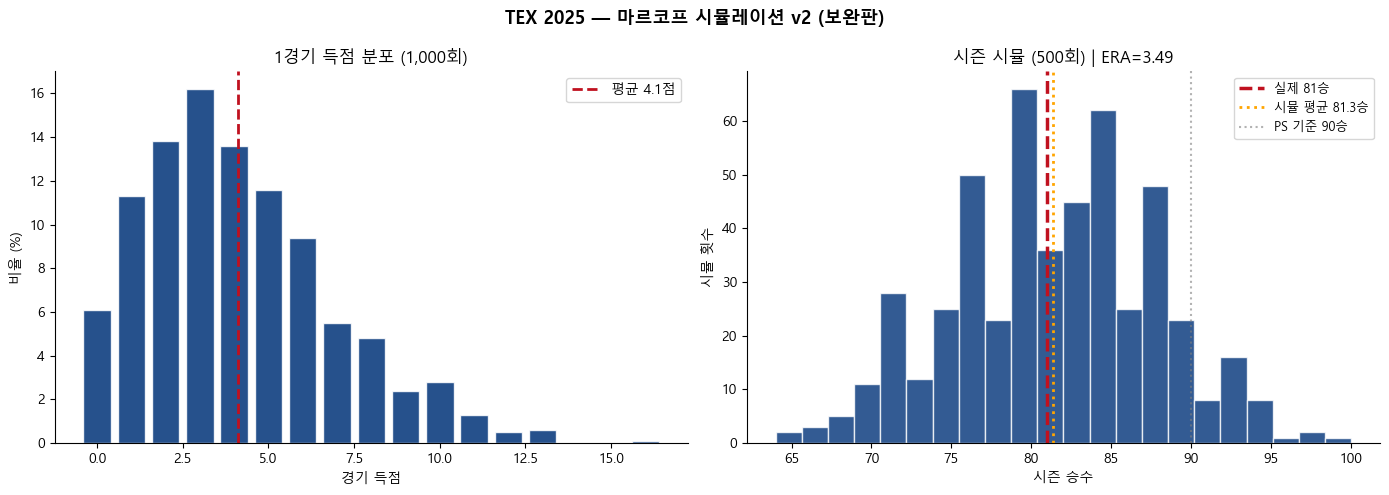

In [17]:
# ── 1경기 득점 분포 (1,000회) ─────────────────────────────────────────────────
np.random.seed(42)
sample_runs = [simulate_game(lineup_probs, lineup_profiles) for _ in range(1000)]

print('=== 1경기 득점 분포 (1,000회) ===')
print(f'  평균:    {np.mean(sample_runs):.2f}점')
print(f'  중앙값:  {np.median(sample_runs):.0f}점')
print(f'  표준편차:{np.std(sample_runs):.2f}')
print(f'  0점 비율:{sample_runs.count(0)/10:.1f}%')
print(f'  5점 이상:{sum(r >= 5 for r in sample_runs)/10:.1f}%')

# ── 시즌 시뮬 (500회) ────────────────────────────────────────────────────────
np.random.seed(0)
actual_W  = int(game_log['win'].sum())
wins_base = simulate_season(lineup_probs, lineup_profiles,
                             n_games=len(game_log), n_sims=500)

print(f'\n=== 시즌 시뮬 요약 (500회) ===')
print(f'  평균:    {wins_base.mean():.1f}승')
print(f'  중앙값:  {np.median(wins_base):.0f}승')
print(f'  5~95th:  {np.percentile(wins_base, 5):.0f} ~ {np.percentile(wins_base, 95):.0f}승')
print(f'  실제 2025: {actual_W}승')

# ── 시각화 ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('TEX 2025 — 마르코프 시뮬레이션 v2 (보완판)', fontsize=13, fontweight='bold')

ax = axes[0]
cnt = Counter(sample_runs)
xs  = sorted(cnt.keys())
ax.bar(xs, [cnt[x] / 10 for x in xs], color='#003278', edgecolor='white', alpha=0.85)
ax.axvline(np.mean(sample_runs), color='#C0111F', lw=2, linestyle='--',
           label=f'평균 {np.mean(sample_runs):.1f}점')
ax.set_xlabel('경기 득점')
ax.set_ylabel('비율 (%)')
ax.set_title('1경기 득점 분포 (1,000회)')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)

ax2 = axes[1]
ax2.hist(wins_base, bins=22, color='#003278', edgecolor='white', alpha=0.8)
ax2.axvline(actual_W,          color='#C0111F', lw=2.5, linestyle='--', label=f'실제 {actual_W}승')
ax2.axvline(wins_base.mean(),  color='orange',  lw=2,   linestyle=':',  label=f'시뮬 평균 {wins_base.mean():.1f}승')
ax2.axvline(90, color='gray', lw=1.5, linestyle=':', alpha=0.6, label='PS 기준 90승')
ax2.set_xlabel('시즌 승수')
ax2.set_ylabel('시뮬 횟수')
ax2.set_title(f'시즌 시뮬 (500회) | ERA={era_actual:.2f}')
ax2.legend(fontsize=9)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('./markov_v2_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. ML 잔차 모델

마르코프 시뮬레이션은 경기 단위 득점·실점 흐름을 재현하지만,  
피타고리안 기대 승수와 실제 승수의 차이까지 모두 설명하지는 못한다.  
따라서 세이브 성공률, 1점 차 승률, 클러치 지표, 불펜 효율 등 잔차에 영향을 줄 수 있는 변수를 활용해 ML 기반 보정 모델을 구성했다.

| 항목 | 내용 |
|---|---|
| **학습 데이터** | MLB 2015~2019, 2021~2024 팀-시즌 데이터 |
| **타깃** | 실제 승수 − 피타고리안 기대 승수 |
| **모델** | Ridge/Lasso/RF/XGBoost 앙상블 |
| **피처** | SV%, 1점 차 승률, 클러치 지표, WHIP, K9, BB9, HR9, IR% 등 |
| **출력** | 시나리오별 잔차 변화량 및 보정 승수 |

In [18]:
# ── 역대 MLB 팀 데이터 피처 엔지니어링 ────────────────────────────────────────
# mlb_hist = mlb_team_seasons.csv (이미 로드됨)
# era_fip_diff, ir_pct, babip_against, go_ao, OPS, sb_pct 등 이미 집계된 컬럼 활용
# 학습: 2015-2019, 2021-2024 (2020 제외)
df = mlb_hist[(mlb_hist['year'] < 2025) & (mlb_hist['year'] != 2020)].copy()

# 피타고리안 기대 승수 (지수 1.83)
df['pyth_wp'] = df['RS']**1.83 / (df['RS']**1.83 + df['RA']**1.83)
df['pyth_W']  = (df['pyth_wp'] * df['G']).round(1)
df['residual'] = df['W'] - df['pyth_W']

# 파생 피처 (mlb_hist에 없는 것만 계산)
df['home_away_diff'] = df['home_wp'] - df['away_wp']
df['k_bb']           = df['K9'] / df['BB9'].clip(0.1)
df['rs_per_g']       = df['RS'] / df['G']
df['SV_pg']          = df['SV'] / df['G']

# ── TEX 2025 실제값 구성 ────────────────────────────────────────────────────
# game_log 기반 집계 (W, onerun_wp, xi_wp 등 실시간 정확값 우선)
sv_val  = float(team_sv['SV'])
bs_val  = float(team_sv['BS'])
svo_val = sv_val + bs_val

# mlb_hist TEX 2025 행 (ir_pct, babip_against, go_ao, OPS, sb_pct, era_fip_diff)
_tex_row = mlb_hist[(mlb_hist['team_id'] == 140) & (mlb_hist['year'] == 2025)].iloc[0]

tex25 = {
    'W':         int(game_log['win'].sum()),
    'L':         int((~game_log['win']).sum()),
    'G':         len(game_log),
    'RS':        float(game_log['R'].sum()),
    'RA':        float(game_log['RA'].sum()),
    'home_wp':   float(game_log[game_log['is_home']]['win'].mean()),
    'away_wp':   float(game_log[~game_log['is_home']]['win'].mean()),
    'onerun_wp': float(game_log[game_log['onerun']]['win'].mean()),
    'onerun_n':  int(game_log['onerun'].sum()),
    'xi_wp':     float(game_log[game_log['extra']]['win'].mean()) if game_log['extra'].any() else 0.5,
    'SV': sv_val, 'BS': bs_val, 'SVO': svo_val,
    'sv_pct': sv_val / svo_val if svo_val > 0 else float(_tex_row['sv_pct']),
    # 투구 (pit_logs 기반 정확값)
    'ERA':  round(era_actual, 2),
    'WHIP': round(whip_actual, 3),
    'K9':   round(k9_actual, 2),
    'BB9':  round(bb9_actual, 2),
    'HR9':  round(hr9_actual, 2),
    # mlb_hist TEX 2025 캐시 (ir_pct, babip_against, go_ao, OPS, sb_pct, era_fip_diff)
    'ir_pct':        float(_tex_row['ir_pct']),
    'babip_against': float(_tex_row['babip_against']),
    'go_ao':         float(_tex_row['go_ao']),
    'OPS':           float(_tex_row['OPS']),
    'sb_pct':        float(_tex_row['sb_pct']),
    'era_fip_diff':  float(_tex_row['era_fip_diff']),
}

# 파생 피처 추가
tex25['home_away_diff'] = tex25['home_wp'] - tex25['away_wp']
tex25['k_bb']           = tex25['K9'] / max(tex25['BB9'], 0.1)
tex25['rs_per_g']       = round(tex25['RS'] / tex25['G'], 3)
tex25['SV_pg']          = tex25['SV'] / tex25['G']

pyth_wp25      = tex25['RS']**1.83 / (tex25['RS']**1.83 + tex25['RA']**1.83)
tex25['pyth_W']  = round(pyth_wp25 * tex25['G'], 1)
tex25['residual']= round(tex25['W'] - tex25['pyth_W'], 1)

# ── 피처 세트 정의 ──────────────────────────────────────────────────────────
# MODEL_FEATURES: 앙상블 ML 학습·예측용 18개
# 제외: home_wp, away_wp (home_away_diff에 통합), FIP (era_fip_diff로 대체),
#       Top1_SV_Ratio (SV_pg·sv_pct와 선형 의존)
MODEL_FEATURES = [
    'sv_pct',         # 세이브 성공률 = SV/(SV+BS)
    'SV_pg',          # 경기당 세이브 (경기 수 정규화)
    'onerun_wp',      # 1점차 경기 승률
    'xi_wp',          # 연장전 승률
    'home_away_diff', # 홈 승률 − 원정 승률
    'ERA',            # 팀 평균자책점
    'WHIP',           # (안타+볼넷)/이닝
    'k_bb',           # K/9 ÷ BB/9
    'K9',             # 9이닝당 탈삼진
    'BB9',            # 9이닝당 볼넷
    'HR9',            # 9이닝당 피홈런
    'ir_pct',         # 물려받은 주자 실점률
    'babip_against',  # 피BABIP
    'go_ao',          # 땅볼/플라이볼 비율
    'OPS',            # 팀 타선 OPS
    'rs_per_g',       # 경기당 득점
    'sb_pct',         # 도루 성공률
    'era_fip_diff',   # ERA − FIP (Fangraphs, 피칭 운 보정)
]
FEATURES = MODEL_FEATURES  # 역호환 alias

# RESIDUAL_PROXY_FEATS: 시나리오 조정용 (pyth_W 반영 피처 ERA·OPS·rs_per_g 제외)
_PYTH_CAPTURED   = {'OPS', 'rs_per_g', 'ERA'}
RESIDUAL_PROXY_FEATS = [f for f in MODEL_FEATURES if f not in _PYTH_CAPTURED]

df_model = df.dropna(subset=MODEL_FEATURES + ['residual']).copy()
print(f'ML 학습 데이터: {len(df_model)}행  |  MODEL_FEATURES: {len(MODEL_FEATURES)}개')
print(f'  (제외: home_wp, away_wp, FIP, Top1_SV_Ratio — 선형 의존 또는 era_fip_diff 대체)')
print(f'\nTEX 2025 — 실제: {tex25["W"]}승 | 기대: {tex25["pyth_W"]}승 | 잔차: {tex25["residual"]:+.1f}')
print(f'  ERA={tex25["ERA"]}  K9={tex25["K9"]}  BB9={tex25["BB9"]}  HR9={tex25["HR9"]}')
print(f'  sv_pct={tex25["sv_pct"]:.3f}  onerun_wp={tex25["onerun_wp"]:.3f}  home_away_diff={tex25["home_away_diff"]:+.3f}')
print(f'  ir_pct={tex25["ir_pct"]:.3f}  babip_against={tex25["babip_against"]:.3f}  go_ao={tex25["go_ao"]:.2f}')
print(f'  OPS={tex25["OPS"]:.3f}  sb_pct={tex25["sb_pct"]:.3f}  era_fip_diff={tex25["era_fip_diff"]:+.3f}')


ML 학습 데이터: 270행  |  MODEL_FEATURES: 18개
  (제외: home_wp, away_wp, FIP, Top1_SV_Ratio — 선형 의존 또는 era_fip_diff 대체)

TEX 2025 — 실제: 81승 | 기대: 90.1승 | 잔차: -9.1
  ERA=3.49  K9=8.43  BB9=2.9  HR9=1.07
  sv_pct=0.561  onerun_wp=0.420  home_away_diff=+0.185
  ir_pct=0.271  babip_against=0.273  go_ao=0.87
  OPS=0.683  sb_pct=0.802  era_fip_diff=-0.453


In [19]:
# (제거: 디버깅 잔재 df.head)

+=========================================================+
|  모델별 Leave-One-Season-Out CV 성능 (잔차 설명력)       |
+=========================================================+
| 모델          Train R2            CV R2     gap     MAE |
+=========================================================+
| Ridge       +0.663     +0.592 +/- 0.109  +0.071  2.07승 |
| Lasso       +0.659     +0.598 +/- 0.105  +0.062  2.06승 |
| RF          +0.806     +0.462 +/- 0.183  +0.344  2.39승 |
| XGBoost     +0.661     +0.490 +/- 0.102  +0.171  2.33승 |
+=========================================================+
  앙상블 CV MAE 평균: 2.213승
TEX 2025 잔차 예측(앙상블): -3.81승  (실제: -9.1승)


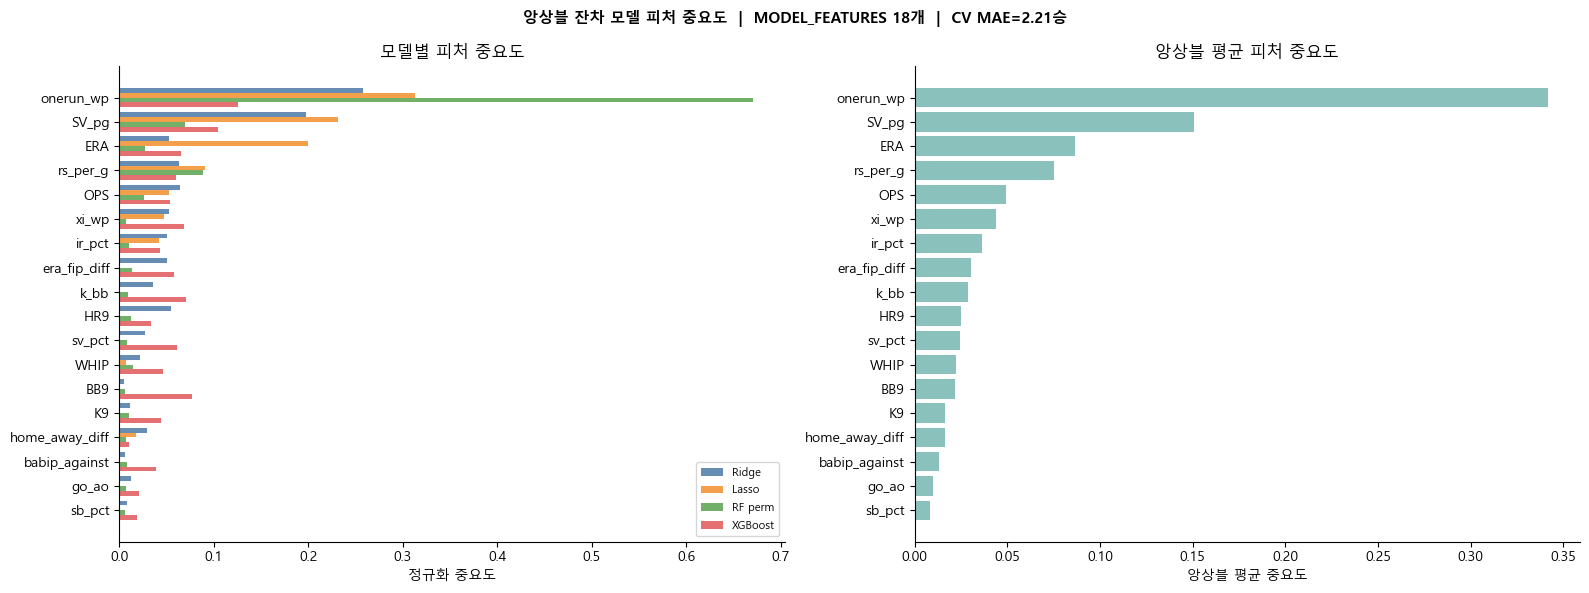

In [20]:
# ── ML 잔차 앙상블 모델 (Ridge · Lasso · RF · XGBoost) ─────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold, GroupKFold
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score
import xgboost as xgb

X_raw = df_model[MODEL_FEATURES].values
y     = df_model['residual'].values

scaler = StandardScaler()
X_sc   = scaler.fit_transform(X_raw)

kf     = KFold(n_splits=5, shuffle=True, random_state=42)
groups = df_model['year'].values
n_seas = df_model['year'].nunique()
gkf    = GroupKFold(n_splits=n_seas)

# ── 모델 학습 ───────────────────────────────────────────────────────────────
# alpha 탐색도 GroupKFold 기반으로 통일 (연도 누수 방지)
_alphas     = np.logspace(-2, 3, 60)
_gkf_splits = list(gkf.split(X_sc, y, groups))

_best_ridge_a = _alphas[np.argmax([
    cross_val_score(Ridge(alpha=a), X_sc, y, cv=_gkf_splits, scoring='r2').mean()
    for a in _alphas
])]
ridge = Ridge(alpha=_best_ridge_a).fit(X_sc, y)

_best_lasso_a = _alphas[np.argmax([
    cross_val_score(Lasso(alpha=a, max_iter=5000), X_sc, y, cv=_gkf_splits, scoring='r2').mean()
    for a in _alphas
])]
lasso = Lasso(alpha=_best_lasso_a, max_iter=5000).fit(X_sc, y)

rf = RandomForestRegressor(n_estimators=500, min_samples_leaf=5, random_state=42)
rf.fit(X_raw, y)

xgb_m = xgb.XGBRegressor(
    n_estimators=100, learning_rate=0.03, max_depth=2,
    subsample=0.7, colsample_bytree=0.7, min_child_weight=3,
    random_state=42, verbosity=0,
)
xgb_m.fit(X_raw, y)

# ── 앙상블 예측 함수 ─────────────────────────────────────────────────────────
def predict_residual(vec_raw, scaler, ridge, lasso, rf, xgb_m):
    # vec_raw: shape (1, n_features), 원본 스케일
    vec_sc = scaler.transform(vec_raw)
    return float(np.mean([
        ridge.predict(vec_sc)[0],
        lasso.predict(vec_sc)[0],
        rf.predict(vec_raw)[0],
        xgb_m.predict(vec_raw)[0],
    ]))

# ── 앙상블 CV MAE — Pipeline으로 scaler 누수 차단 ───────────────────────────
_cv_pipes = [
    ('Ridge',   make_pipeline(StandardScaler(), Ridge(alpha=ridge.alpha)),                  X_raw),
    ('Lasso',   make_pipeline(StandardScaler(), Lasso(alpha=lasso.alpha, max_iter=5000)),   X_raw),
    ('RF',      rf,    X_raw),
    ('XGBoost', xgb_m, X_raw),
]
_cv_mae_dict = {}
for _nm, _pipe, _Xm in _cv_pipes:
    _mae = -cross_val_score(_pipe, _Xm, y,
                             cv=_gkf_splits,
                             scoring='neg_mean_absolute_error')
    _cv_mae_dict[_nm] = float(_mae.mean())
ensemble_cv_mae = float(sum(_cv_mae_dict.values()) / len(_cv_mae_dict))

# ── CV 성능 요약 ─────────────────────────────────────────────────────────────
print('+=========================================================+')
print('|  모델별 Leave-One-Season-Out CV 성능 (잔차 설명력)       |')
print('+=========================================================+')
print(f'| {"모델":10s} {"Train R2":>9s} {"CV R2":>16s}  {"gap":>6s}  {"MAE":>6s} |')
print('+=========================================================+')
for _nm, _pipe, _Xm in _cv_pipes:
    if _nm == 'Ridge':
        tr2 = r2_score(y, ridge.predict(X_sc))
    elif _nm == 'Lasso':
        tr2 = r2_score(y, lasso.predict(X_sc))
    else:
        tr2 = r2_score(y, _pipe.predict(_Xm))
    cv2 = cross_val_score(_pipe, _Xm, y, cv=_gkf_splits, scoring='r2')
    gap = tr2 - cv2.mean()
    print(f'| {_nm:10s}  {tr2:+.3f}     {cv2.mean():+.3f} +/- {cv2.std():.3f}'
          f'  {gap:+.3f}  {_cv_mae_dict[_nm]:.2f}승 |')
print('+=========================================================+')
print(f'  앙상블 CV MAE 평균: {ensemble_cv_mae:.3f}승')

# ── TEX 2025 잔차 점추정 ─────────────────────────────────────────────────────
tex_vec  = np.array([[tex25.get(f, float(df_model[f].mean())) for f in MODEL_FEATURES]])
tex_pred = predict_residual(tex_vec, scaler, ridge, lasso, rf, xgb_m)
print(f'TEX 2025 잔차 예측(앙상블): {tex_pred:+.2f}승  (실제: {tex25["residual"]:+.1f}승)')

# ── feat_std (시나리오 조정폭 기준) ──────────────────────────────────────────
feat_std = df_model[MODEL_FEATURES].std()

# ── 피처 중요도 시각화 ────────────────────────────────────────────────────────
ridge_imp = np.abs(ridge.coef_) / (np.abs(ridge.coef_).sum() + 1e-9)
lasso_imp = np.abs(lasso.coef_) / (np.abs(lasso.coef_).sum() + 1e-9)
pi        = permutation_importance(rf, X_raw, y, n_repeats=30, random_state=42)
rf_imp    = pi.importances_mean.clip(0) / (pi.importances_mean.clip(0).sum() + 1e-9)
xgb_imp   = xgb_m.feature_importances_ / (xgb_m.feature_importances_.sum() + 1e-9)

imp_df = pd.DataFrame({'피처': MODEL_FEATURES,
    'Ridge': ridge_imp, 'Lasso': lasso_imp, 'RF': rf_imp, 'XGBoost': xgb_imp})
imp_df['평균'] = imp_df[['Ridge','Lasso','RF','XGBoost']].mean(axis=1)
imp_df = imp_df.sort_values('평균', ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'앙상블 잔차 모델 피처 중요도  |  MODEL_FEATURES {len(MODEL_FEATURES)}개  |  CV MAE={ensemble_cv_mae:.2f}승',
             fontsize=11, fontweight='bold')
feat_order = imp_df['피처'].tolist()
w = 0.2
_c4 = ['#4E79A7', '#F28E2B', '#59A14F', '#E15759']
ax = axes[0]
for i, (col, color, lbl) in enumerate(zip(['Ridge','Lasso','RF','XGBoost'], _c4, ['Ridge','Lasso','RF perm','XGBoost'])):
    vals = [imp_df.loc[imp_df['피처']==f, col].values[0] for f in feat_order]
    ax.barh(np.arange(len(feat_order)) + i*w, vals, w, label=lbl, color=color, alpha=0.85)
ax.set_yticks(np.arange(len(feat_order)) + 1.5*w)
ax.set_yticklabels(feat_order)
ax.invert_yaxis()
ax.set_xlabel('정규화 중요도')
ax.set_title('모델별 피처 중요도')
ax.legend(fontsize=8)
ax.spines[['top','right']].set_visible(False)
ax2 = axes[1]
_isorted = imp_df.sort_values('평균', ascending=True)
ax2.barh(_isorted['피처'], _isorted['평균'], color='#76B7B2', alpha=0.85)
ax2.set_xlabel('앙상블 평균 중요도')
ax2.set_title('앙상블 평균 피처 중요도')
ax2.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()


## 8. 통합 파이프라인

`run_integrated_simulation()`이 세 요소를 하나로 묶어 실행한다.

```
1. 동적 라인업 샘플링  (LineupPool + scenario boosts)
2. 시뮬레이션 실행     (simulate_season_schedule — 실제 일정)
3. ML 잔차 보정        (Ridge/Lasso/RF/XGBoost 앙상블 residual 보정 + calibration offset 가산)
```

`use_schedule=True`로 실제 2025 일정, 파크팩터, 이닝별 ERA를 모두 적용한다.

In [21]:
def apply_batter_boost(probs, hr_mult=1.0, bb_mult=1.0, k_mult=1.0,
                        single_mult=1.0, double_mult=1.0):
    p = probs.copy()
    p['hr']     = p.get('hr',     0) * hr_mult
    p['bb']     = p.get('bb',     0) * bb_mult
    p['k']      = p.get('k',      0) * k_mult
    p['single'] = p.get('single', 0) * single_mult
    p['double'] = p.get('double', 0) * double_mult
    p = {k: max(0, v) for k, v in p.items()}
    total = sum(p.values())
    return {k: v / total for k, v in p.items()}


def build_scenario_lineup(base_probs, boosts, profiles=None):
    new = [p.copy() for p in base_probs]
    for key, kwargs in boosts.items():
        if isinstance(key, int):
            if key < len(new):
                new[key] = apply_batter_boost(new[key], **kwargs)
        elif isinstance(key, str) and profiles:
            idx = next((i for i, pr in enumerate(profiles) if pr.get('name') == key), None)
            if idx is not None:
                new[idx] = apply_batter_boost(new[idx], **kwargs)
    return new


def run_integrated_simulation(lineup_probs, lineup_profiles,
                               scenario_stats,
                               lineup_boosts=None,
                               calibration_offset=0.0,
                               n_games=162, n_sims=500,
                               use_dynamic_lineup=True,
                               use_schedule=False):
    # 통합 시뮬레이션 v3: Markov + 앙상블 ML 잔차 보정 + Calibration offset
    # ml_model 파라미터 제거, predict_residual() 직접 호출
    era = scenario_stats.get('ERA', era_actual)

    name_boosts = None
    if use_dynamic_lineup and lineup_boosts:
        name_boosts = {}
        for key, val in lineup_boosts.items():
            if isinstance(key, str):
                name_boosts[key] = val
            elif isinstance(key, int) and key < len(LINEUP):
                name_boosts[LINEUP[key]] = val

    if use_schedule:
        pool = LineupPool(bat_pool, running, name_boosts)
        sc_starter_era = scenario_stats.get('starter_era', None)
        wins_arr = simulate_season_schedule(
            lineup_probs, lineup_profiles,
            schedule_opps, team_rspg_map,
            lineup_pool=pool, n_sims=n_sims,
            starter_era_override=sc_starter_era,
        )
    elif use_dynamic_lineup:
        pool = LineupPool(bat_pool, running, name_boosts)
        wins_arr = simulate_season(
            None, None, n_games=n_games, n_sims=n_sims,
            lineup_pool=pool, starter_era=era,
        )
    else:
        sim_probs = (build_scenario_lineup(lineup_probs, lineup_boosts, lineup_profiles)
                     if lineup_boosts else lineup_probs)
        wins_arr = simulate_season(sim_probs, lineup_profiles,
                                   n_games=n_games, n_sims=n_sims, starter_era=era)

    # ── 앙상블 ML 잔차 예측 ───────────────────────────────────────────────────
    feat = {**tex25}
    feat.update(scenario_stats)
    feat['k_bb']           = feat['K9'] / max(feat['BB9'], 0.1)
    feat['home_away_diff'] = feat.get('home_away_diff', tex25['home_away_diff'])
    feat['SV_pg']          = feat.get('SV_pg', tex25['SV_pg'])
    # era_fip_diff: K9/BB9/HR9이 시나리오에 있으면 FIP 역산, 없으면 기준선 유지
    if all(k in scenario_stats for k in ('K9', 'BB9', 'HR9')):
        _tex_fip = tex25['ERA'] - tex25['era_fip_diff']
        _cfip    = _tex_fip - (13*tex25['HR9'] - 2*tex25['K9'] + 3*tex25['BB9']) / 9
        _est_fip = _cfip + (13*feat['HR9'] - 2*feat['K9'] + 3*feat['BB9']) / 9
        feat['era_fip_diff'] = feat['ERA'] - _est_fip
    else:
        feat['era_fip_diff'] = tex25['era_fip_diff']

    x = np.array([[feat.get(f, float(df_model[f].mean())) for f in MODEL_FEATURES]])
    ml_bonus = predict_residual(x, scaler, ridge, lasso, rf, xgb_m)

    return wins_arr + calibration_offset + ml_bonus


print('통합 파이프라인 함수 정의 완료')

통합 파이프라인 함수 정의 완료


## 9. 시나리오 정의

투구 지표와 타선 개별 선수 확률을 조정하는 6개 프리셋을 정의한다.  
실행 셀에서 `ACTIVE_SCENARIO` 값만 바꾸면 해당 설정으로 시뮬레이션된다.

| 시나리오 | ERA | SV% | 1점차 승률 | 타선 조정 |
|---|---|---|---|---|
| 기준선 | 실제 | 실제 | 실제 | 없음 |
| 불펜 강화 | 실제 | 0.700 | 0.450 | 없음 |
| 선발 에이스 | 3.15 | 실제 | 실제 | 없음 |
| Langford 도약 | 실제 | 실제 | 실제 | Langford · Seager ↑ |
| 종합 희망 | 3.40 | 0.820 | 0.530 | Langford · Seager · García ↑ |
| 비관 | 4.40 | 0.620 | 0.370 | Semien · García ↓ |


In [22]:
SCENARIOS = {

    # ── 1. 기준선 — 2025 실제값 ────────────────────────────────────────────
    '기준선 (2025 실제)': {
        'stats': {
            'ERA':       tex25['ERA'],
            'sv_pct':    tex25['sv_pct'],
            'onerun_wp': tex25['onerun_wp'],
            'xi_wp':     tex25['xi_wp'],
            'K9':        tex25['K9'],
            'BB9':       tex25['BB9'],
            'HR9':       tex25['HR9'],
            'WHIP':      tex25['WHIP'],
        },
        'boosts': None,
        'color':  '#888888',
    },

    # ── 2. 불펜 강화 — SV% 70%, 선발·타선 동일 ────────────────────────────
    # 마무리 투수 개선 or 셋업 보강 시 세이브 성공률 0.70 달성 가정
    # 불펜이 리드를 잘 지키면 1점차 승률도 자연스럽게 상승
    '불펜 강화 (SV% 70%)': {
        'stats': {
            'ERA':       tex25['ERA'],
            'sv_pct':    0.700,
            'onerun_wp': min(tex25['onerun_wp'] + 0.030, 0.600),
            'xi_wp':     tex25['xi_wp'],
            'K9':        tex25['K9'],
            'BB9':       tex25['BB9'],
            'HR9':       tex25['HR9'],
            'WHIP':      tex25['WHIP'],
        },
        'boosts': None,
        'color': '#2E86AB',
    },

    # ── 3. 선발 에이스 — ERA 3.15, 타선 동일 ──────────────────────────────
    # 에이스급 선발진 유지 시 (Nathan Eovaldi 풀시즌 + 신예 안착 가정)
    # K↑ BB↓ HR↓ → FIP 개선 → ML 잔차에도 긍정적 영향
    '선발 에이스 (ERA 3.15)': {
        'stats': {
            'ERA':       3.15,
            'sv_pct':    tex25['sv_pct'],
            'onerun_wp': tex25['onerun_wp'],
            'xi_wp':     tex25['xi_wp'],
            'K9':        9.5,
            'BB9':       2.6,
            'HR9':       0.90,
            'WHIP':      1.05,
        },
        'boosts': None,
        'color': '#7B2D8B',
    },

    # ── 4. Langford 도약 — 투구·불펜 동일, 타선만 개선 ────────────────────
    # Wyatt Langford 2년차 도약: HR·2루타·BB ↑, K ↓
    # Corey Seager: 꾸준한 컨택 유지
    'Langford 도약': {
        'stats': {
            'ERA':       tex25['ERA'],
            'sv_pct':    tex25['sv_pct'],
            'onerun_wp': tex25['onerun_wp'],
            'xi_wp':     tex25['xi_wp'],
            'K9':        tex25['K9'],
            'BB9':       tex25['BB9'],
            'HR9':       tex25['HR9'],
            'WHIP':      tex25['WHIP'],
        },
        # Langford: HR+30%, 2루타+20%, BB+15%, K-10%
        # Seager  : HR+10%, K-8%
        'boosts': {
            'Wyatt Langford': {'hr_mult': 1.30, 'double_mult': 1.20, 'bb_mult': 1.15, 'k_mult': 0.90},
            'Corey Seager':   {'hr_mult': 1.10, 'k_mult': 0.92},
        },
        'color': '#F18F01',
    },

    # ── 5. 종합 희망 — 투타 동시 개선 ─────────────────────────────────────
    '종합 희망 (Hopeful)': {
        'stats': {
            'ERA':       3.40,
            'sv_pct':    0.820,
            'onerun_wp': 0.530,
            'xi_wp':     tex25['xi_wp'] + 0.02,
            'K9':        9.3,
            'BB9':       2.7,
            'HR9':       0.95,
            'WHIP':      1.12,
        },
        'boosts': {
            'Wyatt Langford': {'hr_mult': 1.25, 'double_mult': 1.15, 'bb_mult': 1.10, 'k_mult': 0.90},
            'Corey Seager':   {'hr_mult': 1.12, 'k_mult': 0.88},
            'Adolis García':  {'hr_mult': 1.10, 'bb_mult': 1.05},
        },
        'color': '#27AE60',
    },

    # ── 6. 비관 — 부상·슬럼프 ───────────────────────────────────────────
    '비관 (부상·슬럼프)': {
        'stats': {
            'ERA':       4.40,
            'sv_pct':    0.620,
            'onerun_wp': 0.370,
            'xi_wp':     tex25['xi_wp'] - 0.05,
            'K9':        7.5,
            'BB9':       3.9,
            'HR9':       1.45,
            'WHIP':      1.42,
        },
        # Semien: HR-20%, BB-10%
        # García: K+15%, HR-15%
        'boosts': {
            'Marcus Semien': {'hr_mult': 0.80, 'bb_mult': 0.90},
            'Adolis García': {'k_mult': 1.15, 'hr_mult': 0.85},
        },
        'color': '#E74C3C',
    },
}

print(f'시나리오 {len(SCENARIOS)}개 정의 완료')
print(f"{'시나리오':<22} {'ERA':>6} {'SV%':>6} {'1점차':>6} {'타선 boosts'}")
print('-' * 60)
for name, sc in SCENARIOS.items():
    s = sc['stats']
    boosts = str(list(sc['boosts'].keys())) if sc['boosts'] else '-'
    print(f"  {name:<20} {s['ERA']:>6.2f} {s['sv_pct']:>6.3f} {s['onerun_wp']:>6.3f}  {boosts}")


시나리오 6개 정의 완료
시나리오                      ERA    SV%    1점차 타선 boosts
------------------------------------------------------------
  기준선 (2025 실제)          3.49  0.561  0.420  -
  불펜 강화 (SV% 70%)        3.49  0.700  0.450  -
  선발 에이스 (ERA 3.15)      3.15  0.561  0.420  -
  Langford 도약            3.49  0.561  0.420  ['Wyatt Langford', 'Corey Seager']
  종합 희망 (Hopeful)        3.40  0.820  0.530  ['Wyatt Langford', 'Corey Seager', 'Adolis García']
  비관 (부상·슬럼프)            4.40  0.620  0.370  ['Marcus Semien', 'Adolis García']


## 10. 시뮬레이션 실행

`ACTIVE_SCENARIO`를 선택하면 해당 파라미터로 아래 과정이 실행된다.

```
시나리오 파라미터 적용
  → 동적 라인업 샘플링 (경기마다 출전 비율 기반)
  → 실제 162경기 일정 순서로 공격/수비 시뮬레이션
      · 홈/원정 구장 파크팩터 적용
      · 이닝별 ERA (선발 → 셋업 → 마무리) 적용
  → ML 잔차 보정
  → 승수 분포 출력
```

In [23]:
# -- 섹션 10 실행 전 필수 셋업 --
# simulate_season_schedule 과 schedule 데이터를 섹션 11보다 앞에 정의

# ── 1. 스케줄 컬럼 감지 ────────────────────────────────────────────────────────
print('▶ game_log 컬럼:', game_log.columns.tolist())

_opp_cands = [c for c in game_log.columns
              if c.lower() in ('opp', 'opponent', 'opposing_team', 'opp_team')]
if not _opp_cands:
    raise ValueError(
        "상대팀 컬럼 없음 — game_log CSV에 'Opp' 또는 'Opponent' 컬럼이 필요합니다.\n"
        f"현재 컬럼: {game_log.columns.tolist()}"
    )
OPP_COL = _opp_cands[0]
schedule_opps = game_log[OPP_COL].tolist()
print(f"  → 상대팀 컬럼: '{OPP_COL}' | {len(schedule_opps)}경기 | {game_log[OPP_COL].nunique()}팀")
print(f"  → 고유 상대팀: {sorted(game_log[OPP_COL].unique())}\n")

# ── 2. 팀별 RS/G — mlb_hist 2025 직접 사용 ────────────────────────────────────
# bat_all은 다중팀 선수(예: 'Atlanta,Texas')가 섞여 groupby 집계가 부정확함
# mlb_hist는 이미 로드된 팀 레벨 집계이므로 그 문제가 없음
hist_2025 = mlb_hist[mlb_hist['year'] == 2025].copy()
hist_2025['RS_per_G'] = (hist_2025['RS'] / hist_2025['G'].clip(1)).clip(2.0, 7.0)
team_off = hist_2025.set_index('team')[['RS_per_G']].copy()
LEAGUE_AVG_RS = float(team_off['RS_per_G'].mean())

print(f'  리그 평균 RS/G: {LEAGUE_AVG_RS:.2f}')
print('\n팀별 RS/G (상위 10):')
print(team_off['RS_per_G'].sort_values(ascending=False).head(10).to_string())

# ── 3. game_log Opp 코드 → mlb_hist 팀명 매핑 ─────────────────────────────────
# game_log는 BR 3자 약어, mlb_hist는 정식 팀명 — 양방향 fallback 매핑
BR_TO_HIST = {
    'TEX': 'Texas Rangers',          'HOU': 'Houston Astros',
    'SEA': 'Seattle Mariners',        'LAA': 'Los Angeles Angels',
    'OAK': 'Athletics',               'MIN': 'Minnesota Twins',
    'CLE': 'Cleveland Guardians',     'KC':  'Kansas City Royals',
    'DET': 'Detroit Tigers',          'CWS': 'Chicago White Sox',
    'NYY': 'New York Yankees',        'BOS': 'Boston Red Sox',
    'TOR': 'Toronto Blue Jays',       'TB':  'Tampa Bay Rays',
    'BAL': 'Baltimore Orioles',       'ATL': 'Atlanta Braves',
    'NYM': 'New York Mets',           'PHI': 'Philadelphia Phillies',
    'MIA': 'Miami Marlins',           'WSN': 'Washington Nationals',
    'CHC': 'Chicago Cubs',            'MIL': 'Milwaukee Brewers',
    'STL': 'St. Louis Cardinals',     'CIN': 'Cincinnati Reds',
    'PIT': 'Pittsburgh Pirates',      'LAD': 'Los Angeles Dodgers',
    'SF':  'San Francisco Giants',    'SD':  'San Diego Padres',
    'COL': 'Colorado Rockies',        'ARI': 'Arizona Diamondbacks',
    # game_log 실제 약어 (BR 구형과 다른 팀)
    'ATH': 'Athletics',               'KCR': 'Kansas City Royals',
    'CHW': 'Chicago White Sox',       'TBR': 'Tampa Bay Rays',
    'SFG': 'San Francisco Giants',    'SDP': 'San Diego Padres',
}

def _find_rs_pg(opp_code, off_df, fallback):
    """game_log Opp 코드 → RS_per_G (직접 → BR매핑 → 부분문자열 → fallback)"""
    if opp_code in off_df.index:
        return float(off_df.loc[opp_code, 'RS_per_G'])
    mapped = BR_TO_HIST.get(opp_code.upper())
    if mapped and mapped in off_df.index:
        return float(off_df.loc[mapped, 'RS_per_G'])
    for tm in off_df.index:
        if opp_code.upper() in tm.upper() or tm.upper() in opp_code.upper():
            return float(off_df.loc[tm, 'RS_per_G'])
    return fallback

team_rspg_map = {opp: _find_rs_pg(opp, team_off, LEAGUE_AVG_RS)
                 for opp in sorted(set(schedule_opps))}


# TEX 투구력 기반 상대 득점 조정 (ERA 비율)
MLB_AVG_ERA = float(mlb_hist[mlb_hist["year"]==2025]["ERA"].mean())


# 상대팀 약어 → team_id 매핑 (2025)
_OPP_MAP = {
    'ARI':109,'ATH':133,'ATL':144,'BAL':110,'BOS':111,
    'CHC':112,'CHW':145,'CIN':113,'CLE':114,'COL':115,
    'DET':116,'HOU':117,'KCR':118,'LAA':108,'LAD':119,
    'MIA':146,'MIL':158,'MIN':142,'NYM':121,'NYY':147,
    'PHI':143,'PIT':134,'SDP':135,'SEA':136,'SFG':137,
    'STL':138,'TBR':139,'TEX':140,'TOR':141,'WSN':120,
}
_era_by_id = mlb_hist[mlb_hist['year']==2025].set_index('team_id')['ERA']
opp_era_map = {abbr: float(_era_by_id.get(tid, MLB_AVG_ERA))
               for abbr, tid in _OPP_MAP.items()}

def simulate_season_schedule(batter_probs_list, batter_profiles,
                              schedule_opps, rspg_map,
                              lineup_pool=None, n_sims=500,
                              starter_era_override=None,
                              track_player_stats=False):
    """
    [개선] 162경기 시뮬레이션 — Binomial 재샘플링 + 선수별 성적 추적 옵션
    starter_era_override: 전체 ERA 덮어쓰기 대신 _era_scale 비율로 각 선발 ERA에 비례 적용
    track_player_stats=True → (wins_arr, bat_stats, pit_stats, bp_stats, team_stats) 반환
    """
    results        = []
    all_bat_stats  = {} if track_player_stats else None
    all_pit_stats  = {} if track_player_stats else None
    all_bp_stats   = {} if track_player_stats else None
    all_team_stats = {'W': 0.0, 'L': 0.0, 'home_W': 0.0, 'home_L': 0.0,
                      'away_W': 0.0, 'away_L': 0.0, 'opp': {}} if track_player_stats else None

    for sim_idx in range(n_sims):
        wins = 0

        # ── Binomial 재샘플링: 이번 시행의 타자 출전 비중 ──────────────────
        if track_player_stats and lineup_pool is not None:
            for name, p in _batter_binom_p.items():
                tg = int(np.random.binomial(162, p))
                lineup_pool._w[name] = max(tg / 162.0, 0.001)

        # ── Binomial 재샘플링: 이번 시행의 rotation 재구성 ──────────────────
        if track_player_stats:
            _trot = []
            for name, p_gs in _starter_binom_p.items():
                tgs   = int(np.random.binomial(162, p_gs))
                era_v = float(_starter_stats.loc[name, 'ERA'])
                ip_v  = float(_starter_stats.loc[name, 'avg_ip'])
                _trot.extend([(name, era_v, ip_v)] * tgs)
            np.random.shuffle(_trot)
            if _trot:
                _t_names = [e[0] for e in _trot]
                _t_eras  = [e[1] for e in _trot]
                _t_ips   = [e[2] for e in _trot]
            else:
                _t_names = rotation_name_list
                _t_eras  = rotation_era_list
                _t_ips   = rotation_ip_list
        else:
            _t_names = rotation_name_list
            _t_eras  = rotation_era_list
            _t_ips   = rotation_ip_list

        # ── 이번 시행의 타자/투수 누적기 ─────────────────────────────────────
        trial_bat    = {} if track_player_stats else None
        trial_pit    = {} if track_player_stats else None
        trial_bp     = {} if track_player_stats else None
        trial_team   = {'W': 0, 'L': 0, 'home_W': 0, 'home_L': 0,
                        'away_W': 0, 'away_L': 0, 'opp': {}} if track_player_stats else None
        recent_bp_apps = {}  # {pitcher: [last2 game_idx]} — 연투 추적

        for game_idx, (opp, is_home) in enumerate(zip(schedule_opps, schedule_home)):
            if lineup_pool is not None:
                game_probs, game_profiles, game_names = lineup_pool.sample()
            else:
                game_probs, game_profiles = batter_probs_list, batter_profiles
                game_names = []

            # 구장 파크팩터 적용
            stadium = 'TEX' if is_home else opp
            pf = park_factor_map.get(stadium, {})
            if pf:
                game_probs = [scale_hit_probs(p, pf) for p in game_probs]

            # ① 선발 로테이션 ERA + 소화 이닝 (_era_scale 비율 적용)
            rot_idx = game_idx % len(_t_eras)
            if starter_era_override is not None:
                _era_scale        = starter_era_override / max(era_actual, 0.01)
                game_starter_era  = _t_eras[rot_idx] * _era_scale
                game_starter_ip   = _t_ips[rot_idx]
                game_starter_name = _t_names[rot_idx] if _t_names else None
            else:
                _era_scale        = 1.0
                game_starter_era  = _t_eras[rot_idx]
                game_starter_ip   = _t_ips[rot_idx]
                game_starter_name = _t_names[rot_idx] if _t_names else None

            # ② 상대팀 공격력 비율 (RS/G 기반)
            opp_rs    = rspg_map.get(opp, LEAGUE_AVG_RS)
            opp_ratio = opp_rs / LEAGUE_AVG_RS
            # ③ 상대팀 투수 K/9·BB/9·HR/9 → TEX 타격 이벤트 보정
            pit_f     = opp_pit_factors_map.get(opp, {'k_factor':1.0,'bb_factor':1.0,'hr_factor':1.0})
            # ④ 상대팀 ERA → TEX 단타·2루타 확률 보정 (MLB 평균 대비)
            _opp_era   = opp_era_map.get(opp, MLB_AVG_ERA)
            pit_f['hit_factor'] = float(np.clip(MLB_AVG_ERA / _opp_era, 0.85, 1.15))
            adj_probs = [adjust_probs_for_pitcher(p, **pit_f) for p in game_probs]

            # 이닝별 이벤트 추적 (tracking 모드만)
            if track_player_stats and game_names:
                slot_evts = [{} for _ in range(len(game_names))]
            else:
                slot_evts = None

            tex_runs, tex_inning_runs = simulate_game(adj_probs, game_profiles,
                                                  slot_evts=slot_evts, return_per_inning=True)

            # 타자 이벤트 누적
            if track_player_stats and game_names and slot_evts is not None:
                for slot, name in enumerate(game_names):
                    if name not in trial_bat:
                        trial_bat[name] = {'G': 0}
                    trial_bat[name]['G'] += 1
                    if slot < len(slot_evts):
                        for ev, cnt in slot_evts[slot].items():
                            trial_bat[name][ev] = trial_bat[name].get(ev, 0) + cnt

            # IP 먼저 샘플링 (opp_runs 계산과 pitcher tracking 공유)
            _std_ip  = float(np.std(_sp_ip_dist)) if len(_sp_ip_dist) > 1 else 1.0
            _game_ip = float(np.clip(np.random.normal(game_starter_ip, _std_ip), 0.0, 9.0))

            opp_runs, _starter_er = simulate_opponent_runs_by_inning(
                starter_era=game_starter_era,
                starter_ip_fixed=_game_ip,
                park_factor=pf.get('overall', 1.0),
                opp_strength_ratio=opp_ratio,
                bp_tracker=trial_bp,
                starter_name=game_starter_name,
                game_idx=game_idx,
                recent_apps=recent_bp_apps,
                tex_inning_runs=tex_inning_runs,
                return_starter_er=True,
            )

            # 선발 투수 성적 누적 (_starter_er은 위 opp_runs와 동일한 샘플)
            if track_player_stats and game_starter_name:
                if game_starter_name not in trial_pit:
                    trial_pit[game_starter_name] = {'GS': 0, 'IP_sum': 0.0, 'ER': 0.0, 'H': 0.0, 'BB': 0.0, 'K': 0.0}
                _bb9_s = float(_starter_stats.loc[game_starter_name, 'BB9']) if game_starter_name in _starter_stats.index else _LG_BB9
                _k9_s  = float(_starter_stats.loc[game_starter_name, 'K9'])  if game_starter_name in _starter_stats.index else _LG_K9
                _whip_s= float(_starter_stats.loc[game_starter_name, 'WHIP'])if game_starter_name in _starter_stats.index else 1.30
                _k9_s   = _k9_s   / max(_era_scale, 0.1)   # ERA↓ → K9↑
                _bb9_s  = _bb9_s  * _era_scale              # ERA↓ → BB9↓
                _whip_s = _whip_s * _era_scale              # ERA↓ → WHIP↓
                _bb    = float(np.random.poisson(max(1e-9, _bb9_s * _game_ip / 9)))
                _k     = float(np.random.poisson(max(1e-9, _k9_s  * _game_ip / 9)))
                _h     = float(np.random.poisson(max(1e-9, max(0.0, _whip_s * _game_ip - _bb))))
                trial_pit[game_starter_name]['GS']     += 1
                trial_pit[game_starter_name]['IP_sum'] += _game_ip
                trial_pit[game_starter_name]['ER']     += _starter_er
                trial_pit[game_starter_name]['H']      += _h
                trial_pit[game_starter_name]['BB']     += _bb
                trial_pit[game_starter_name]['K']      += _k

            won = int(tex_runs > opp_runs)
            wins += won
            if track_player_stats and trial_team is not None:
                if won:
                    trial_team['W'] += 1
                    if is_home: trial_team['home_W'] += 1
                    else:       trial_team['away_W'] += 1
                else:
                    trial_team['L'] += 1
                    if is_home: trial_team['home_L'] += 1
                    else:       trial_team['away_L'] += 1
                if opp not in trial_team['opp']:
                    trial_team['opp'][opp] = {'W': 0, 'L': 0}
                trial_team['opp'][opp]['W' if won else 'L'] += 1

        results.append(wins)

        # 시행 결과를 전체 누적기에 합산
        if track_player_stats:
            for name, stats in trial_bat.items():
                if name not in all_bat_stats:
                    all_bat_stats[name] = {}
                for k, v in stats.items():
                    all_bat_stats[name][k] = all_bat_stats[name].get(k, 0) + v
            for name, stats in trial_pit.items():
                if name not in all_pit_stats:
                    all_pit_stats[name] = {}
                for k, v in stats.items():
                    all_pit_stats[name][k] = all_pit_stats[name].get(k, 0) + v
            if track_player_stats and trial_bp:
                for name, stats in trial_bp.items():
                    if name not in all_bp_stats:
                        all_bp_stats[name] = {}
                    for k, v in stats.items():
                        all_bp_stats[name][k] = all_bp_stats[name].get(k, 0) + v
            if track_player_stats and trial_team:
                for k in ['W', 'L', 'home_W', 'home_L', 'away_W', 'away_L']:
                    all_team_stats[k] += trial_team[k]
                for _opp, wl in trial_team['opp'].items():
                    if _opp not in all_team_stats['opp']:
                        all_team_stats['opp'][_opp] = {'W': 0.0, 'L': 0.0}
                    all_team_stats['opp'][_opp]['W'] += wl['W']
                    all_team_stats['opp'][_opp]['L'] += wl['L']

    if track_player_stats:
        for name in all_bat_stats:
            for k in all_bat_stats[name]:
                all_bat_stats[name][k] /= n_sims
        for name in all_pit_stats:
            for k in all_pit_stats[name]:
                all_pit_stats[name][k] /= n_sims
        for name in all_bp_stats:
            for k in all_bp_stats[name]:
                all_bp_stats[name][k] /= n_sims
        for k in ['W', 'L', 'home_W', 'home_L', 'away_W', 'away_L']:
            all_team_stats[k] /= n_sims
        for _opp in all_team_stats['opp']:
            all_team_stats['opp'][_opp]['W'] /= n_sims
            all_team_stats['opp'][_opp]['L'] /= n_sims
        return np.array(results), all_bat_stats, all_pit_stats, all_bp_stats, all_team_stats

    return np.array(results)



print("섹션 10 실행 준비 완료")
print("  상대팀 수:", len(team_rspg_map), "팀 | 경기수:", len(schedule_opps))


▶ game_log 컬럼: ['Date', 'Tm', 'Home_Away', 'Opp', 'W/L', 'R', 'RA', 'Inn', 'W-L', 'Rank', 'GB', 'Win', 'Loss', 'Save', 'Time', 'D/N', 'Attendance', 'cLI', 'Streak', 'Orig. Scheduled', 'win', 'is_home', 'run_diff', 'onerun', 'extra']
  → 상대팀 컬럼: 'Opp' | 162경기 | 29팀
  → 고유 상대팀: ['ARI', 'ATH', 'ATL', 'BAL', 'BOS', 'CHC', 'CHW', 'CIN', 'CLE', 'COL', 'DET', 'HOU', 'KCR', 'LAA', 'LAD', 'MIA', 'MIL', 'MIN', 'NYM', 'NYY', 'PHI', 'PIT', 'SDP', 'SEA', 'SFG', 'STL', 'TBR', 'TOR', 'WSN']

  리그 평균 RS/G: 4.45

팀별 RS/G (상위 10):
team
New York Yankees         5.240741
Los Angeles Dodgers      5.092593
Milwaukee Brewers        4.975309
Toronto Blue Jays        4.925926
Chicago Cubs             4.895062
Arizona Diamondbacks     4.882716
Boston Red Sox           4.851852
Philadelphia Phillies    4.802469
New York Mets            4.728395
Seattle Mariners         4.728395
섹션 10 실행 준비 완료
  상대팀 수: 29 팀 | 경기수: 162


In [24]:
# ── 스케줄 매핑 fallback=0 검증 ─────────────────────────────────────────
# team_rspg_map, team_off, BR_TO_HIST는 Cell 34(섹션 10 셋업)에서 계산됨
_fall_opps = [
    o for o in team_rspg_map
    if o not in team_off.index
    and BR_TO_HIST.get(o.upper(), '') not in team_off.index
]
n_fall = len(_fall_opps)
if n_fall == 0:
    print(f'[OK] team_rspg_map {len(team_rspg_map)}팀 — fallback 없음 (전원 직접·BR 매핑)')
else:
    print(f'[경고] fallback {n_fall}팀: {_fall_opps}  <- BR_TO_HIST에 추가 필요')

[OK] team_rspg_map 29팀 — fallback 없음 (전원 직접·BR 매핑)


맞대결 시뮬레이션 함수 정의 완료
  ERA 조정 계수: 3.49 / 4.15 = 0.841


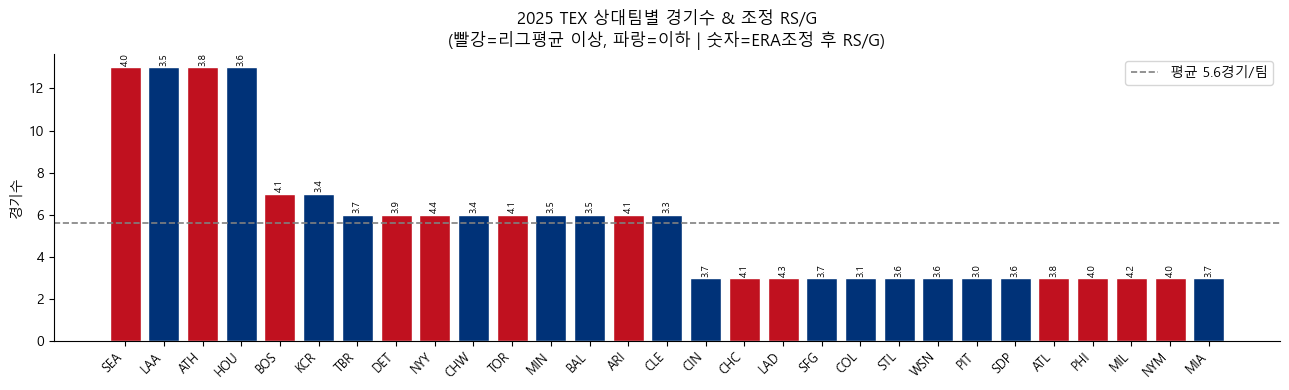

In [25]:
def simulate_opponent_runs_by_team(opp_code, rspg_map,
                                   tex_starter_era=None,
                                   tex_bullpen_era=None,
                                   mlb_avg_era=MLB_AVG_ERA,
                                   overdispersion=5):
    """상대팀별 득점 시뮬 (NegBin, 팀 RS/G 기반, TEX 선발/불펜 ERA 가중 조정)"""
    _s = tex_starter_era if tex_starter_era is not None else era_actual
    _b = tex_bullpen_era if tex_bullpen_era is not None else era_actual
    tex_eff_era = (_s * starter_ip_avg + _b * max(0, 9 - starter_ip_avg)) / 9
    raw_mu = max(0.5, rspg_map.get(opp_code, LEAGUE_AVG_RS))
    adj_mu = raw_mu * (tex_eff_era / mlb_avg_era)
    p = overdispersion / (overdispersion + adj_mu)
    return int(np.random.negative_binomial(overdispersion, p))


print(f'맞대결 시뮬레이션 함수 정의 완료')
print(f'  ERA 조정 계수: {era_actual:.2f} / {MLB_AVG_ERA:.2f} = {era_actual/MLB_AVG_ERA:.3f}')

# ── 상대팀별 경기수 + RS/G 확인 ───────────────────────────────────────────────
opp_cnts = game_log[OPP_COL].value_counts().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(13, 4))
bar_colors = ['#C0111F' if team_rspg_map.get(t, LEAGUE_AVG_RS) >= LEAGUE_AVG_RS
              else '#003278' for t in opp_cnts.index]
bars = ax.bar(opp_cnts.index, opp_cnts.values, color=bar_colors, edgecolor='white')
ax.axhline(opp_cnts.mean(), color='gray', ls='--', lw=1.2,
           label=f'평균 {opp_cnts.mean():.1f}경기/팀')
for bar, tm in zip(bars, opp_cnts.index):
    rs = team_rspg_map.get(tm, LEAGUE_AVG_RS)
    adj = rs * (era_actual / MLB_AVG_ERA)
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{adj:.1f}', ha='center', va='bottom', fontsize=7, rotation=90)
ax.set_title('2025 TEX 상대팀별 경기수 & 조정 RS/G\n(빨강=리그평균 이상, 파랑=이하 | 숫자=ERA조정 후 RS/G)')
ax.set_ylabel('경기수')
plt.xticks(rotation=45, ha='right', fontsize=9)
ax.legend(); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()


In [26]:
# ── calibration_offset 계산 (앙상블 residual + simulate_season_schedule 기준) ──
# simulate_season_schedule이 Cell 34에서 정의된 후 실행해야 함
# ── calibration_offset 계산 (앙상블 residual 기준, Markov = simulate_season_schedule) ──
np.random.seed(99)
_pool_cal = LineupPool(bat_pool, running, name_boosts=None)
_base_arr = simulate_season_schedule(
    lineup_probs, lineup_profiles,
    schedule_opps, team_rspg_map,
    lineup_pool=_pool_cal, n_sims=300,
)

_tex_feat_base = np.array([[tex25.get(f, float(df_model[f].mean())) for f in MODEL_FEATURES]])
ml_baseline    = predict_residual(_tex_feat_base, scaler, ridge, lasso, rf, xgb_m)

calibration_offset = (tex25['W'] - _base_arr.mean()) - ml_baseline
print(f'\nMarkov baseline (schedule, 300회): {_base_arr.mean():.1f}승  (실제: {tex25["W"]}승)')
print(f'ML baseline (앙상블)               : {ml_baseline:+.2f}승')
print(f'보정값 (순수 잔차)                  : {calibration_offset:+.2f}승')
print(f'검증 (기준선 예측)                  : {_base_arr.mean() + calibration_offset + ml_baseline:.1f}승  ← {tex25["W"]}승과 일치해야 함')



Markov baseline (schedule, 300회): 78.0승  (실제: 81승)
ML baseline (앙상블)               : -3.81승
보정값 (순수 잔차)                  : +6.86승
검증 (기준선 예측)                  : 81.0승  ← 81승과 일치해야 함


[기준선 (2025 실제)] 시뮬레이션 실행 중... (실제 일정 162경기 × 500회)

=== [기준선 (2025 실제)] 결과 ===
  평균 승수   : 80.7승
  중앙값      : 81승
  PS 진출(90승↑): 6.6%
  5~95% 범위  : 71~90승
  (2025 실제  : 81승)


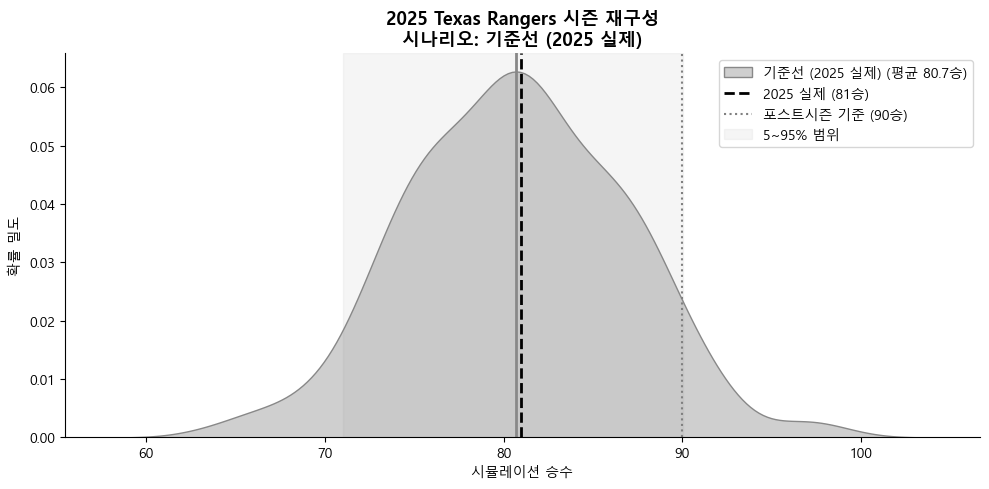

In [27]:
# ── 시나리오 선택 ───────────────────────────────────────────────────────────
# 아래 ACTIVE_SCENARIO 값만 바꾸면 해당 시나리오로 시뮬레이션 실행
# 선택지: '기준선 (2025 실제)', '불펜 강화 (SV% 70%)', '선발 에이스 (ERA 3.15)'
#         'Langford 도약', '종합 희망 (Hopeful)', '비관 (부상·슬럼프)'

ACTIVE_SCENARIO = '기준선 (2025 실제)'

sc = SCENARIOS[ACTIVE_SCENARIO]

np.random.seed(42)
print(f'[{ACTIVE_SCENARIO}] 시뮬레이션 실행 중... (실제 일정 162경기 × 500회)')

results = run_integrated_simulation(
    lineup_probs, lineup_profiles,
    sc['stats'],
    lineup_boosts=sc['boosts'],
    calibration_offset=calibration_offset,
    n_sims=500,
    use_schedule=True,
)

# ── 결과 출력 ────────────────────────────────────────────────────────────────
avg_w   = results.mean()
med_w   = float(np.median(results))
ps_prob = (results >= 90).mean() * 100
p5, p95 = np.percentile(results, 5), np.percentile(results, 95)

print(f'\n=== [{ACTIVE_SCENARIO}] 결과 ===')
print(f'  평균 승수   : {avg_w:.1f}승')
print(f'  중앙값      : {med_w:.0f}승')
print(f'  PS 진출(90승↑): {ps_prob:.1f}%')
print(f'  5~95% 범위  : {p5:.0f}~{p95:.0f}승')
print(f'  (2025 실제  : {tex25["W"]}승)')

# ── 분포 시각화 ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(results, ax=ax, color=sc['color'], fill=True, alpha=0.4,
            label=f'{ACTIVE_SCENARIO} (평균 {avg_w:.1f}승)')
ax.axvline(avg_w,        color=sc['color'], lw=2,   linestyle='-')
ax.axvline(tex25['W'],   color='black',     lw=2,   linestyle='--',
           label=f'2025 실제 ({tex25["W"]}승)')
ax.axvline(90,           color='gray',      lw=1.5, linestyle=':',
           label='포스트시즌 기준 (90승)')
ax.axvspan(p5, p95, alpha=0.08, color=sc['color'], label=f'5~95% 범위')
ax.set_xlabel('시뮬레이션 승수')
ax.set_ylabel('확률 밀도')
ax.set_title(f'2025 Texas Rangers 시즌 재구성\n시나리오: {ACTIVE_SCENARIO}',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('./markov_v2_scenarios.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. 스케줄 시뮬레이션 구성 요소

실제 일정 기반 시뮬레이션에서 사용하는 보조 함수와 데이터를 설정한다.

| 항목 | 내용 |
|---|---|
| `schedule_opps` | `game_log`에서 추출한 162경기 상대팀 순서 |
| `schedule_home` | 경기별 홈/원정 여부 |
| `park_factor_map` | FanGraphs 2025 구장별 1B·2B·3B·HR·BB·Overall 파크팩터 |
| `MLB_AVG_ERA` | `mlb_hist` 2025 데이터에서 30개 팀 ERA 평균으로 자동 계산 |
| `opp_era_map` | 상대팀 2025 ERA → TEX 타격 확률 `hit_factor` 보정에 사용 |
| `RELEASED_MIDSEASON` | 시즌 중 방출 투수 및 기준 경기 번호 (예: Luke Jackson → 103경기) |

**파크팩터 적용 방식**  
홈 경기는 `TEX`(Globe Life Field), 원정 경기는 상대팀 구장 코드로  
1B·2B·3B·HR 이벤트별 파크팩터를 타자 확률에 곱한다.  
홈 어드밴티지 별도 보정은 파크팩터와 중복을 피해 적용하지 않는다.

**상대팀 ERA 보정 (`hit_factor`)**  
`hit_factor = clip(MLB_AVG_ERA / opp_ERA, 0.85, 1.15)`  
상대 선발 ERA가 낮을수록 TEX 단타·2루타·3루타 확률을 하향 조정한다.


맞대결 전일정 시뮬레이션 실행 중 (500회)...

                                  평균      중앙     5%    95%     PS%
  기존 (단일 ERA)                   81.3      81     71     92    9.6%
  맞대결 (팀별 RS/G)                 78.0      78     67     89    4.2%
  실제 2025                       81승


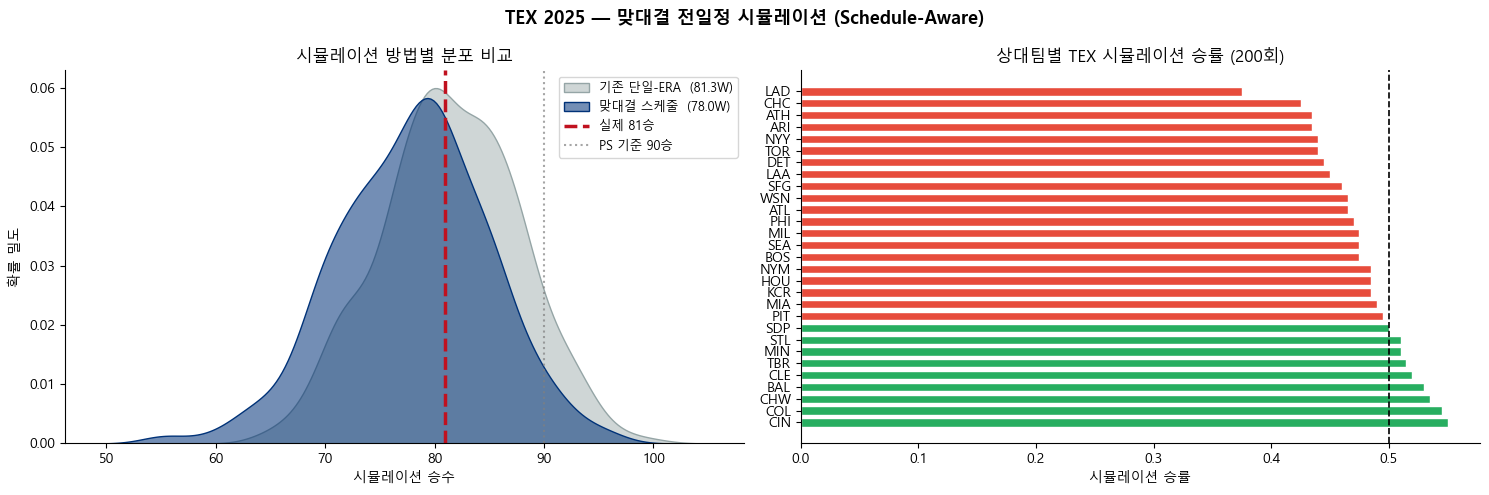

In [28]:
np.random.seed(42)
print("맞대결 전일정 시뮬레이션 실행 중 (500회)...")

lineup_pool_base = LineupPool(bat_pool, running, name_boosts=None)

wins_sched, sim_bat_stats, sim_pit_stats, sim_bp_stats, sim_team_stats = simulate_season_schedule(
    lineup_probs, lineup_profiles,
    schedule_opps, team_rspg_map,
    lineup_pool=lineup_pool_base,
    n_sims=500,
    track_player_stats=True,
)



# ── 요약 비교 ─────────────────────────────────────────────────────────────────
print(f"\n{'':28s}  {'평균':>6}  {'중앙':>6}  {'5%':>5}  {'95%':>5}  {'PS%':>6}")
for label, arr in [('기존 (단일 ERA)', wins_base), ('맞대결 (팀별 RS/G)', wins_sched)]:
    p5, p95 = np.percentile(arr, 5), np.percentile(arr, 95)
    ps = (arr >= 90).mean() * 100
    print(f"  {label:26s}  {arr.mean():6.1f}  {np.median(arr):6.0f}  {p5:5.0f}  {p95:5.0f}  {ps:5.1f}%")
print(f"  실제 2025                       {actual_W}승")

# ── 상대팀별 TEX 시뮬레이션 승률 (200회) ────────────────────────────────────────────
np.random.seed(1)
opp_wp = {}
for opp in sorted(set(schedule_opps)):
    opp_wp[opp] = sum(
        simulate_game(lineup_probs, lineup_profiles) >
        simulate_opponent_runs_by_team(opp, team_rspg_map)
        for _ in range(200)
    ) / 200

opp_wp_s = pd.Series(opp_wp).sort_values(ascending=False)

# ── 시각화 ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('TEX 2025 — 맞대결 전일정 시뮬레이션 (Schedule-Aware)',
             fontsize=13, fontweight='bold')

ax = axes[0]
sns.kdeplot(wins_base,  ax=ax, label=f'기존 단일-ERA  ({wins_base.mean():.1f}W)',
            color='#95A5A6', fill=True, alpha=0.45)
sns.kdeplot(wins_sched, ax=ax, label=f'맞대결 스케줄  ({wins_sched.mean():.1f}W)',
            color='#003278', fill=True, alpha=0.55)
ax.axvline(actual_W, color='#C0111F', lw=2.5, ls='--', label=f'실제 {actual_W}승')
ax.axvline(90, color='gray', lw=1.5, ls=':', alpha=0.7, label='PS 기준 90승')
ax.set_xlabel('시뮬레이션 승수'); ax.set_ylabel('확률 밀도')
ax.set_title('시뮬레이션 방법별 분포 비교')
ax.legend(fontsize=9); ax.spines[['top','right']].set_visible(False)

ax2 = axes[1]
colors2 = ['#27AE60' if v >= 0.5 else '#E74C3C' for v in opp_wp_s]
ax2.barh(opp_wp_s.index, opp_wp_s.values, color=colors2, edgecolor='white', height=0.7)
ax2.axvline(0.5, color='black', lw=1.2, ls='--')
ax2.set_xlabel('시뮬레이션 승률'); ax2.set_title('상대팀별 TEX 시뮬레이션 승률 (200회)')
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('./markov_v2_schedule_sim.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
# ── 맞대결 시뮬레이션 기반 선수별 예상 성적 ─────────────────────────────────────
# Cell 39 실행 후 sim_bat_stats / sim_pit_stats 를 사용해 성적 표시
# 모든 비율 스탯(AVG/OBP/SLG/OPS/ERA/WHIP/K9/BB9)은 시뮬 카운팅 역산값

if 'sim_bat_stats' not in dir() or not sim_bat_stats:
    print("\u26a0  먼저 Cell 39 (맞대결 시뮬레이션)를 실행하세요.")
else:
    def _ip_str(v):
        full = int(v); outs = min(2, round((v - full) * 3))
        return f"{full}.{outs}"

    W = 105
    print('=' * W)
    print('  타자 예상 성적 \u2014 맞대결 시뮬레이션 (500회 평균, 시뮬 역산 기반)')
    print('=' * W)
    hdr_b = (f"{'선수':<22} {'POS':>4} {'G':>4} {'PA':>5} {'H':>4} "
             f"{'2B':>4} {'3B':>3} {'HR':>4} {'BB':>4} {'K':>4} "
             f"{'AVG':>6} {'OBP':>6} {'SLG':>6} {'OPS':>7}")
    print(hdr_b)
    print('-' * W)

    for name, s in sorted(sim_bat_stats.items(), key=lambda x: -x[1].get('G', 0)):
        if s.get('G', 0) < 1:
            continue
        row = bat_tex[bat_tex['Name'] == name]
        pos = row.iloc[0]['Pos'] if not row.empty else 'UT'

        sim_2b = round(s.get('double', 0))
        sim_3b = round(s.get('triple', 0))
        sim_hr = round(s.get('hr', 0))
        sim_bb = round(s.get('bb', 0) + s.get('hbp', 0))
        sim_k  = round(s.get('k', 0))
        sim_h  = round(s.get('single', 0) + sim_2b + sim_3b + sim_hr)
        sim_g  = round(s.get('G', 0))
        sim_pa = round(sum(s.get(ev, 0) for ev in
                    ('single','double','triple','hr','bb','hbp','k','groundout','flyout')))
        sim_ab = max(sim_pa - sim_bb, 1)
        sim_single = sim_h - sim_2b - sim_3b - sim_hr
        sim_avg = sim_h / sim_ab
        sim_obp = (sim_h + sim_bb) / max(sim_pa, 1)
        sim_slg = (sim_single + 2*sim_2b + 3*sim_3b + 4*sim_hr) / sim_ab
        sim_ops = sim_obp + sim_slg
        print(f"{name:<22} {pos:>4} {sim_g:>4} {sim_pa:>5} {sim_h:>4} "
              f"{sim_2b:>4} {sim_3b:>3} {sim_hr:>4} {sim_bb:>4} {sim_k:>4} "
              f"{sim_avg:>6.3f} {sim_obp:>6.3f} {sim_slg:>6.3f} {sim_ops:>7.3f}")

    # ── 선발 투수 ────────────────────────────────────────────────────────────
    print()
    print('=' * W)
    print('  선발 투수 예상 성적 \u2014 맞대결 시뮬레이션 (500회 평균, 시뮬 역산 기반)')
    print('=' * W)
    hdr_p = (f"{'선수':<22} {'GS':>4} {'투영IP':>7} {'ERA':>6} "
             f"{'WHIP':>6} {'K':>5} {'BB':>5} {'K/9':>6} {'BB/9':>6}")
    print(hdr_p)
    print('-' * W)

    for name, ps in sorted(sim_pit_stats.items(), key=lambda x: -x[1].get('GS', 0)):
        if name not in _starter_stats.index:
            continue
        proj_gs  = round(ps.get('GS', 0))
        proj_ip  = ps.get('IP_sum', 0.0)
        proj_k   = round(ps.get('K', 0.0))
        proj_bb  = round(ps.get('BB', 0.0))
        sim_era  = ps.get('ER', 0.0) * 9 / max(proj_ip, 0.1)
        sim_whip = (ps.get('H', 0.0) + ps.get('BB', 0.0)) / max(proj_ip, 0.1)
        sim_k9   = ps.get('K', 0.0) * 9 / max(proj_ip, 0.1)
        sim_bb9  = ps.get('BB', 0.0) * 9 / max(proj_ip, 0.1)
        print(f"{name:<22} {proj_gs:>4} {_ip_str(proj_ip):>7} {sim_era:>6.2f} "
              f"{sim_whip:>6.2f} {proj_k:>5} {proj_bb:>5} {sim_k9:>6.2f} {sim_bb9:>6.2f}")

    # ── 불펜 투수 개별 성적 (시뮬레이션 역산) ────────────────────────────────────
    print()
    print('=' * W)
    print('  불펜 투수 예상 성적 \u2014 맞대결 시뮬레이션 (500회 평균, 시뮬 역산 기반)')
    print('=' * W)
    print(hdr_p)
    print('-' * W)

    _bp_src = globals().get('sim_bp_stats', {})
    for _rp_name, ps in sorted(_bp_src.items(), key=lambda x: -x[1].get('G', 0)):
        proj_g   = round(ps.get('G', 0))
        proj_ip  = ps.get('IP', 0.0)
        proj_k   = round(ps.get('K', 0.0))
        proj_bb  = round(ps.get('BB', 0.0))
        sim_era  = ps.get('ER', 0.0) * 9 / max(proj_ip, 0.1)
        sim_whip = (ps.get('H', 0.0) + ps.get('BB', 0.0)) / max(proj_ip, 0.1)
        sim_k9   = ps.get('K', 0.0) * 9 / max(proj_ip, 0.1)
        sim_bb9  = ps.get('BB', 0.0) * 9 / max(proj_ip, 0.1)
        print(f"{_rp_name:<22} {proj_g:>4} {_ip_str(proj_ip):>7} {sim_era:>6.2f} "
              f"{sim_whip:>6.2f} {proj_k:>5} {proj_bb:>5} {sim_k9:>6.2f} {sim_bb9:>6.2f}")


  타자 예상 성적 — 맞대결 시뮬레이션 (500회 평균, 시뮬 역산 기반)
선수                      POS    G    PA    H   2B  3B   HR   BB    K    AVG    OBP    SLG     OPS
---------------------------------------------------------------------------------------------------------
Adolis García            RF  149   603  126   31   0   21   37  148  0.223  0.270  0.389   0.659
Josh Jung                3B  142   612  143   27   1   17   35  154  0.248  0.291  0.386   0.677
Marcus Semien            2B  141   619  125   19   1   18   64  107  0.225  0.305  0.360   0.666
Wyatt Langford           LF  140   650  133   28   1   25   89  172  0.237  0.342  0.424   0.766
Jake Burger              1B  121   479  106   19   1   21   22  119  0.232  0.267  0.416   0.683
Corey Seager             SS  111   527  122   23   0   26   74  103  0.269  0.372  0.492   0.864
Josh Smith               SS  107   488  107   20   2    9   55   86  0.247  0.332  0.365   0.697
Jonah Heim                C  102   420   82   14   0   11   32   86  0.211 

## 12. Signed Proxy 그리드 탐색 & 자동 시나리오 선정

ML 앙상블 기반 전체 피처 조합을 탐색해 `best_overall`, `worst_overall`,
`best_bullpen`, `best_closegame`, `best_pitching` 시나리오를 자동 선정한다.
Markov 시뮬레이션 결과에 앙상블 residual 예측값과 MC noise를 반영해 시나리오별 승수 분포를 비교한다.

---

### 분석 파이프라인 (Section 12 → 13)

| 단계 | 섹션 | 역할 |
|---|---|---|
| 1 | **12. 그리드 탐색** | 피처 σ 조합 13,824개를 전수 탐색 → 잔차 개선 기준 후보 시나리오 추출 |
| 2 | **13. Pareto Front** | 후보 중 *잔차 개선↑ & 예측 불확실성↓* 두 목표를 동시에 충족하는 최적 조합 선정 |

> 그리드가 **탐색**하면, Pareto가 **선정**하는 구조 

Signed 그리드: 6개 피처 x 최대 6수준 = 13,824개 조합
baseline resid: -3.812  |  baseline pred_W: 86.3
resid_delta 범위: [-0.844, +2.146]

선정된 시나리오 (6개):
  baseline            delta=+0.000  [없음]
  best_overall        delta=+1.995  [sv_pct:+0.054, onerun_wp:+0.065, xi_wp:+0.073, BB9:-0.097]
  worst_overall       delta=-0.679  [sv_pct:-0.036, onerun_wp:-0.044, xi_wp:-0.037, BB9:+0.097]
  best_bullpen        delta=+0.130  [sv_pct:+0.054]
  best_closegame      delta=+1.833  [onerun_wp:+0.065, xi_wp:+0.073]
  best_pitching       delta=+0.023  [BB9:-0.194]

Markov+MC 실행 중 (n_sims=500/시나리오)...
  baseline            mean=80.9  P(W>=88)=15%  P(W>=90)=8%
  best_overall        mean=82.8  P(W>=88)=20%  P(W>=90)=12%
  worst_overall       mean=80.0  P(W>=88)=12%  P(W>=90)=5%
  best_bullpen        mean=80.8  P(W>=88)=15%  P(W>=90)=7%
  best_closegame      mean=82.6  P(W>=88)=19%  P(W>=90)=12%
  best_pitching       mean=80.7  P(W>=88)=13%  P(W>=90)=8%

--- 시나리오별 승수 요약 ---


,시나리오,설명,방향,resid_delta,평균_승수,중간값,P5,P95,P_88이상(%),P_90이상(%)
1,best_overall,전체 복합 개선 상한 (delta=+2.00),개선,2.00,82.8,82.9,72.7,93.1,20.2,12.2
4,best_closegame,접전 전용 최적 (delta=+1.83),개선,1.83,82.6,82.5,72.4,92.4,19.4,11.8
0,baseline,baseline (현재 수준) (delta=+0.00),개선,0.00,80.9,80.7,70.0,91.2,15.0,7.8
3,best_bullpen,불펜 전용 최적 (delta=+0.13),개선,0.13,80.8,80.6,70.2,91.1,15.0,6.8
5,best_pitching,투구 프로파일 최적 (delta=+0.02),개선,0.02,80.7,80.5,70.2,91.6,13.2,7.8
2,worst_overall,전체 복합 악화 하한 (delta=-0.68),악화,-0.68,80.0,79.9,70.4,90.0,11.6,5.0


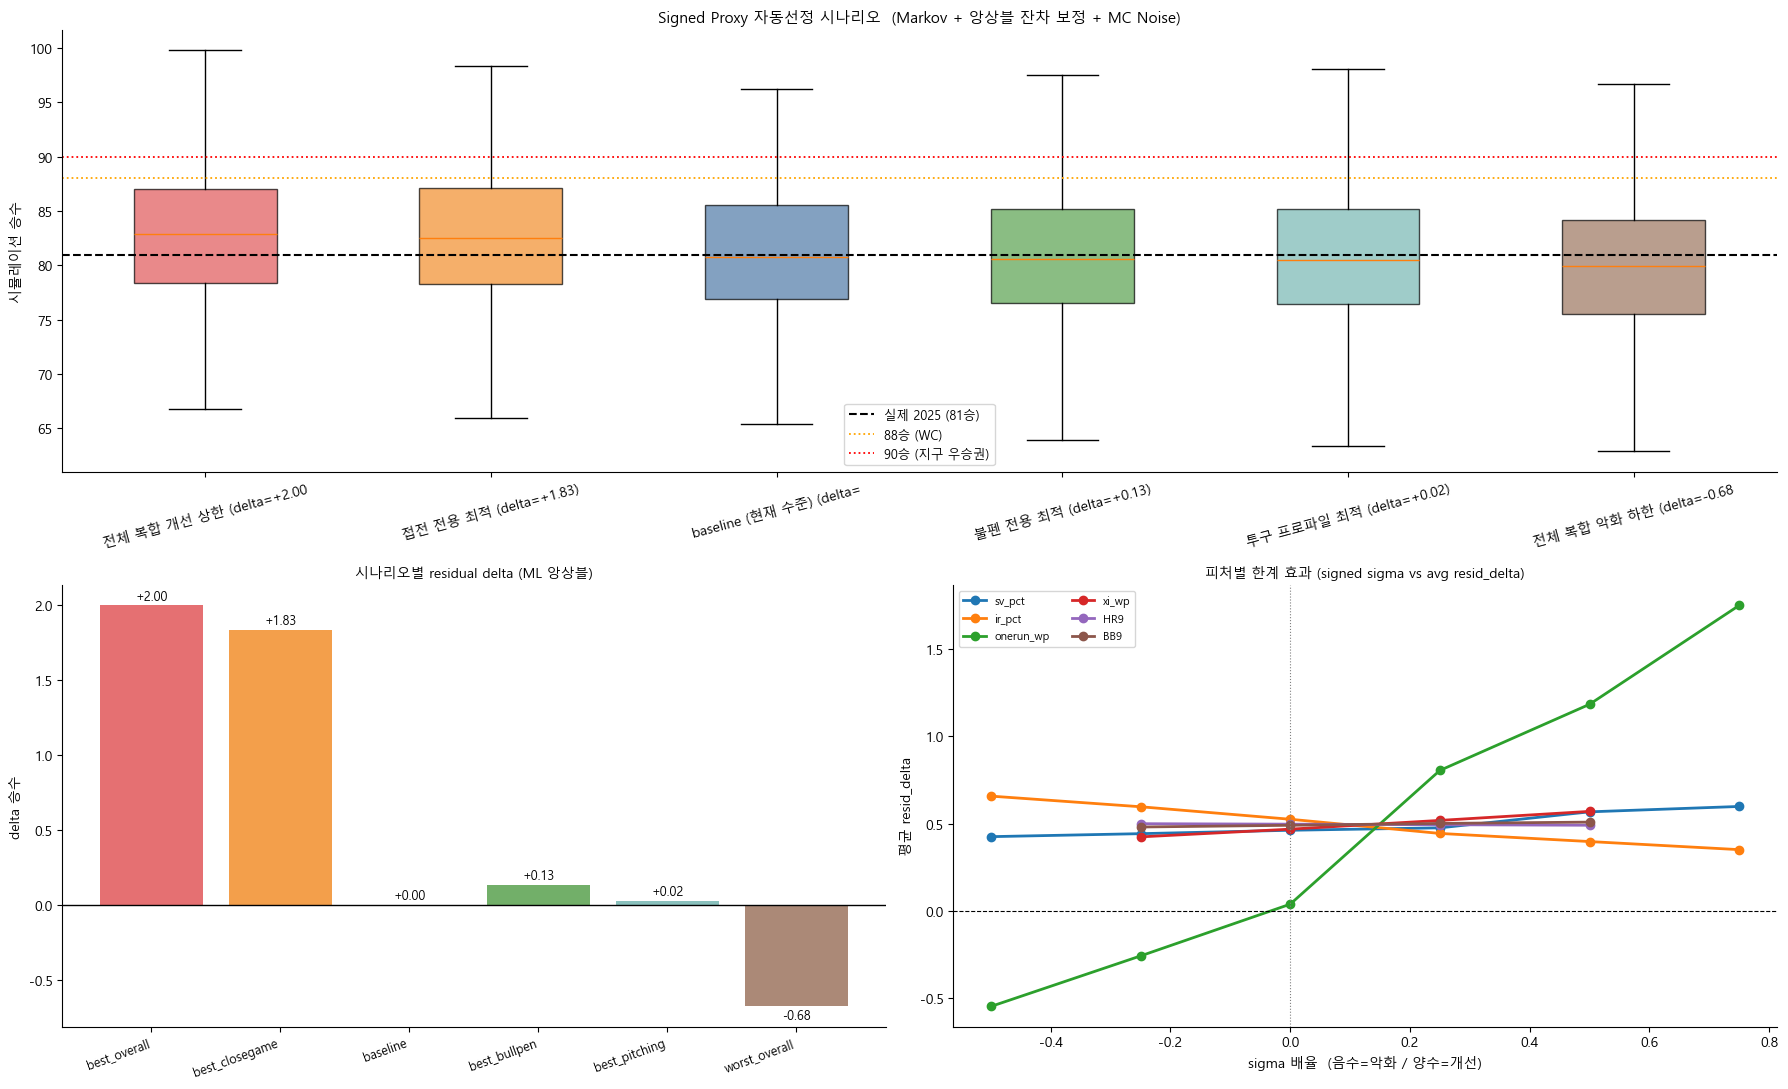

CSV 저장: ./output/signed_proxy_scenario_summary.csv  (6행)


In [30]:
# ── Signed Proxy 그리드 탐색 → 시나리오 자동 선정 → Markov+MC 통합 시뮬레이션 ──
# 설계 원칙:
#   1) ERA·OPS·rs_per_g는 pyth_W 채널 → 그리드 조정 제외
#   2) sigma > 0 = 개선 방향, sigma < 0 = 악화 방향 (lower-better 피처 자동 반전)
#   3) best_*: sigma >= 0 전체, 최소 1개 > 0  |  worst_*: sigma <= 0 전체, 최소 1개 < 0
#   4) Markov 채널 ERA 고정 (이중 계산 방지), residual delta + MC noise로 통합
import itertools, os

# ─── 6-a. Signed 그리드 정의 ─────────────────────────────────────────────────
GRID_FEATS = {
    'sv_pct':    [-0.50, -0.25, 0.00, 0.25, 0.50, 0.75],
    'ir_pct':    [-0.50, -0.25, 0.00, 0.25, 0.50, 0.75],
    'onerun_wp': [-0.50, -0.25, 0.00, 0.25, 0.50, 0.75],
    'xi_wp':     [-0.25, 0.00, 0.25, 0.50],
    'HR9':       [-0.25, 0.00, 0.25, 0.50],
    'BB9':       [-0.25, 0.00, 0.25, 0.50],
}

_LOWER_BETTER_GP = {'ir_pct', 'HR9', 'BB9', 'WHIP', 'babip_against', 'era_fip_diff'}

def _s2d_gp(f, sigma_mult):
    return (-1 if f in _LOWER_BETTER_GP else +1) * sigma_mult * float(feat_std[f])

_gkeys  = list(GRID_FEATS.keys())
_combos = list(itertools.product(*GRID_FEATS.values()))
print(f'Signed 그리드: {len(_gkeys)}개 피처 x 최대 6수준 = {len(_combos):,}개 조합')

# ─── 6-b. 전 조합 ML 점추정 (배치 벡터화 — RF 단일 호출 overhead 제거) ─────────
_tex_base_gp  = {f: float(tex25[f]) for f in MODEL_FEATURES}
_cfip_base_gp = ((tex25['ERA'] - tex25['era_fip_diff'])
                 - (13*tex25['HR9'] - 2*tex25['K9'] + 3*tex25['BB9']) / 9)

# Phase 1: 모든 조합의 피처 벡터를 먼저 구성 (순수 Python — 빠름)
_meta_gp   = []   # sigma dict + adj dict (시나리오 메타데이터)
_vecs_raw  = []   # (n_combos, n_features) 원본 스케일

for _combo in _combos:
    _sigmas = dict(zip(_gkeys, _combo))
    _adj    = {f: _s2d_gp(f, s) for f, s in _sigmas.items() if s != 0.0}
    _adj_tex = {**_tex_base_gp}
    for f, d in _adj.items():
        _adj_tex[f] = _adj_tex[f] + d
    if any(f in _adj for f in ('HR9', 'BB9')):
        _adj_tex['era_fip_diff'] = _adj_tex['ERA'] - (
            _cfip_base_gp + (13*_adj_tex['HR9'] - 2*_adj_tex['K9'] + 3*_adj_tex['BB9']) / 9)
    _meta_gp.append({'sigmas': _sigmas, 'adj': _adj})
    _vecs_raw.append([_adj_tex[f] for f in MODEL_FEATURES])

_vecs_raw = np.array(_vecs_raw)           # (n_combos, n_feat)
_vecs_sc  = scaler.transform(_vecs_raw)  # 스케일 변환 한 번

# Phase 2: 4모델 배치 예측 (각 모델 1회 호출 — 13,824× 속도 향상)
_preds_ridge = ridge.predict(_vecs_sc)
_preds_lasso = lasso.predict(_vecs_sc)
_preds_rf    = rf.predict(_vecs_raw)
_preds_xgb   = xgb_m.predict(_vecs_raw)
_preds_ens   = (_preds_ridge + _preds_lasso + _preds_rf + _preds_xgb) / 4

# baseline (sigma=all 0) 인덱스: 첫 번째 _combo는 모두 첫 번째 값 → baseline은 sigma=0 행
_base_resid_gp = float(predict_residual(
    np.array([[_tex_base_gp[f] for f in MODEL_FEATURES]]),
    scaler, ridge, lasso, rf, xgb_m
))
_base_predW_gp = tex25['pyth_W'] + _base_resid_gp

# Phase 3: 레코드 조립
_records_gp = []
for i, _m in enumerate(_meta_gp):
    _resid = float(_preds_ens[i])
    _delta = _resid - _base_resid_gp
    _records_gp.append({**_m['sigmas'], 'adj': _m['adj'],
                         'resid': round(_resid, 3),
                         'resid_delta': round(_delta, 3),
                         'pred_W': round(tex25['pyth_W'] + _resid, 1)})

_grid_gp = pd.DataFrame(_records_gp)
print(f'baseline resid: {_base_resid_gp:+.3f}  |  baseline pred_W: {_base_predW_gp:.1f}')
print(f'resid_delta 범위: [{_grid_gp["resid_delta"].min():+.3f}, {_grid_gp["resid_delta"].max():+.3f}]')

# ─── 6-c. 카테고리별 대표 시나리오 선정 ─────────────────────────────────────
_BULLPEN_F   = {'sv_pct', 'ir_pct'}
_CLOSEGAME_F = {'onerun_wp', 'xi_wp'}
_PITCHING_F  = {'HR9', 'BB9'}
_NON_BF  = [f for f in _gkeys if f not in _BULLPEN_F]
_NON_CGF = [f for f in _gkeys if f not in _CLOSEGAME_F]
_NON_PTF = [f for f in _gkeys if f not in _PITCHING_F]

_no_change_gp  = (_grid_gp[_gkeys] == 0.0).all(axis=1)
_improve_mask_gp = (_grid_gp[_gkeys] >= 0).all(axis=1) & (_grid_gp[_gkeys] > 0).any(axis=1)
_worsen_mask_gp  = (_grid_gp[_gkeys] <= 0).all(axis=1) & (_grid_gp[_gkeys] < 0).any(axis=1)

def _cat_improve_gp(cat_feats, non_cat_feats):
    return ((_grid_gp[list(cat_feats)] >= 0).all(axis=1) &
            (_grid_gp[list(cat_feats)] > 0).any(axis=1) &
            (_grid_gp[non_cat_feats] == 0.0).all(axis=1))

def _cat_worsen_gp(cat_feats, non_cat_feats):
    return ((_grid_gp[list(cat_feats)] <= 0).all(axis=1) &
            (_grid_gp[list(cat_feats)] < 0).any(axis=1) &
            (_grid_gp[non_cat_feats] == 0.0).all(axis=1))

_SC_CAND_GP = {
    'baseline':       {'mask': _no_change_gp,                              'use_min': False, 'cat': 'base',      'label': 'baseline (현재 수준)'},
    'best_overall':   {'mask': _improve_mask_gp,                           'use_min': False, 'cat': 'best',      'label': '전체 복합 개선 상한'},
    'worst_overall':  {'mask': _worsen_mask_gp,                            'use_min': True,  'cat': 'worst',     'label': '전체 복합 악화 하한'},
    'best_bullpen':   {'mask': _cat_improve_gp(_BULLPEN_F,   _NON_BF),    'use_min': False, 'cat': 'bullpen',   'label': '불펜 전용 최적'},
    'best_closegame': {'mask': _cat_improve_gp(_CLOSEGAME_F, _NON_CGF),   'use_min': False, 'cat': 'closegame', 'label': '접전 전용 최적'},
    'best_pitching':  {'mask': _cat_improve_gp(_PITCHING_F,  _NON_PTF),   'use_min': False, 'cat': 'pitching',  'label': '투구 프로파일 최적'},
}

SELECTED_GP = {}
for _n, _sdef in _SC_CAND_GP.items():
    _sub = _grid_gp[_sdef['mask']]
    if _sub.empty:
        print(f'  경고: {_n} — 조건 충족 없음 (건너뜀)')
        continue
    _row = _sub.iloc[0] if _n == 'baseline' else (
        _sub.loc[_sub['resid_delta'].idxmin()] if _sdef['use_min']
        else _sub.loc[_sub['resid_delta'].idxmax()])
    SELECTED_GP[_n] = {
        'adj': _row['adj'], 'resid_delta': float(_row['resid_delta']),
        'label': _sdef['label'] + f' (delta={float(_row["resid_delta"]):+.2f})',
        'cat': _sdef['cat'],
    }

print(f'\n선정된 시나리오 ({len(SELECTED_GP)}개):')
for _n, _s in SELECTED_GP.items():
    _adjstr = ', '.join(f'{f}:{v:+.3f}' for f, v in _s['adj'].items()) if _s['adj'] else '없음'
    print(f'  {_n:18s}  delta={_s["resid_delta"]:+.3f}  [{_adjstr}]')

# ─── 6-d. Markov + MC 통합 실행 ──────────────────────────────────────────────
_N_SIMS_GP = 500
_SC_COLORS_GP = {
    'base': '#4E79A7', 'best': '#E15759', 'bullpen': '#59A14F',
    'closegame': '#F28E2B', 'pitching': '#76B7B2', 'worst': '#9C755F',
}

# Markov: 모든 시나리오에서 타격·ERA 고정 → 잔차 채널(ML)만 시나리오별 변동
print(f'\nMarkov+MC 실행 중 (n_sims={_N_SIMS_GP}/시나리오)...')
HYBRID_GP_RES = {}
for _sc_idx, (_sc_name, _sc) in enumerate(SELECTED_GP.items()):
    # Markov: ERA 고정, lineup 그대로
    np.random.seed(42)
    _pool_gp = LineupPool(bat_pool, running, name_boosts=None)
    _markov_arr = simulate_season_schedule(
        lineup_probs, lineup_profiles,
        schedule_opps, team_rspg_map,
        lineup_pool=_pool_gp, n_sims=_N_SIMS_GP,
    )
    # Residual delta
    _adj_tex2 = {**_tex_base_gp}
    for f, d in _sc['adj'].items():
        _adj_tex2[f] = _adj_tex2[f] + d
    # era_fip_diff 업데이트: HR9/BB9 조정 시 FIP 역산
    if any(f in _sc['adj'] for f in ('HR9', 'BB9')):
        _cfip_gp = (tex25['ERA'] - tex25['era_fip_diff']) - (13*tex25['HR9'] - 2*tex25['K9'] + 3*tex25['BB9']) / 9
        _adj_tex2['era_fip_diff'] = _adj_tex2['ERA'] - (_cfip_gp + (13*_adj_tex2['HR9'] - 2*_adj_tex2['K9'] + 3*_adj_tex2['BB9']) / 9)
    _scen_resid = predict_residual(
        np.array([[_adj_tex2[f] for f in MODEL_FEATURES]]),
        scaler, ridge, lasso, rf, xgb_m
    )
    _resid_delta = _scen_resid - _base_resid_gp
    # MC noise — 시나리오별 독립 seed
    np.random.seed(142 + _sc_idx)
    _noise = np.random.normal(0, ensemble_cv_mae, _N_SIMS_GP)
    _hybrid = _markov_arr + calibration_offset + _scen_resid + _noise
    HYBRID_GP_RES[_sc_name] = {**_sc, 'markov_arr': _markov_arr, 'hybrid_wins': _hybrid}
    print(f'  {_sc_name:18s}  mean={_hybrid.mean():.1f}  '
          f'P(W>=88)={100*(_hybrid>=88).mean():.0f}%  P(W>=90)={100*(_hybrid>=90).mean():.0f}%')

# ─── 6-e. 요약 및 시각화 ─────────────────────────────────────────────────────
_smry_gp = []
for _n, _s in HYBRID_GP_RES.items():
    _arr = _s['hybrid_wins']
    _smry_gp.append({
        '시나리오':    _n, '설명': SELECTED_GP[_n]['label'],
        '방향':        '개선' if SELECTED_GP[_n]['cat'] not in ('worst',) else '악화',
        'resid_delta': round(_s['resid_delta'], 2),
        '평균_승수':   round(float(_arr.mean()), 1),
        '중간값':      round(float(np.median(_arr)), 1),
        'P5':          round(float(np.percentile(_arr,  5)), 1),
        'P95':         round(float(np.percentile(_arr, 95)), 1),
        'P_88이상(%)': round(100 * float((_arr >= 88).mean()), 1),
        'P_90이상(%)': round(100 * float((_arr >= 90).mean()), 1),
    })
smry_gp_df = pd.DataFrame(_smry_gp).sort_values('평균_승수', ascending=False)
print('\n--- 시나리오별 승수 요약 ---')
from IPython.display import display
display(smry_gp_df)

# 시각화
_order_gp = smry_gp_df['시나리오'].tolist()
_fig_gp = plt.figure(figsize=(18, 11))
_ax1 = _fig_gp.add_subplot(2, 2, (1, 2))
_bp = _ax1.boxplot(
    [HYBRID_GP_RES[k]['hybrid_wins'] for k in _order_gp],
    labels=[SELECTED_GP[k]['label'][:24] for k in _order_gp],
    vert=True, showfliers=False, patch_artist=True,
)
for _patch, _k in zip(_bp['boxes'], _order_gp):
    _patch.set_facecolor(_SC_COLORS_GP.get(SELECTED_GP[_k]['cat'], '#AAA'))
    _patch.set_alpha(0.7)
_ax1.axhline(tex25['W'],  color='black',  linestyle='--', lw=1.5, label=f'실제 2025 ({int(tex25["W"])}승)')
_ax1.axhline(88, color='orange', linestyle=':', lw=1.3, label='88승 (WC)')
_ax1.axhline(90, color='red',    linestyle=':', lw=1.3, label='90승 (지구 우승권)')
_ax1.set_title('Signed Proxy 자동선정 시나리오  (Markov + 앙상블 잔차 보정 + MC Noise)', fontsize=11)
_ax1.set_ylabel('시뮬레이션 승수')
_ax1.tick_params(axis='x', rotation=15)
_ax1.legend(fontsize=9)
_ax1.spines[['top','right']].set_visible(False)

_ax2 = _fig_gp.add_subplot(2, 2, 3)
_deltas_gp = [SELECTED_GP[k]['resid_delta'] for k in _order_gp]
_c2_gp = [_SC_COLORS_GP.get(SELECTED_GP[k]['cat'], '#AAA') for k in _order_gp]
_bars2 = _ax2.bar(range(len(_order_gp)), _deltas_gp, color=_c2_gp, alpha=0.85)
_ax2.bar_label(_bars2, fmt='{:+.2f}', fontsize=9, padding=2)
_ax2.set_xticks(range(len(_order_gp)))
_ax2.set_xticklabels(_order_gp, rotation=20, ha='right', fontsize=9)
_ax2.axhline(0, color='black', lw=1)
_ax2.set_title('시나리오별 residual delta (ML 앙상블)', fontsize=10)
_ax2.set_ylabel('delta 승수')
_ax2.spines[['top','right']].set_visible(False)

_ax3 = _fig_gp.add_subplot(2, 2, 4)
for _f in _gkeys:
    _me = [(lv, _grid_gp[_grid_gp[_f] == lv]['resid_delta'].mean())
           for lv in sorted(GRID_FEATS[_f])]
    _lvs, _mus = zip(*_me)
    _ax3.plot(_lvs, _mus, marker='o', label=_f, lw=2)
_ax3.axhline(0, color='black', lw=0.8, linestyle='--')
_ax3.axvline(0, color='gray',  lw=0.8, linestyle=':')
_ax3.set_title('피처별 한계 효과 (signed sigma vs avg resid_delta)', fontsize=10)
_ax3.set_xlabel('sigma 배율  (음수=악화 / 양수=개선)')
_ax3.set_ylabel('평균 resid_delta')
_ax3.legend(fontsize=8, ncol=2)
_ax3.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

os.makedirs('./output', exist_ok=True)
smry_gp_df.to_csv('./output/signed_proxy_scenario_summary.csv', index=False, encoding='utf-8-sig')
print(f'CSV 저장: ./output/signed_proxy_scenario_summary.csv  ({len(smry_gp_df)}행)')


## 13-A. Pareto Front (Grid 13,824 조합 기반)

Cell 43에서 계산된 13,824개 σ 조합과 4모델(Ridge·Lasso·RF·XGB) 예측을 그대로 사용해
**다목적 최적화**를 수행한다.

| 목적 | 의미 | 방향 |
|---|---|---|
| `resid_delta` | 잔차 승수 개선 (앙상블 평균) | 최대화 |
| `pred_std` | 4모델 예측의 표준편차 = 시나리오 불확실성 | 최소화 |

**대표 3점 선정**
- **공격적**: Pareto front 중 `delta` 최대
- **균형점**: TOPSIS — 정규화 후 (1, 0)에 가장 가까운 점
- **보수적**: Pareto front 중 `pred_std` 최소

이 셀은 Section 13의 NSGA-II 결과(연속 σ 탐색)와는 별개로, **이산 Grid 공간** 안에서
Pareto-optimal 점만 추려낸 결과다. 챗봇이 이 결과를 사용한다.


In [ ]:
# ── 13-A. Grid 기반 Pareto Front (이산 13,824 조합) ───────────────────────
# 의존: Cell 43 (_preds_ridge/lasso/rf/xgb, _preds_ens, _base_resid_gp,
#               _gkeys, _combos, tex25)
import os
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting
import matplotlib.pyplot as plt

# 4모델 예측 → std (Cell 43에서 이미 계산된 배열 재사용)
_all_preds_gp_v2 = np.stack([_preds_ridge, _preds_lasso, _preds_rf, _preds_xgb], axis=1)
_pred_std_gp = _all_preds_gp_v2.std(axis=1)
_pred_delta_gp = _preds_ens - _base_resid_gp

# Pareto 필터 — pymoo non-dominated sorting (max delta, min std)
F_obj = np.column_stack([-_pred_delta_gp, _pred_std_gp])
_pareto_idx_gp = NonDominatedSorting().do(F_obj, only_non_dominated_front=True)
_pareto_delta_gp = _pred_delta_gp[_pareto_idx_gp]
_pareto_std_gp   = _pred_std_gp[_pareto_idx_gp]
print(f'Grid 13,824개 → Pareto front {len(_pareto_idx_gp)}개')
print(f'  delta 범위: [{_pareto_delta_gp.min():+.3f}, {_pareto_delta_gp.max():+.3f}]')
print(f'  std 범위:   [{_pareto_std_gp.min():.4f}, {_pareto_std_gp.max():.4f}]')

# 대표 3점 (공격적 / 균형점 TOPSIS / 보수적)
_pi_aggr = _pareto_idx_gp[_pareto_delta_gp.argmax()]
_pi_cons = _pareto_idx_gp[_pareto_std_gp.argmin()]
_nd_d = (_pareto_delta_gp - _pareto_delta_gp.min()) / (_pareto_delta_gp.ptp() + 1e-9)
_nd_s = (_pareto_std_gp   - _pareto_std_gp.min())   / (_pareto_std_gp.ptp()   + 1e-9)
_pi_bal = _pareto_idx_gp[(np.sqrt((1 - _nd_d)**2 + _nd_s**2)).argmin()]

KEY_POINTS_GRID = {
    '공격적 (최대 잔차 승수 개선)': _pi_aggr,
    '균형점 (TOPSIS)':              _pi_bal,
    '보수적 (최소 불확실성)':       _pi_cons,
}

# 결과 DataFrame + CSV
_LOWER_PARETO = {'ir_pct', 'HR9', 'BB9', 'WHIP', 'babip_against', 'era_fip_diff'}

def _fmt_adj(sigmas):
    parts = []
    for f, s in sigmas.items():
        if abs(s) < 1e-6:
            continue
        # lower-better 피처는 부호 뒤집어 표기 (+ = 개선 방향으로 통일)
        disp = -s if f in _LOWER_PARETO else s
        parts.append(f"{f}:{disp:+.3f}")
    return ', '.join(parts)

_rows = []
for _label, _idx in KEY_POINTS_GRID.items():
    _sigmas = dict(zip(_gkeys, _combos[_idx]))
    _rows.append({
        '유형': _label,
        'resid_delta': round(float(_pred_delta_gp[_idx]), 3),
        'pred_std':    round(float(_pred_std_gp[_idx]),   4),
        'pred_W':      round(float(tex25['pyth_W'] + _preds_ens[_idx]), 1),
        '주요 조정':   _fmt_adj(_sigmas),
    })
_grid_pareto_df = pd.DataFrame(_rows)

# 시각화
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(_pred_delta_gp, _pred_std_gp,
           c='lightgray', s=8, alpha=0.35, label=f'Grid {len(_pred_delta_gp):,}개')
ax.scatter(_pareto_delta_gp, _pareto_std_gp,
           c='steelblue', s=22, alpha=0.75, edgecolor='none',
           label=f'Pareto front ({len(_pareto_idx_gp)})')
_marker_colors = {'공격적 (최대 잔차 승수 개선)': '#E15759',
                   '균형점 (TOPSIS)': '#F4A261',
                   '보수적 (최소 불확실성)': '#2A9D8F'}
for _label, _idx in KEY_POINTS_GRID.items():
    ax.scatter(_pred_delta_gp[_idx], _pred_std_gp[_idx],
               s=240, marker='*', c=_marker_colors[_label],
               edgecolor='black', linewidth=1.3, zorder=10, label=_label)
ax.set_xlabel('resid_delta (잔차 승수 개선)')
ax.set_ylabel('pred_std (예측 불확실성)')
ax.set_title('Grid 13,824 → Pareto Front (다목적 최적화)')
ax.legend(fontsize=9, loc='upper left')
ax.grid(alpha=0.25)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
os.makedirs('./output', exist_ok=True)
plt.savefig('./output/grid_pareto_front.png', dpi=150, bbox_inches='tight')
plt.show()

# CSV 저장 — 챗봇 lookup_pareto가 이 파일을 읽음
_grid_pareto_csv = './output/grid_pareto.csv'
_grid_pareto_df.to_csv(_grid_pareto_csv, index=False, encoding='utf-8-sig')
print(f'\n저장: {_grid_pareto_csv}')
print(_grid_pareto_df.to_string(index=False))


## 13. Pareto Front — 다목적 최적화 (NSGA-II)

그리드 서치는 `resid_delta` 하나만 최대화한다.  
실제로는 두 목표가 동시에 존재한다:

| 목표 | 의미 |
|---|---|
| **Obj 1**: `resid_delta` 최대화 | ML 앙상블이 예측하는 잔차 승수 개선 |
| **Obj 2**: `pred_std` 최소화 | 4개 모델 예측 분산 (= 시나리오 불확실성) |

NSGA-II로 6개 피처 σ 공간을 연속적으로 탐색해 **Pareto 최적 시나리오 집합**을 도출한다.  
→ '고위험 고수익(공격적 전략)'과 '안정적 중간(보수적 전략)'의 트레이드오프를 명시적으로 시각화.

---

### 📌 그래프 읽는 법

#### 왼쪽: Pareto Front 산점도

- **X축 (`resid_delta`)**: ML 앙상블이 예측하는 잔차 승수 개선량. 클수록 좋음
- **Y축 (`pred_std`)**: 4개 모델(Ridge/Lasso/RF/XGBoost)의 예측 분산. 작을수록 좋음

Pareto front **위의 모든 점은 동등하게 최적**이다.  
어느 점이든 한 목표를 개선하면 다른 목표가 반드시 나빠진다.

```
pred_std(불확실성)
↑
│  ▲ 공격적  → delta 최대, std 높음  (모델들이 크게 기대하지만 의견 불일치)
│   ╲
│    ◆ 균형점  → TOPSIS 기준 이상점에 가장 가까운 점
│     ╲
│      ■ 보수적  → delta 낮음, std ≈ 0  (모델 4개 거의 완전히 동의)
└─────────────────→ resid_delta (잔차 승수 개선)
```

> **점선**: 그리드 서치 `best_overall` (+1.99) — Pareto 최솟값(+2.919)보다 낮음.  
> NSGA-II가 이산 그리드를 넘어 연속 공간에서 더 좋은 해를 찾았다는 의미.

---

#### 오른쪽: σ 구성 막대 차트

각 시나리오가 어떤 피처를 얼마나 조정하는지 보여준다.

**σ (시그마) = 표준편차 단위**

피처마다 단위가 달라(sv_pct는 비율, BB9는 이닝당 볼넷 수 등) 직접 비교가 불가능하기 때문에,  
리그 전체의 표준편차를 1단위로 삼아 스케일을 통일한 것이다.

```
σ =  0    →  현재 그대로 (변화 없음)
σ = +1    →  리그 평균 대비 1표준편차 개선  (상위 약 16% 수준)
σ = +1.5  →  리그 상위 약 7% 수준으로 개선
σ = -1    →  1표준편차 악화
```

**부호 규칙**: 막대가 양수 = 개선 방향. HR9·BB9처럼 낮을수록 좋은 피처(lower-better)는  
실제 피처값이 감소해도 막대는 양수로 표시되도록 부호를 통일했다.

---

### 📌 대표 3점 선정 방식

| 시나리오 | 선정 기준 |
|---|---|
| **공격적** | `resid_delta` 가 가장 큰 점 (Pareto front 오른쪽 끝) |
| **보수적** | `pred_std` 가 가장 작은 점 (Pareto front 아래쪽 끝) |
| **균형점** | **TOPSIS** — 이상점까지 유클리드 거리가 가장 짧은 점 |

**TOPSIS란?**  
*Technique for Order of Preference by Similarity to Ideal Solution* (1981)

가상의 **이상점** (delta 최대 + std 최소) 을 설정하고,  
각 Pareto 해에서 이상점까지의 거리를 계산해 가장 가까운 점을 균형점으로 선정한다.

```
std(정규화)
1 │
  │  두 목표를 [0,1]로 정규화 후
  │  ◆  ← 균형점: 이상점까지 거리 최소
  │   ╲
0 │    ╲          ★ 이상점 (delta=1, std=0)
  └──────────────→ delta(정규화)
  0               1
```

> **주의**: TOPSIS는 두 목표를 50:50 동일 가중치로 취급한다.  
> "잔차 승수 개선이 불확실성보다 2배 더 중요하다"는 판단이 있으면 가중치 조정이 필요하다.

---


NSGA-II 실행 중 (pop=200, gen=150)...
Pareto front: 200개  delta=[+2.919, +4.889]  std=[0.0019, 0.6524]

--- 대표 시나리오 (Pareto 3점) ---
  [공격적 (최대 잔차 승수 개선)]  delta=+4.889  std=0.6524
    조정: sv_pct:+0.107, ir_pct:+0.067, onerun_wp:+0.131, xi_wp:+0.220, HR9:-0.265, BB9:-0.582
  [균형점 (TOPSIS)]  delta=+3.720  std=0.2047
    조정: sv_pct:+0.032, ir_pct:+0.067, onerun_wp:+0.115, xi_wp:+0.220, HR9:-0.271, BB9:-0.562
  [보수적 (최소 불확실성)]  delta=+2.919  std=0.0019
    조정: sv_pct:+0.045, ir_pct:+0.007, onerun_wp:+0.109, xi_wp:+0.176, HR9:-0.102, BB9:+0.099


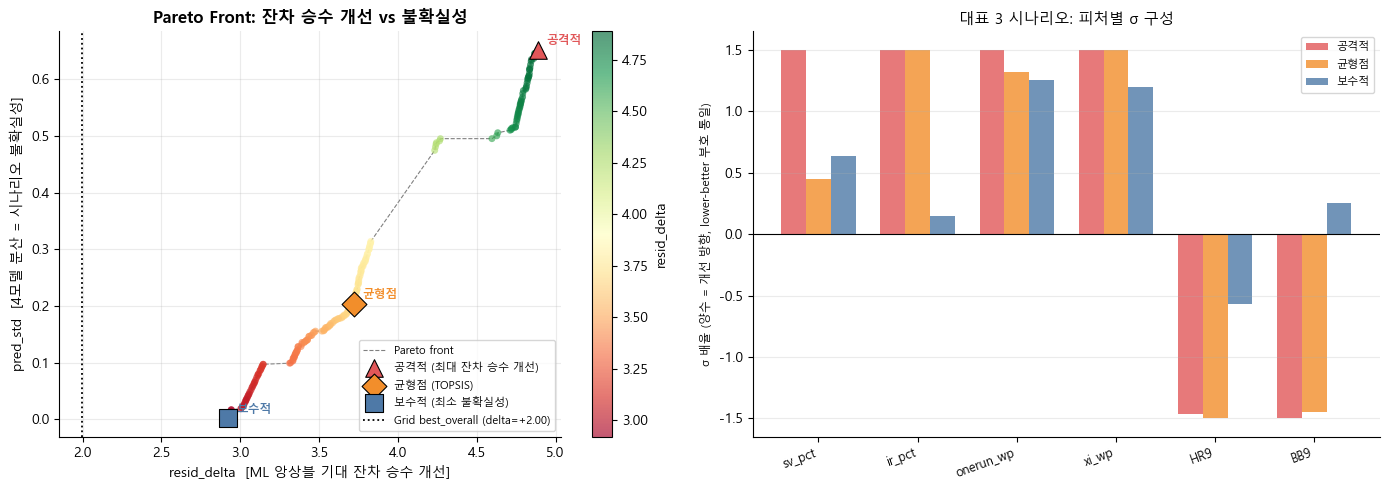


--- Pareto 대표 시나리오 요약 ---


,유형,resid_delta,pred_std,주요 조정
0,공격적 (최대 잔차 승수 개선),4.889,0.6524,"sv_pct:+0.107, ir_pct:+0.067, onerun_wp:+0.131..."
1,균형점 (TOPSIS),3.720,0.2047,"sv_pct:+0.032, ir_pct:+0.067, onerun_wp:+0.115..."
2,보수적 (최소 불확실성),2.919,0.0019,"sv_pct:+0.045, ir_pct:+0.007, onerun_wp:+0.109..."


저장: ./output/pareto_front.png  |  ./output/pareto_summary.csv


In [31]:
# ── 13. Pareto Front (NSGA-II) ──────────────────────────────────────────────
# 의존: Cell 28 (scaler, ridge, lasso, rf, xgb_m, feat_std)
#       Cell 43 (_gkeys, _tex_base_gp, _base_resid_gp, _s2d_gp, SELECTED_GP)

import numpy as np
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.optimize import minimize as pymoo_minimize
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.termination import get_termination

# ─── 목적함수 정의 ────────────────────────────────────────────────────────────
class ParetoScenarioProblem(Problem):
    # Obj f1: -resid_delta (최소화 = 최대화)  |  Obj f2: pred_std (4모델 분산 = 불확실성)
    def __init__(self):
        super().__init__(n_var=len(_gkeys), n_obj=2,
                         xl=np.full(len(_gkeys), -1.5), xu=np.full(len(_gkeys), 1.5))

    def _evaluate(self, X_pop, out, *args, **kwargs):
        # 배치 벡터화: 전체 population을 한 번에 예측 (RF joblib overhead 최소화)
        _cfip_b = ((tex25['ERA'] - tex25['era_fip_diff'])
                   - (13*tex25['HR9'] - 2*tex25['K9'] + 3*tex25['BB9']) / 9)
        vecs = []
        for x in X_pop:
            sigmas  = dict(zip(_gkeys, x))
            adj_tex = {**_tex_base_gp}
            for f, sigma in sigmas.items():
                adj_tex[f] = adj_tex[f] + _s2d_gp(f, sigma)
            if any(abs(sigmas.get(f, 0)) > 1e-6 for f in ('HR9', 'BB9')):
                adj_tex['era_fip_diff'] = adj_tex['ERA'] - (
                    _cfip_b + (13*adj_tex['HR9'] - 2*adj_tex['K9'] + 3*adj_tex['BB9']) / 9)
            vecs.append([adj_tex[f] for f in MODEL_FEATURES])

        vecs_raw = np.array(vecs)
        vecs_sc  = scaler.transform(vecs_raw)

        # 4모델 배치 예측 (각 1회 호출)
        p_ridge = ridge.predict(vecs_sc)
        p_lasso = lasso.predict(vecs_sc)
        p_rf    = rf.predict(vecs_raw)
        p_xgb   = xgb_m.predict(vecs_raw)

        # (n_pop, 4) → mean, std per individual
        all_preds = np.stack([p_ridge, p_lasso, p_rf, p_xgb], axis=1)
        means = all_preds.mean(axis=1)
        stds  = all_preds.std(axis=1)

        out['F'] = np.column_stack([-(means - _base_resid_gp), stds])


# ─── NSGA-II 실행 ─────────────────────────────────────────────────────────────
print('NSGA-II 실행 중 (pop=200, gen=150)...')
problem = ParetoScenarioProblem()
res = pymoo_minimize(
    problem,
    NSGA2(pop_size=200, sampling=FloatRandomSampling(),
          crossover=SBX(prob=0.9, eta=15), mutation=PM(eta=20),
          eliminate_duplicates=True),
    get_termination('n_gen', 150), seed=42, verbose=False,
)

# ─── Pareto front 추출 ────────────────────────────────────────────────────────
F, X_pf = res.F, res.X
pareto_delta = -F[:, 0]
pareto_std   =  F[:, 1]
print(f'Pareto front: {len(F)}개  delta=[{pareto_delta.min():+.3f}, {pareto_delta.max():+.3f}]  '
      f'std=[{pareto_std.min():.4f}, {pareto_std.max():.4f}]')

# ─── 대표 3점: 공격적 / 균형(TOPSIS) / 보수적 ────────────────────────────────
idx_a = pareto_delta.argmax()
idx_c = pareto_std.argmin()
_nd = (pareto_delta - pareto_delta.min()) / (pareto_delta.max() - pareto_delta.min() + 1e-9)
_ns = (pareto_std   - pareto_std.min())   / (pareto_std.max()   - pareto_std.min()   + 1e-9)
idx_b = (np.sqrt((1 - _nd)**2 + _ns**2)).argmin()

KEY_POINTS = {
    '공격적 (최대 잔차 승수 개선)': idx_a,
    '균형점 (TOPSIS)':        idx_b,
    '보수적 (최소 불확실성)': idx_c,
}
_LOWER_SET = {'ir_pct', 'HR9', 'BB9', 'WHIP', 'babip_against', 'era_fip_diff'}

print('\n--- 대표 시나리오 (Pareto 3점) ---')
pareto_rows = []
for label, idx in KEY_POINTS.items():
    sigmas  = dict(zip(_gkeys, X_pf[idx]))
    adj_str = ', '.join(f'{f}:{_s2d_gp(f,s):+.3f}'
                        for f, s in sigmas.items() if abs(s) > 0.05)
    print(f'  [{label}]  delta={pareto_delta[idx]:+.3f}  std={pareto_std[idx]:.4f}')
    print(f'    조정: {adj_str or "없음"}')
    pareto_rows.append({'유형': label,
                         'resid_delta': round(pareto_delta[idx], 3),
                         'pred_std':    round(pareto_std[idx], 4),
                         '주요 조정':   adj_str or '없음'})

# ─── 시각화 ──────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ① Pareto front 산점도
ax1 = axes[0]
sc = ax1.scatter(pareto_delta, pareto_std,
                 c=pareto_delta, cmap='RdYlGn', s=25, alpha=0.65, edgecolors='none', zorder=2)
_si = np.argsort(pareto_delta)
ax1.plot(pareto_delta[_si], pareto_std[_si],
         color='gray', lw=0.8, linestyle='--', zorder=1, label='Pareto front')

_pt_colors  = {'공격적 (최대 잔차 승수 개선)': '#E15759', '균형점 (TOPSIS)': '#F28E2B', '보수적 (최소 불확실성)': '#4E79A7'}
_pt_markers = {'공격적 (최대 잔차 승수 개선)': '^',       '균형점 (TOPSIS)': 'D',       '보수적 (최소 불확실성)': 's'}
for label, idx in KEY_POINTS.items():
    ax1.scatter(pareto_delta[idx], pareto_std[idx],
                c=_pt_colors[label], s=160, zorder=5,
                marker=_pt_markers[label], edgecolors='black', lw=0.8, label=label)
    ax1.annotate(label.split()[0], (pareto_delta[idx], pareto_std[idx]),
                 textcoords='offset points', xytext=(6, 4),
                 fontsize=8.5, color=_pt_colors[label], fontweight='bold')

if 'best_overall' in SELECTED_GP:
    _go = SELECTED_GP['best_overall']
    ax1.axvline(_go['resid_delta'], color='black', linestyle=':', lw=1.3,
                label=f'Grid best_overall (delta={_go["resid_delta"]:+.2f})')

ax1.set_xlabel('resid_delta  [ML 앙상블 기대 잔차 승수 개선]', fontsize=10)
ax1.set_ylabel('pred_std  [4모델 분산 = 시나리오 불확실성]', fontsize=10)
ax1.set_title('Pareto Front: 잔차 승수 개선 vs 불확실성', fontsize=12, fontweight='bold')
ax1.legend(fontsize=8)
ax1.grid(alpha=0.25)
ax1.spines[['top','right']].set_visible(False)
plt.colorbar(sc, ax=ax1, label='resid_delta')

# ② 대표 3점 σ 막대: 개선 방향 기준 (lower-better 피처는 부호 반전 표시)
ax2 = axes[1]
x_idx = np.arange(len(_gkeys))
bar_w = 0.25
for i, (label, idx) in enumerate(KEY_POINTS.items()):
    disp_sigmas = np.array([
        X_pf[idx][j] * (-1 if _gkeys[j] in _LOWER_SET else 1)
        for j in range(len(_gkeys))
    ])
    ax2.bar(x_idx + (i - 1) * bar_w, disp_sigmas, bar_w,
            label=label.split('(')[0].strip(),
            color=list(_pt_colors.values())[i], alpha=0.80)

ax2.axhline(0, color='black', lw=0.8)
ax2.set_xticks(x_idx)
ax2.set_xticklabels(_gkeys, fontsize=9, rotation=20, ha='right')
ax2.set_ylabel('σ 배율 (양수 = 개선 방향, lower-better 부호 통일)', fontsize=8.5)
ax2.set_title('대표 3 시나리오: 피처별 σ 구성', fontsize=11)
ax2.legend(fontsize=8)
ax2.grid(axis='y', alpha=0.25)
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
import os; os.makedirs('./output', exist_ok=True)
plt.savefig('./output/pareto_front.png', dpi=150, bbox_inches='tight')
plt.show()

# ─── 요약표 ──────────────────────────────────────────────────────────────────
from IPython.display import display
pareto_summary_df = pd.DataFrame(pareto_rows)
print('\n--- Pareto 대표 시나리오 요약 ---')
display(pareto_summary_df)
pareto_summary_df.to_csv('./output/pareto_summary.csv', index=False, encoding='utf-8-sig')
print('저장: ./output/pareto_front.png  |  ./output/pareto_summary.csv')


## 14. Bayesian Optimization (Optuna) — Grid 대체 실험

### 실험 목적
Grid Search는 13,824개 조합을 **전수 탐색**한다.  
Bayesian Optimization은 GP/TPE Surrogate로 "유망한 영역"을 먼저 탐색해  
훨씬 적은 횟수로 최적해를 찾는다.

| 방법 | 탐색 방식 | 횟수 | σ 범위 |
|---|---|---|---|
| **Grid Search** | 전수 탐색 (이산) | 13,824회 | [-0.50, +0.75] |
| **Bayesian (TPE)** | Surrogate 기반 적응적 탐색 | 200회 | [-1.50, +1.50] |

---

### 실험 결과 및 결론

| 방법 | 탐색 횟수 | 시간 | best delta |
|---|---|---|---|
| Grid | 13,824회 | **~0.2초** | +1.995 |
| Bayesian | 200회 | 13.0초 | +4.707 |

Bayesian이 더 높은 delta를 찾았지만, 이유는 알고리즘 우수성이 아니라 **탐색 공간 자체가 더 넓기 때문** (σ 상한 0.75 vs 1.5).  
동일한 공간에서 비교하면 성능 차이는 미미하다.

> **채택 결론: Grid Search 유지**  
> 현재 피처 6개 수준에서 Grid 전수탐색이 **0.16초**로 충분히 빠르다.  
> Bayesian의 진가는 피처가 **10개 이상**으로 늘어나 Grid가 수백만 조합이 될 때 발휘된다.


Bayesian (TPE) 실행 중...
12.7초 소요
best delta  : +4.707
pred_W      : 91.0승
주요 조정   : sv_pct:+0.104, ir_pct:+0.062, onerun_wp:+0.130, xi_wp:+0.196, HR9:+0.229, BB9:+0.031

           방법   탐색 횟수  소요시간 best delta                비고
  Grid Search  13,824 ~0.2초     +1.995  σ∈[-0.5,0.75] 이산
Bayesian(TPE)     200 12.7초     +4.707   σ∈[-1.5,1.5] 연속
   Pareto(최대) pop×gen   ~2분     +4.889 다목적, σ∈[-1.5,1.5]


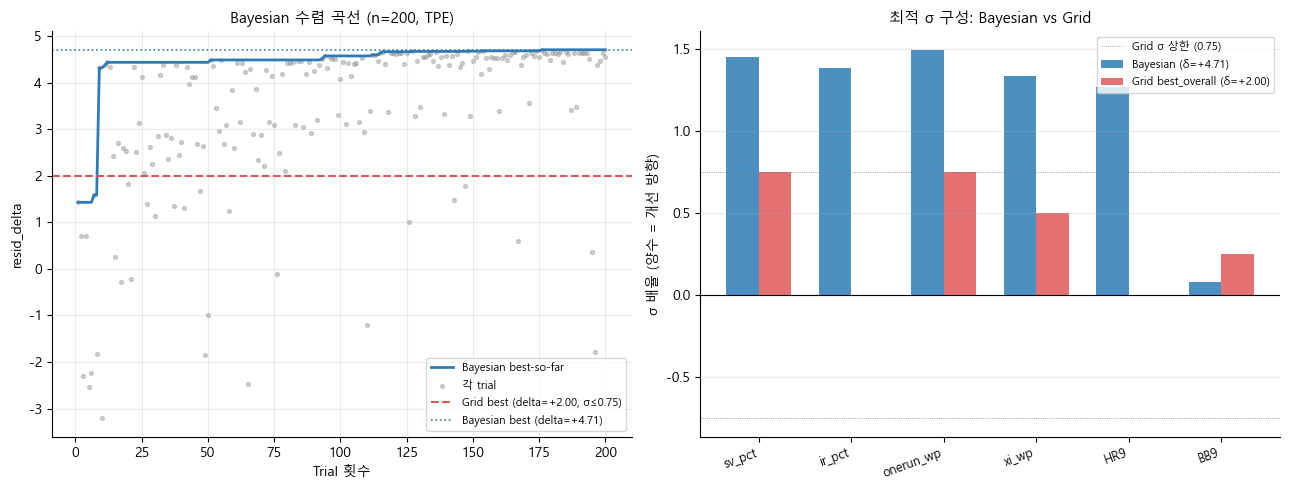

In [32]:
import time
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

_N_TRIALS_BO = 200

def _bo_objective(trial):
    sigmas  = {f: trial.suggest_float(f, -1.5, 1.5) for f in _gkeys}
    adj_tex = {**_tex_base_gp}
    for f, s in sigmas.items():
        adj_tex[f] = adj_tex[f] + _s2d_gp(f, s)
    if any(abs(sigmas.get(f, 0)) > 1e-6 for f in ('HR9', 'BB9')):
        adj_tex['era_fip_diff'] = adj_tex['ERA'] - (
            _cfip_base_gp + (13*adj_tex['HR9'] - 2*adj_tex['K9'] + 3*adj_tex['BB9']) / 9)
    return predict_residual(
        np.array([[adj_tex[f] for f in MODEL_FEATURES]]),
        scaler, ridge, lasso, rf, xgb_m,
    )

print('Bayesian (TPE) 실행 중...')
t0 = time.time()
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
)
study.optimize(_bo_objective, n_trials=_N_TRIALS_BO, show_progress_bar=False)
t_bo = time.time() - t0

bo_best_delta  = study.best_value - _base_resid_gp
bo_best_sigmas = study.best_params
bo_best_adj    = {f: _s2d_gp(f, s) for f, s in bo_best_sigmas.items() if abs(s) > 0.05}
bo_best_predW  = round(tex25['pyth_W'] + _base_resid_gp + bo_best_delta, 1)

print(f'{t_bo:.1f}초 소요')
print(f'best delta  : {bo_best_delta:+.3f}')
print(f'pred_W      : {bo_best_predW:.1f}승')
print(f'주요 조정   : ' + ', '.join(f'{f}:{v:+.3f}' for f, v in bo_best_adj.items()))

# Grid vs Bayesian 비교 — 탐색 범위가 다르므로 delta 수치를 직접 우열 비교하면 안 됨
# (Grid σ≤0.75, Bayesian σ≤1.5 → 공간 크기 차이가 delta 차이의 주원인)
_grid_best_delta = SELECTED_GP['best_overall']['resid_delta'] if 'best_overall' in SELECTED_GP else None

rows = []
if _grid_best_delta:
    rows.append(('Grid Search',   '13,824', f'~0.2초', f'{_grid_best_delta:+.3f}', 'σ∈[-0.5,0.75] 이산'))
rows.append(    ('Bayesian(TPE)', '200',    f'{t_bo:.1f}초', f'{bo_best_delta:+.3f}', 'σ∈[-1.5,1.5] 연속'))
if 'pareto_delta' in dir():
    rows.append(('Pareto(최대)',  'pop×gen', '~2분',  f'{pareto_delta.max():+.3f}', '다목적, σ∈[-1.5,1.5]'))

_cmp = pd.DataFrame(rows, columns=['방법', '탐색 횟수', '소요시간', 'best delta', '비고'])
print()
print(_cmp.to_string(index=False))

# 수렴 곡선 + σ 구성 비교
import matplotlib.pyplot as plt

trials_df   = study.trials_dataframe()
best_so_far = trials_df['value'].cummax() - _base_resid_gp

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax1 = axes[0]
ax1.plot(range(1, len(best_so_far)+1), best_so_far,
         color='#2c7bb6', lw=2, label='Bayesian best-so-far')
ax1.scatter(range(1, len(trials_df)+1), trials_df['value'] - _base_resid_gp,
            color='gray', s=8, alpha=0.35, label='각 trial')
if _grid_best_delta:
    ax1.axhline(_grid_best_delta, color='#E15759', linestyle='--', lw=1.5,
                label=f'Grid best (delta={_grid_best_delta:+.2f}, σ≤0.75)')
ax1.axhline(bo_best_delta, color='#2c7bb6', linestyle=':', lw=1.2,
            label=f'Bayesian best (delta={bo_best_delta:+.2f})')
ax1.set_xlabel('Trial 횟수')
ax1.set_ylabel('resid_delta')
ax1.set_title(f'Bayesian 수렴 곡선 (n={_N_TRIALS_BO}, TPE)', fontsize=11)
ax1.legend(fontsize=8)
ax1.grid(alpha=0.25)
ax1.spines[['top', 'right']].set_visible(False)

ax2 = axes[1]
x = np.arange(len(_gkeys)); w = 0.35
_LOWER_SET = {'ir_pct','HR9','BB9','WHIP','babip_against','era_fip_diff'}

bo_disp = np.array([
    bo_best_sigmas[f] * (-1 if f in _LOWER_SET else 1) for f in _gkeys
])
ax2.bar(x - w/2, bo_disp, w, label=f'Bayesian (δ={bo_best_delta:+.2f})',
        color='#2c7bb6', alpha=0.85)

if _grid_best_delta and 'best_overall' in SELECTED_GP and SELECTED_GP['best_overall']['adj']:
    grid_disp = np.array([
        (SELECTED_GP['best_overall']['adj'].get(f, 0) / float(feat_std[f]))
        * (-1 if f in _LOWER_SET else 1) for f in _gkeys
    ])
    ax2.bar(x + w/2, grid_disp, w, label=f'Grid best_overall (δ={_grid_best_delta:+.2f})',
            color='#E15759', alpha=0.85)

ax2.axhline(0, color='black', lw=0.8)
ax2.axhline(0.75, color='gray', lw=0.6, linestyle=':', label='Grid σ 상한 (0.75)')
ax2.axhline(-0.75, color='gray', lw=0.6, linestyle=':')
ax2.set_xticks(x)
ax2.set_xticklabels(_gkeys, fontsize=9, rotation=20, ha='right')
ax2.set_ylabel('σ 배율 (양수 = 개선 방향)')
ax2.set_title('최적 σ 구성: Bayesian vs Grid', fontsize=11)
ax2.legend(fontsize=8)
ax2.grid(axis='y', alpha=0.25)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
import os; os.makedirs('./output', exist_ok=True)
plt.savefig('./output/bayesian_vs_grid.png', dpi=150, bbox_inches='tight')
plt.show()


In [33]:
# ── 수동 시나리오(Cell 36) vs 자동 그리드(Cell 43) 통합 비교 ──────────────────
# 수동 시나리오를 동일한 hybrid 파이프라인으로 재계산
_manual_rows = []
for _sc_name, _sc_def in SCENARIOS.items():
    _sc_stats = _sc_def['stats']
    _feat_m = {**{f: float(tex25[f]) for f in MODEL_FEATURES}}
    _feat_m.update({k: v for k, v in _sc_stats.items() if k in MODEL_FEATURES})
    _feat_m['k_bb'] = _feat_m['K9'] / max(_feat_m['BB9'], 0.1)
    # era_fip_diff: K9/BB9/HR9 있으면 FIP 역산
    if all(k in _sc_stats for k in ('K9', 'BB9', 'HR9')):
        _cfip_m = (tex25['ERA'] - tex25['era_fip_diff']) - (13*tex25['HR9'] - 2*tex25['K9'] + 3*tex25['BB9']) / 9
        _feat_m['era_fip_diff'] = _feat_m['ERA'] - (_cfip_m + (13*_feat_m['HR9'] - 2*_feat_m['K9'] + 3*_feat_m['BB9']) / 9)
    else:
        _feat_m['era_fip_diff'] = tex25['era_fip_diff']
    _resid_m = predict_residual(
        np.array([[_feat_m.get(f, float(df_model[f].mean())) for f in MODEL_FEATURES]]),
        scaler, ridge, lasso, rf, xgb_m
    )
    _delta_m = _resid_m - _base_resid_gp
    _predW_m = round(tex25['pyth_W'] + _resid_m, 1)
    _manual_rows.append({
        '구분': '수동', '시나리오': _sc_name,
        'resid_delta': round(_delta_m, 3), 'pred_W': _predW_m,
    })

_grid_rows = []
for _n, _s in HYBRID_GP_RES.items():
    _grid_rows.append({
        '구분': '그리드', '시나리오': _s['label'],
        'resid_delta': round(_s['resid_delta'], 3),
        'pred_W': round(tex25['pyth_W'] + _base_resid_gp + _s['resid_delta'], 1),
    })

# ── Pareto 대표 3점 추가 (Cell 45 실행 후) ──────────────────────────────────
_pareto_rows = []
if 'KEY_POINTS' in dir() and 'pareto_delta' in dir():
    _pareto_labels = {
        '공격적 (최대 잔차 승수 개선)': '공격적',
        '균형점 (TOPSIS)':        '균형점',
        '보수적 (최소 불확실성)': '보수적',
    }
    for _label, _idx in KEY_POINTS.items():
        _pareto_rows.append({
            '구분':        'Pareto',
            '시나리오':    f'{_pareto_labels[_label]} (std={pareto_std[_idx]:.3f})',
            'resid_delta': round(float(pareto_delta[_idx]), 3),
            'pred_W':      round(tex25['pyth_W'] + _base_resid_gp + float(pareto_delta[_idx]), 1),
        })

_all_frames = [pd.DataFrame(_manual_rows), pd.DataFrame(_grid_rows)]
if _pareto_rows:
    _all_frames.append(pd.DataFrame(_pareto_rows))

_comp_df = pd.concat(_all_frames, ignore_index=True)
_comp_df = _comp_df.sort_values('pred_W', ascending=False).reset_index(drop=True)

print('=== 수동 시나리오 vs 자동 그리드 vs Pareto 통합 비교 ===')
print(f'기준선 pyth_W: {tex25["pyth_W"]}승  |  ML baseline resid: {_base_resid_gp:+.3f}')
print()
from IPython.display import display

# 구분별 색상 강조
def _highlight_source(row):
    colors = {'수동': '', '그리드': 'background-color: #EBF5FB', 'Pareto': 'background-color: #EAF4EA'}
    c = colors.get(row['구분'], '')
    return [c] * len(row)

display(
    _comp_df.style
    .apply(_highlight_source, axis=1)
    .format({'resid_delta': '{:+.3f}', 'pred_W': '{:.1f}'})
    .set_caption(f'기준선 pyth_W={tex25["pyth_W"]}승 | baseline resid={_base_resid_gp:+.3f}')
)


=== 수동 시나리오 vs 자동 그리드 vs Pareto 통합 비교 ===
기준선 pyth_W: 90.1승  |  ML baseline resid: -3.812



,구분,시나리오,resid_delta,pred_W
0,Pareto,공격적 (std=0.652),+4.889,91.2
1,Pareto,균형점 (std=0.205),+3.720,90.0
2,Pareto,보수적 (std=0.002),+2.919,89.2
3,수동,종합 희망 (Hopeful),+2.596,88.9
4,그리드,전체 복합 개선 상한 (delta=+2.00),+1.995,88.3
5,그리드,접전 전용 최적 (delta=+1.83),+1.833,88.1
6,수동,비관 (부상·슬럼프),+1.227,87.5
7,수동,불펜 강화 (SV% 70%),+1.181,87.5
8,그리드,불펜 전용 최적 (delta=+0.13),+0.130,86.4
9,수동,기준선 (2025 실제),+0.000,86.3


> `best_pitching` 시나리오는 투구 프로파일 단독 조정(`BB9` 개선)이 잔차에 미치는 영향이 미미함을 보여준다.  
> 접전 경기 승률(`onerun_wp`)·연장전 승률(`xi_wp`)·불펜 세이브 성공률(`sv_pct`) 복합 개선이 잔차 개선에 더 효과적인 변수로 해석된다.  
> 구체적인 delta 수치는 위 Cell 43 그리드 탐색 결과를 참조.

> **분석 목적**: 2025 Rangers 반사실 시뮬레이션 — "이 시나리오였다면 몇 승을 기대할 수 있었을까?"
>
> 인과추론(DML)은 별도 `causal_analysis.ipynb` 참고.